In [1]:
import awkward as ak
import uproot
import numpy as np
import sklearn.metrics as m
import boost_histogram as bh
import glob
import os

from matplotlib import pyplot as plt
import matplotlib as mpl
from cycler import cycler
import mplhep as hep
plt.style.use(hep.style.CMS)

/afs/cern.ch/user/s/sewuchte/.local/lib/python3.10/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.4)
  from scipy.sparse import csr_matrix, issparse


In [11]:
# get the clors from mplhep
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
print (colors)

color_map = {
    'v3ScoutingAK15': colors[0],
    'PNetRun3MD': colors[1],
    'v3AK15': colors[0],
}

color_map_mass = {
    'v3ScoutingAK15': colors[0],
    'pnet': colors[1],
    'v3offline': colors[0],
    "sd" : colors[3],
}


['#5790fc', '#f89c20', '#e42536', '#964a8b', '#9c9ca1', '#7a21dd']


## ROC

In [12]:
def getConfig(opt, pt='low', mass='higgs', year='2017'):
    from types import SimpleNamespace
    if pt=='evenlower':
        ptmin, ptmax = 150, 200
    if pt=='lower':
        ptmin, ptmax = 200, 400
    elif pt=='low':
        ptmin, ptmax = 400, 600
    elif pt=='high':
        ptmin, ptmax = 600, 1000
    elif pt=='higher':
        ptmin, ptmax = 1000, 100000
    elif pt=='full':
        ptmin, ptmax = 200, 100000

    if mass=='higgs':
        massmin, massmax = 60, 150
    if mass=='wz':
        massmin, massmax = 50, 140
    elif mass=='x50':
        massmin, massmax = 0, 80
    elif mass=='x250':
        massmin, massmax = 150, 300
    elif mass=='x350':
        massmin, massmax = 250, 400
    elif mass=='full':
        massmin, massmax = 50, 250
    elif mass=='fullmax':
        massmin, massmax = 50, 800
    elif isinstance(mass, tuple):
        massmin, massmax = mass

    routine, sname, bname = opt.split(':')
    routine_config = None
    if ';' in routine:
        routine, routine_config = routine.split(';')

    base_cut_ = f'(fj_pt>{ptmin}) & (fj_pt<{ptmax}) & (abs(fj_eta)<2.5)'
    mass_cut_ = f'(fj_sdmass>{massmin}) & (fj_sdmass<{massmax})'
    if "v3ScoutingAK" in routine:
        base_cut_ = f'(scoutfj_pt>{ptmin}) & (scoutfj_pt<{ptmax}) & (abs(scoutfj_eta)<2.5)'
        mass_cut_ = f'(scoutfj_sdmass>{massmin}) & (scoutfj_sdmass<{massmax})'

    cfg = SimpleNamespace(
        year = year,
        ptmin = ptmin, ptmax = ptmax,
        filedir = None,
        filelist = {
            'sig': None,
            'bkg': None,
        },
        # base_cut = f'(fj_pt>{ptmin}) & (fj_pt<{ptmax}) & (abs(fj_eta)<2.5)',
        # mass_cut = f'(fj_sdmass>{massmin}) & (fj_sdmass<{massmax})',
        base_cut = base_cut_,
        mass_cut = mass_cut_,
        subtitle = (r'$%d < p_{T,j} < %d$ GeV,  $|\eta_{j}|<2.5$' % (ptmin, ptmax)) if ptmax!=100000 else r'$p_{T,j} > %d$ GeV,  $|\eta_{j}|<2.5$' % (ptmin),
        subtitle2 = r'$%d < m_{SD} < %d$ GeV' % (massmin, massmax),
        label_list = [
            'label_Top_bWcs', 'label_Top_bWqq', 'label_Top_bWc', 'label_Top_bWs', 'label_Top_bWq', 'label_Top_bWev', 'label_Top_bWmv', 'label_Top_bWtauev', 'label_Top_bWtaumv', 'label_Top_bWtauhv', 'label_Top_Wcs', 'label_Top_Wqq', 'label_Top_Wev', 'label_Top_Wmv', 'label_Top_Wtauev', 'label_Top_Wtaumv', 'label_Top_Wtauhv', 'label_H_bb', 'label_H_cc', 'label_H_ss', 'label_H_qq', 'label_H_bc', 'label_H_bs', 'label_H_cs', 'label_H_gg', 'label_H_ee', 'label_H_mm', 'label_H_tauhtaue', 'label_H_tauhtaum', 'label_H_tauhtauh', 'label_H_WW_cscs', 'label_H_WW_csqq', 'label_H_WW_qqqq', 'label_H_WW_csc', 'label_H_WW_css', 'label_H_WW_csq', 'label_H_WW_qqc', 'label_H_WW_qqs', 'label_H_WW_qqq', 'label_H_WW_csev', 'label_H_WW_qqev', 'label_H_WW_csmv', 'label_H_WW_qqmv', 'label_H_WW_cstauev', 'label_H_WW_qqtauev', 'label_H_WW_cstaumv', 'label_H_WW_qqtaumv', 'label_H_WW_cstauhv', 'label_H_WW_qqtauhv', 'label_H_WxWx_cscs', 'label_H_WxWx_csqq', 'label_H_WxWx_qqqq', 'label_H_WxWx_csc', 'label_H_WxWx_css', 'label_H_WxWx_csq', 'label_H_WxWx_qqc', 'label_H_WxWx_qqs', 'label_H_WxWx_qqq', 'label_H_WxWx_csev', 'label_H_WxWx_qqev', 'label_H_WxWx_csmv', 'label_H_WxWx_qqmv', 'label_H_WxWx_cstauev', 'label_H_WxWx_qqtauev', 'label_H_WxWx_cstaumv', 'label_H_WxWx_qqtaumv', 'label_H_WxWx_cstauhv', 'label_H_WxWx_qqtauhv', 'label_H_WxWxStar_cscs', 'label_H_WxWxStar_csqq', 'label_H_WxWxStar_qqqq', 'label_H_WxWxStar_csc', 'label_H_WxWxStar_css', 'label_H_WxWxStar_csq', 'label_H_WxWxStar_qqc', 'label_H_WxWxStar_qqs', 'label_H_WxWxStar_qqq', 'label_H_WxWxStar_csev', 'label_H_WxWxStar_qqev', 'label_H_WxWxStar_csmv', 'label_H_WxWxStar_qqmv', 'label_H_WxWxStar_cstauev', 'label_H_WxWxStar_qqtauev', 'label_H_WxWxStar_cstaumv', 'label_H_WxWxStar_qqtaumv', 'label_H_WxWxStar_cstauhv', 'label_H_WxWxStar_qqtauhv', 'label_H_ZZ_bbbb', 'label_H_ZZ_bbcc', 'label_H_ZZ_bbss', 'label_H_ZZ_bbqq', 'label_H_ZZ_cccc', 'label_H_ZZ_ccss', 'label_H_ZZ_ccqq', 'label_H_ZZ_ssss', 'label_H_ZZ_ssqq', 'label_H_ZZ_qqqq', 'label_H_ZZ_bbb', 'label_H_ZZ_bbc', 'label_H_ZZ_bbs', 'label_H_ZZ_bbq', 'label_H_ZZ_ccb', 'label_H_ZZ_ccc', 'label_H_ZZ_ccs', 'label_H_ZZ_ccq', 'label_H_ZZ_ssb', 'label_H_ZZ_ssc', 'label_H_ZZ_sss', 'label_H_ZZ_ssq', 'label_H_ZZ_qqb', 'label_H_ZZ_qqc', 'label_H_ZZ_qqs', 'label_H_ZZ_qqq', 'label_H_ZZ_bbee', 'label_H_ZZ_bbmm', 'label_H_ZZ_bbe', 'label_H_ZZ_bbm', 'label_H_ZZ_bee', 'label_H_ZZ_bmm', 'label_H_ZZ_bbtauhtaue', 'label_H_ZZ_bbtauhtaum', 'label_H_ZZ_bbtauhtauh', 'label_H_ZZ_btauhtaue', 'label_H_ZZ_btauhtaum', 'label_H_ZZ_btauhtauh', 'label_H_ZZ_ccee', 'label_H_ZZ_ccmm', 'label_H_ZZ_cce', 'label_H_ZZ_ccm', 'label_H_ZZ_cee', 'label_H_ZZ_cmm', 'label_H_ZZ_cctauhtaue', 'label_H_ZZ_cctauhtaum', 'label_H_ZZ_cctauhtauh', 'label_H_ZZ_ctauhtaue', 'label_H_ZZ_ctauhtaum', 'label_H_ZZ_ctauhtauh', 'label_H_ZZ_ssee', 'label_H_ZZ_ssmm', 'label_H_ZZ_sse', 'label_H_ZZ_ssm', 'label_H_ZZ_see', 'label_H_ZZ_smm', 'label_H_ZZ_sstauhtaue', 'label_H_ZZ_sstauhtaum', 'label_H_ZZ_sstauhtauh', 'label_H_ZZ_stauhtaue', 'label_H_ZZ_stauhtaum', 'label_H_ZZ_stauhtauh', 'label_H_ZZ_qqee', 'label_H_ZZ_qqmm', 'label_H_ZZ_qqe', 'label_H_ZZ_qqm', 'label_H_ZZ_qee', 'label_H_ZZ_qmm', 'label_H_ZZ_qqtauhtaue', 'label_H_ZZ_qqtauhtaum', 'label_H_ZZ_qqtauhtauh', 'label_H_ZZ_qtauhtaue', 'label_H_ZZ_qtauhtaum', 'label_H_ZZ_qtauhtauh', 'label_H_ZxZx_bbbb', 'label_H_ZxZx_bbcc', 'label_H_ZxZx_bbss', 'label_H_ZxZx_bbqq', 'label_H_ZxZx_cccc', 'label_H_ZxZx_ccss', 'label_H_ZxZx_ccqq', 'label_H_ZxZx_ssss', 'label_H_ZxZx_ssqq', 'label_H_ZxZx_qqqq', 'label_H_ZxZx_bbb', 'label_H_ZxZx_bbc', 'label_H_ZxZx_bbs', 'label_H_ZxZx_bbq', 'label_H_ZxZx_ccb', 'label_H_ZxZx_ccc', 'label_H_ZxZx_ccs', 'label_H_ZxZx_ccq', 'label_H_ZxZx_ssb', 'label_H_ZxZx_ssc', 'label_H_ZxZx_sss', 'label_H_ZxZx_ssq', 'label_H_ZxZx_qqb', 'label_H_ZxZx_qqc', 'label_H_ZxZx_qqs', 'label_H_ZxZx_qqq', 'label_H_ZxZx_bbee', 'label_H_ZxZx_bbmm', 'label_H_ZxZx_bbe', 'label_H_ZxZx_bbm', 'label_H_ZxZx_bee', 'label_H_ZxZx_bmm', 'label_H_ZxZx_bbtauhtaue', 'label_H_ZxZx_bbtauhtaum', 'label_H_ZxZx_bbtauhtauh', 'label_H_ZxZx_btauhtaue', 'label_H_ZxZx_btauhtaum', 'label_H_ZxZx_btauhtauh', 'label_H_ZxZx_ccee', 'label_H_ZxZx_ccmm', 'label_H_ZxZx_cce', 'label_H_ZxZx_ccm', 'label_H_ZxZx_cee', 'label_H_ZxZx_cmm', 'label_H_ZxZx_cctauhtaue', 'label_H_ZxZx_cctauhtaum', 'label_H_ZxZx_cctauhtauh', 'label_H_ZxZx_ctauhtaue', 'label_H_ZxZx_ctauhtaum', 'label_H_ZxZx_ctauhtauh', 'label_H_ZxZx_ssee', 'label_H_ZxZx_ssmm', 'label_H_ZxZx_sse', 'label_H_ZxZx_ssm', 'label_H_ZxZx_see', 'label_H_ZxZx_smm', 'label_H_ZxZx_sstauhtaue', 'label_H_ZxZx_sstauhtaum', 'label_H_ZxZx_sstauhtauh', 'label_H_ZxZx_stauhtaue', 'label_H_ZxZx_stauhtaum', 'label_H_ZxZx_stauhtauh', 'label_H_ZxZx_qqee', 'label_H_ZxZx_qqmm', 'label_H_ZxZx_qqe', 'label_H_ZxZx_qqm', 'label_H_ZxZx_qee', 'label_H_ZxZx_qmm', 'label_H_ZxZx_qqtauhtaue', 'label_H_ZxZx_qqtauhtaum', 'label_H_ZxZx_qqtauhtauh', 'label_H_ZxZx_qtauhtaue', 'label_H_ZxZx_qtauhtaum', 'label_H_ZxZx_qtauhtauh', 'label_H_ZxZxStar_bbbb', 'label_H_ZxZxStar_bbcc', 'label_H_ZxZxStar_bbss', 'label_H_ZxZxStar_bbqq', 'label_H_ZxZxStar_cccc', 'label_H_ZxZxStar_ccss', 'label_H_ZxZxStar_ccqq', 'label_H_ZxZxStar_ssss', 'label_H_ZxZxStar_ssqq', 'label_H_ZxZxStar_qqqq', 'label_H_ZxZxStar_bbb', 'label_H_ZxZxStar_bbc', 'label_H_ZxZxStar_bbs', 'label_H_ZxZxStar_bbq', 'label_H_ZxZxStar_ccb', 'label_H_ZxZxStar_ccc', 'label_H_ZxZxStar_ccs', 'label_H_ZxZxStar_ccq', 'label_H_ZxZxStar_ssb', 'label_H_ZxZxStar_ssc', 'label_H_ZxZxStar_sss', 'label_H_ZxZxStar_ssq', 'label_H_ZxZxStar_qqb', 'label_H_ZxZxStar_qqc', 'label_H_ZxZxStar_qqs', 'label_H_ZxZxStar_qqq', 'label_H_ZxZxStar_bbee', 'label_H_ZxZxStar_bbmm', 'label_H_ZxZxStar_bbe', 'label_H_ZxZxStar_bbm', 'label_H_ZxZxStar_bee', 'label_H_ZxZxStar_bmm', 'label_H_ZxZxStar_bbtauhtaue', 'label_H_ZxZxStar_bbtauhtaum', 'label_H_ZxZxStar_bbtauhtauh', 'label_H_ZxZxStar_btauhtaue', 'label_H_ZxZxStar_btauhtaum', 'label_H_ZxZxStar_btauhtauh', 'label_H_ZxZxStar_ccee', 'label_H_ZxZxStar_ccmm', 'label_H_ZxZxStar_cce', 'label_H_ZxZxStar_ccm', 'label_H_ZxZxStar_cee', 'label_H_ZxZxStar_cmm', 'label_H_ZxZxStar_cctauhtaue', 'label_H_ZxZxStar_cctauhtaum', 'label_H_ZxZxStar_cctauhtauh', 'label_H_ZxZxStar_ctauhtaue', 'label_H_ZxZxStar_ctauhtaum', 'label_H_ZxZxStar_ctauhtauh', 'label_H_ZxZxStar_ssee', 'label_H_ZxZxStar_ssmm', 'label_H_ZxZxStar_sse', 'label_H_ZxZxStar_ssm', 'label_H_ZxZxStar_see', 'label_H_ZxZxStar_smm', 'label_H_ZxZxStar_sstauhtaue', 'label_H_ZxZxStar_sstauhtaum', 'label_H_ZxZxStar_sstauhtauh', 'label_H_ZxZxStar_stauhtaue', 'label_H_ZxZxStar_stauhtaum', 'label_H_ZxZxStar_stauhtauh', 'label_H_ZxZxStar_qqee', 'label_H_ZxZxStar_qqmm', 'label_H_ZxZxStar_qqe', 'label_H_ZxZxStar_qqm', 'label_H_ZxZxStar_qee', 'label_H_ZxZxStar_qmm', 'label_H_ZxZxStar_qqtauhtaue', 'label_H_ZxZxStar_qqtauhtaum', 'label_H_ZxZxStar_qqtauhtauh', 'label_H_ZxZxStar_qtauhtaue', 'label_H_ZxZxStar_qtauhtaum', 'label_H_ZxZxStar_qtauhtauh', 'label_QCD_bb', 'label_QCD_cc', 'label_QCD_b', 'label_QCD_c', 'label_QCD_others',
            'btaue', 'btaum', 'btauh', 'aa', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30',
            'aabb', 'aacc', 'aass', 'aaqq', 'aabc', 'aacs', 'aabq', 'aacq', 'aasq', 'aagg', 'aaee', 'aamm', 'aatauhtaue', 'aatauhtaum', 'aatauhtauh', 'aab', 'aac', 'aas', 'aaq', 'aag', 'aae', 'aam', 'aataue', 'aataum', 'aatauh', 'abb', 'acc', 'ass', 'aqq', 'abc', 'acs', 'abq', 'acq', 'asq', 'agg', 'aee', 'amm', 'atauhtaue', 'atauhtaum', 'atauhtauh',
            ] # this is the idx-name mapping from dnntuples, not the actual label for tagger training
    )
    cfg.label_idx = {lab: i for i, lab in enumerate(cfg.label_list)}
    if routine == 'v3beta1':
        cfg.label = 'GloParT 3 (beta 1)'
        cfg.filedir = '/home/olympus/licq/hww/incl-train/weaver-core/weaver/predict/ak8_MD_inclv8std_rmhbs_manual.useamp.large_fc2048.pemb64_block10.gm5.ddp-bs512-lr7e-4.nepoch100'
    elif routine == 'v3AK15':
        cfg.label = f'GloParT AK15 (offline)'
        cfg.filedir = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.runScoutPre2MoreDataLowPt_lastModel/'
    elif routine == 'v3ScoutingAK15':
        cfg.label = f'GloParT AK15 (HLT scouting)'
        # cfg.filedir = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.runScoutPre2MoreDataLowPt_lastModel/'
        cfg.filedir = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/'

    # elif routine == 'v3AK15':
    #     cfg.label = f'GloParT 3 (AK15)'
    #     cfg.filedir = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_full_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun_bestEpoch'
    # elif routine == 'v3AK15last':
    #     cfg.label = f'GloParT 3 (AK15) last epoch'
    #     cfg.filedir = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_full_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun'
    # elif routine == 'v2AK15':
    #     cfg.label = f'GloParT ?used? (AK15)'
    #     cfg.filedir = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_full_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun'

    # elif routine == 'PNetMD':
    #     cfg.label = 'ParticleNet-MD (offline)'
    #     cfg.filedir = '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6/'
    elif routine == 'PNetRun3MD':
        cfg.label = 'ParticleNet-MD (offline)'
        cfg.filedir = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.runScoutPre2MoreDataLowPt_lastModel/'
    # elif routine == 'PNet':
    #     cfg.label = 'ParticleNet w/mass (legacy)'
    #     cfg.filedir = '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6/'

    else:
        raise RuntimeError('wrong opt')

    # determine which file to use
    year_file_id = {
        '2024': '',
        '2025': '',
    }[year]
    file_regex_map = {
        # 'QCD': f'pred_qcd[0-9]*{year_file_id}.root', # always read split QCD files
        'QCD': f'pred_qcd*470*{year_file_id}.root', # always read split QCD files
        # 'QCDLO': f'pred_{year_file_id}qcd470to600.root', # always read split QCD files
        'QCDLO': f'pred_qcdlo{year_file_id}.root', # always read split QCD files
        # 'QCDHI': f'pred_{year_file_id}qcd1000to1400.root', # always read split QCD files
        'QCDHI': f'pred_qcdhi{year_file_id}.root', # always read split QCD files
        # 'HIGLO': f'pred_{year_file_id}higlo*.root', # possible to have split files (part1, part2, ...)
        # 'HIGLO': f'pred_hig*{year_file_id}*.root', # possible to have split files (part1, part2, ...)
        # 'HIGLO': f'pred_higlo*{year_file_id}*.root', # possible to have split files (part1, part2, ...)
        # 'HIGLO': f'pred_h2plo*{year_file_id}.root', # possible to have split files (part1, part2, ...)
        'HIGLO': f'pred_h2plo*{year_file_id}.root', # possible to have split files (part1, part2, ...)
        # 'HPHMLO': f'pred_hphm*{year_file_id}.root', # possible to have split files (part1, part2, ...)
        # 'HPHMLO': f'pred_hphmlo*{year_file_id}.root', # possible to have split files (part1, part2, ...)
        'HPHMLO': f'pred_hpm2plo*{year_file_id}.root', # possible to have split files (part1, part2, ...)
        'HIGHI': f'pred_highi*{year_file_id}.root',
        'HWWLO': f'pred_hwwlo*{year_file_id}.root',
        'HWWHI': f'pred_hwwhi*{year_file_id}.root',
        'SMTTBARSL': f'pred_{year_file_id}ofcttbarsl.root',
        **{n: f'pred_{n.lower()}*{year_file_id}.root' for n in ['HIGGS2P', "H2P", 'HWW', 'TTBARINCL', 'TTBAR', 'WLO', 'WHI', 'ZLO', 'ZHI']},
        # **{n: f'pred_{year_file_id}{n.lower()}hi.root' for n in ['HIGGS2P', "H2P", 'HWW', 'TTBARINCL', 'TTBAR', 'WLO', 'WHI', 'ZLO', 'ZHI']},
        # **{n: f'pred_{year_file_id}{n.lower()}lo.root' for n in ['HIGGS2P', "H2P", 'HWW', 'TTBARINCL', 'TTBAR', 'WLO', 'WHI', 'ZLO', 'ZHI']},
    }

    print (f'Debug: signal name before mapping: {sname}, background name before mapping: {bname}')
    print (f'Debug: using filedir: {cfg.filedir}')
    print (f'Debug: using file regex map: {file_regex_map}')
    name_choices = ['HIGLO', 'HIGHI', 'HWWLO', 'HWWHI', 'HIGGS2P', 'H2P', 'HWW', 'QCDLO', 'QCDHI', 'QCD', 'SMTTBARSL', 'TTBARINCL', 'TTBAR', 'WLO', 'WHI', 'ZLO', 'ZHI', 'HPHMLO']
    cfg.filelist['sig'] = glob.glob([os.path.join(cfg.filedir, file_regex_map[n]) for n in name_choices if sname.startswith(n)][0])
    cfg.filelist['bkg'] = glob.glob([os.path.join(cfg.filedir, file_regex_map[n]) for n in name_choices if bname.startswith(n)][0])
    sname = sname.replace('QCDLO','QCD').replace('QCDHI','QCD').replace('HIGLO','HIG').replace('HIGHI','HIG').replace('HWWLO','HWW').replace('HWWHI','HWW').replace('WLO','W').replace('WHI','W').replace('ZLO','Z').replace('ZHI','Z').replace("HPHMLO", "HPHM")
    bname = bname.replace('QCDLO','QCD').replace('QCDHI','QCD').replace('HIGLO','HIG').replace('HIGHI','HIG').replace('HWWLO','HWW').replace('HWWHI','HWW').replace('WLO','W').replace('WHI','W').replace('ZLO','Z').replace('ZHI','Z').replace("HPHMLO", "HPHM")

    print (f'Debug: signal name after mapping: {sname}, background name after mapping: {bname}')
    print (f'Debug: signal file list: {cfg.filelist["sig"]}, background file list: {cfg.filelist["bkg"]}')

    # deal with variables
    variable_dict = {
        'QCD': ['label_QCD_bb', 'label_QCD_cc', 'label_QCD_b', 'label_QCD_c', 'label_QCD_others'],
        **{f'HIG{n}': [f'label_H_{n}'] for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
        **{f'HIGGS2P{n}': [f'label_H_{n}'] for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
        **{f'H2P{n}': [f'label_H_{n}'] for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
        'HIGll': [f'label_H_{n}' for n in ['ss', 'qq']],
        **{f'HWW{n}': [f'label_H_WW_{n}'] for n in ['cscs', 'csqq', 'qqqq', 'csc', 'css', 'csq', 'qqc', 'qqs', 'qqq', 'csev', 'qqev', 'csmv', 'qqmv', 'cstauev', 'qqtauev', 'cstaumv', 'qqtaumv', 'cstauhv', 'qqtauhv']},
        **{f'TTBAR{n}': [f'label_Top_{n}'] for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv', 'Wcs', 'Wqq', 'Wev', 'Wmv', 'Wtauev', 'Wtaumv', 'Wtauhv']},
        **{f'W{n}': [f'label_H_{n}'] for n in ['qq', 'cs']},
        **{f'Z{n}': [f'label_H_{n}'] for n in ['bb', 'cc', 'qq', 'ss']},
        'HWWQQQQ': [f'label_H_WW_{n}' for n in ['cscs', 'csqq', 'qqqq']],
        'HWWQQQ': [f'label_H_WW_{n}' for n in ['csc', 'css', 'csq', 'qqc', 'qqs', 'qqq']],
        'HWWQQev': [f'label_H_WW_{n}' for n in ['csev', 'qqev']],
        'HWWQQmv': [f'label_H_WW_{n}' for n in ['csmv', 'qqmv']],
        'HWWQQtauev': [f'label_H_WW_{n}' for n in ['cstauev', 'qqtauev']],
        'HWWQQtaumv': [f'label_H_WW_{n}' for n in ['cstaumv', 'qqtaumv']],
        'HWWQQtauhv': [f'label_H_WW_{n}' for n in ['cstauhv', 'qqtauhv']],
        'HWWQQta': [f'label_H_WW_{n}' for n in ['cstauev', 'qqtauev', 'cstaumv', 'qqtaumv', 'cstauhv', 'qqtauhv']],
        # 'HWWel': [f'label_H_WW_{n}' for n in ['csev', 'cstauev', 'qqev', 'qqtauev']],
        # 'HWWmu': [f'label_H_WW_{n}' for n in ['csmv', 'cstaumv', 'qqmv', 'qqtaumv']],
        'TTBARbWall': [f'label_Top_{n}' for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv']],
        'TTBARbWhad': [f'label_Top_{n}' for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq']],
        'TTBARbWQQ': [f'label_Top_{n}' for n in ['bWcs', 'bWqq']],
        'TTBARbWta': [f'label_Top_{n}' for n in ['bWtauev', 'bWtaumv', 'bWtauhv']],
        'TTBARbWtauhv': [f'label_Top_{n}' for n in ['bWtauhv']],
        'TTBARall': [f'label_Top_{n}' for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv', 'Wcs', 'Wqq', 'Wev', 'Wmv', 'Wtauev', 'Wtaumv', 'Wtauhv']],
        'WQQ': [f'label_H_{n}' for n in ['qq', 'cs']],
        # 'HPHM': [f'label_Hp_{n}' for n in ['cs', 'ud']]+[f'label_Hm_{n}' for n in ['cs', 'ud']],
        'HPHM': [f'label_H_{n}' for n in ['cs', 'qq']],
        'ZQQ': [f'label_H_{n}' for n in ['bb', 'cc', 'ss', 'qq']],
        'Zll': [f'label_H_{n}' for n in ['ss', 'qq']],
    }
    variable_dict.update({k.replace('TTBAR', 'SMTTBARSL', 1): v for k, v in variable_dict.items() if k.startswith('TTBAR')})

    label_dict = {
        'QCD': 'QCD',
        'HWWQQQQ': r'H$\rightarrow$WW 4q', 'HWWQQQ': r'H$\rightarrow$WW 3q', 'HWWQQev': r'H$\rightarrow$WW $e\nu qq$', 'HWWQQmv': r'H$\rightarrow$WW $\mu\nu qq$', 'HWWQQta': r'H$\rightarrow$WW $\tau\nu qq$', 'HWWQQtauev': r'H$\rightarrow$WW $\tau_e\nu qq$', 'HWWQQtaumv': r'H$\rightarrow$WW $\tau_\mu\nu qq$', 'HWWQQtauhv': r'H$\rightarrow$WW $\tau_h\nu qq$',
        'HIGbb': r'H$\rightarrow$b$\overline{b}$', 'HIGcc': r'H$\rightarrow$c$\overline{c}$', 'HIGss': r'H$\rightarrow$ss', 'HIGqq': r'H$\rightarrow$q$\overline{q}$', 'HIGbc': r'$H^\pm \rightarrow$bc', 'HIGcs': r'$H^\pm \rightarrow$cs', 'HIGbs': r'$H\rightarrow$bs', 'HIGgg': r'$H\rightarrow$gg', 'HIGee': r'$H\rightarrow$ee', 'HIGmm': r'$H\rightarrow \mu\mu$', 'HIGtauhvtauev': r'H$\rightarrow\tau_h\tau_e$', 'HIGtauhvtaumv': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGtauhvtauhv': r'H$\rightarrow\tau_h\tau_h$', 
        'HIGll': r'H$\rightarrow$qq (q=u/d/s)', 
        'HIGtauhtaue': r'H$\rightarrow\tau_h\tau_e$', 'HIGtauhtaum': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGtauhtauh': r'H$\rightarrow\tau_h\tau_h$', 
        'HIGGS2Pbb': r'H$\rightarrow$bb', 'HIGGS2Pcc': r'H$\rightarrow$cc', 'HIGGS2Pss': r'H$\rightarrow$ss', 'HIGGS2Pqq': r'H$\rightarrow$qq', 'HIGGS2Pbc': r'$H^\pm \rightarrow$bc', 'HIGGS2Pcs': r'$H^\pm \rightarrow$cs', 'HIGGS2Pbs': r'$H\rightarrow$bs', 'HIGGS2Pgg': r'$H\rightarrow$gg', 'HIGGS2Pee': r'$H\rightarrow$ee', 'HIGGS2Pmm': r'$H\rightarrow \mu\mu$', 'HIGGS2Ptauhvtauev': r'H$\rightarrow\tau_h\tau_e$', 'HIGGS2Ptauhvtaumv': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGGS2Ptauhvtauhv': r'H$\rightarrow\tau_h\tau_h$', 
        'H2Pbb': r'H$\rightarrow$bb', 'H2Pcc': r'H$\rightarrow$cc', 'HH2Pss': r'H$\rightarrow$ss', 'HH2Pqq': r'H$\rightarrow$qq', 'HH2Pbc': r'$H^\pm \rightarrow$bc', 'HH2Pcs': r'$H^\pm \rightarrow$cs', 'HH2Pbs': r'$H\rightarrow$bs', 'HH2Pgg': r'$H\rightarrow$gg', 'HH2Pee': r'$H\rightarrow$ee', 'HH2Pmm': r'$H\rightarrow \mu\mu$', 'HH2Ptauhvtauev': r'H$\rightarrow\tau_h\tau_e$', 'HH2Ptauhvtaumv': r'H$\rightarrow\tau_h\tau_\mu$', 'HH2Ptauhvtauhv': r'H$\rightarrow\tau_h\tau_h$', 
        'HIGGS2Ptauhtaue': r'H$\rightarrow\tau_h\tau_e$', 'HIGGS2Ptauhtaum': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGGS2Ptauhtauh': r'H$\rightarrow\tau_h\tau_h$', 
        'H2Ptauhtaue': r'H$\rightarrow\tau_h\tau_e$', 'H2Ptauhtaum': r'H$\rightarrow\tau_h\tau_\mu$', 'H2Ptauhtauh': r'H$\rightarrow\tau_h\tau_h$', 
        'TTBARbWall': r't$\rightarrow$bW all', 'TTBARbWhad': r't$\rightarrow$bW had.', 'TTBARbWQQ': r't$\rightarrow bW \rightarrow bqq$', 'TTBARbWev': r't$\rightarrow bW \rightarrow be\nu$', 'TTBARbWmv': r't$\rightarrow bW \rightarrow b\mu\nu$', 'TTBARbWta': r't$\rightarrow bW \rightarrow b\tau\nu$', 'TTBARbWtauhv': r't$\rightarrow bW \rightarrow b\tau_h\nu$',
        'TTBARINCLall': r't$\rightarrow$bW all (incl.)', 'TTBARINCLhad': r't$\rightarrow$bW had. (incl.)', 'TTBARINCLel': r't$\rightarrow bW \rightarrow be\nu$ (incl.)', 'TTBARINCLmu': r't$\rightarrow bW \rightarrow b\mu\nu$ (incl.)', 
        'SMTTBARSLbWall': r't$\rightarrow$bW all', 'SMTTBARSLbWhad': r't$\rightarrow$bW had.', 'SMTTBARSLbWQQ': r't$\rightarrow bW \rightarrow bqq$', 'SMTTBARSLbWev': r't$\rightarrow bW \rightarrow be\nu$', 'SMTTBARSLbWmv': r't$\rightarrow bW \rightarrow b\mu\nu$', 'SMTTBARSLbWta': r't$\rightarrow bW \rightarrow b\tau\nu$',
        'SMTTBARSLbWcs': r't$\rightarrow bW \rightarrow bcs$', 'SMTTBARSLbWqq': r't$\rightarrow bW \rightarrow bqq$', 
        'XBCbc': r'$H\prime\rightarrow$bc', 
        'Wcs': r'W$\rightarrow$cs', 'Wqq': r'W$\rightarrow$qq', 'Zbb': r'Z$\rightarrow$bb', 'Zcc': r'Z$\rightarrow$cc', 'Zqq': r'Z$\rightarrow$qq', 'Zss': r'Z$\rightarrow$ss', 'Zll': r'Z$\rightarrow$qq (q=u/d/s)', 
        'WQQ': r'W$\rightarrow$qq (all)', 'ZQQ': r'Z$\rightarrow$qq (all)',
        'HPHM': r"$H^\pm\rightarrow$q$\overline{q}$'",
    }
    cfg.y_sig_flag = ' | '.join([f'(fj_label == {cfg.label_idx[lab]})' for lab in variable_dict[sname]])
    cfg.y_bkg_flag = ' | '.join([f'(fj_label == {cfg.label_idx[lab]})' for lab in variable_dict[bname]])
    if "v3ScoutingAK15" in routine:
        cfg.y_sig_flag = ' | '.join([f'(scoutfj_label == {cfg.label_idx[lab]})' for lab in variable_dict[sname]])
        cfg.y_bkg_flag = ' | '.join([f'(scoutfj_label == {cfg.label_idx[lab]})' for lab in variable_dict[bname]])

    cfg.y_score_sig = ' + '.join([f'score_{lab}' for lab in variable_dict[sname]])
    cfg.y_score_bkg = ' + '.join([f'score_{lab}' for lab in variable_dict[bname]])
    if "HPHM" in [sname, bname]:
        # cfg.y_score_sig = ' + '.join([f'score_{lab}' for lab in [f'label_Hp_{n}' for n in ['cs', 'ud']]+[f'label_Hm_{n}' for n in ['cs', 'ud']]])
                    # 'HPHM': '(pfGlobalParticleTransformerAK8JetTags_probXcs+ 1./3. * pfGlobalParticleTransformerAK8JetTags_probXqq)',

        cfg.y_score_sig = ' + '.join([f'score_{lab}' for lab in [f'label_Hp_{n}' for n in ['cs']]+[f'label_Hm_{n}' for n in ['cs']]]+[f'1./3. * score_label_H_{n}' for n in ['qq']])
    cfg.y_score = f'({cfg.y_score_sig}) / (({cfg.y_score_sig}) + ({cfg.y_score_bkg}))'

    cfg.title = f'{label_dict[sname]} vs {label_dict[bname]}'

    # special treatment
    import re
    cfg.y_sig_flag = cfg.y_sig_flag + ' '
    cfg.y_bkg_flag = cfg.y_bkg_flag + ' '
    cfg.y_score = cfg.y_score + ' '

    # speical treatment on variables
    if routine == 'PNetMD':
        exist_variable_dict = {
            'QCD': ' + '.join([f'pfMassDecorrelatedParticleNetJetTags_probQCD{n}' for n in ['b', 'bb', 'c', 'cc', 'others']]),
            # **{f'HIGGS2P{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc', 'qq']},
            **{f'HIG{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc', 'qq']},
            **{f'HIGGS2P{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc', 'qq']},
            **{f'H2P{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc', 'qq']},
            # **{f'HIG{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc', 'qq']},
            # **{f'Z{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc', 'qq']},
            # 'ZQQ': ' + '.join([f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc', 'qq']]),
            # 'Zll': ' + '.join([f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['qq']]),
            # 'WQQ': ' + '.join([f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['cc', 'qq']]), # W->qq tagger: use cc+qq
            # 'Wcs': ' + '.join([f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['cc']]), # W->cs tagger: use cc
            # 'Wqq': ' + '.join([f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['qq']]),
        }
        cfg.y_score = f'({exist_variable_dict[sname]}) / (({exist_variable_dict[sname]}) + ({exist_variable_dict[bname]}))'
    if routine == 'PNetRun3MD':
        exist_variable_dict = {
            'QCD': ' + '.join([f'pfMassDecorrelatedParticleNetJetTags_probQCD{n}' for n in ['']]),
            **{f'HIG{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc']},
            **{f'H2P{n}': f'pfMassDecorrelatedParticleNetJetTags_probX{n}' for n in ['bb', 'cc']},

            # ('HIGbb', 'QCD'): 'pfMassDecorrelatedParticleNetJetTags_HbbvsQCD',
            # ('HIGcc', 'QCD'): 'pfMassDecorrelatedParticleNetJetTags_HccvsQCD',
            # ('HIGqq', 'QCD'): 'pfMassDecorrelatedParticleNetJetTags_HqqvsQCD',
            # ('HIGcc', 'HIGbb'): '(pfMassDecorrelatedParticleNetJetTags_HccvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HccvsQCD)) / (pfMassDecorrelatedParticleNetJetTags_HccvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HccvsQCD) + pfMassDecorrelatedParticleNetJetTags_HbbvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HbbvsQCD) + 1e-8)',
            # ('HIGtauhtaue', 'QCD'): 'pfMassDecorrelatedParticleNetJetTags_HtevsQCD',
            # ('HIGtauhtaum', 'QCD'): 'pfMassDecorrelatedParticleNetJetTags_HtmvsQCD',
            # ('HIGtauhtauh', 'QCD'): 'pfMassDecorrelatedParticleNetJetTags_HttvsQCD',
            # ('HIGtauhtauh', 'HIGll'): '(pfMassDecorrelatedParticleNetJetTags_HttvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HttvsQCD + 1e-8)) / (pfMassDecorrelatedParticleNetJetTags_HttvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HttvsQCD + 1e-8) + pfMassDecorrelatedParticleNetJetTags_HqqvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HqqvsQCD + 1e-8) + 1e-8)',
            # ('HIGtauhtauh', 'HIGbb'): '(pfMassDecorrelatedParticleNetJetTags_HttvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HttvsQCD + 1e-8)) / (pfMassDecorrelatedParticleNetJetTags_HttvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HttvsQCD + 1e-8) + pfMassDecorrelatedParticleNetJetTags_HbbvsQCD / (1 - pfMassDecorrelatedParticleNetJetTags_HbbvsQCD + 1e-8) + 1e-8)',
        }
        cfg.y_score = exist_variable_dict[(sname, bname)]
    elif routine == 'PNet':
        # for non-MD ParticleNet
        exist_variable_dict = {
            'QCD': ' + '.join([f'pfParticleNetJetTags_probQCD{n}' for n in ['b', 'bb', 'c', 'cc', 'others']]),
            **{f'TTBAR{n}': f'pfParticleNetJetTags_probT{n}' for n in ['bc', 'bcq', 'bel', 'bmu', 'bq', 'bqq', 'bta']},
            'TTBARhad': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bcq', 'bqq', 'bc', 'bq']]),
            'TTBARel': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bel']]),
            'TTBARmu': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bmu']]),
            'TTBARta': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bta']]),
            'TTBARbWall': ' + '.join([f'pfParticleNetJetTags_prob{n}' for n in ['Tbc', 'Tbcq', 'Tbel', 'Tbmu', 'Tbq', 'Tbqq', 'Tbta']]),
            'TTBARbWhad': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bcq', 'bqq', 'bc', 'bq']]),
            'TTBARbWQQ': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bcq', 'bqq']]),
            'TTBARbWev': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bel']]),
            'TTBARbWmv': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bmu']]),
            'TTBARbWta': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bta']]),
            'TTBARbWtauhv': ' + '.join([f'pfParticleNetJetTags_probT{n}' for n in ['bta']]), ## special
            'ZQQ': ' + '.join([f'pfParticleNetJetTags_probZ{n}' for n in ['bb', 'cc', 'qq']]),
            'WQQ': ' + '.join([f'pfParticleNetJetTags_probW{n}' for n in ['cq', 'qq']]),
        }   
        exist_variable_dict.update({k.replace('TTBAR', 'SMTTBARSL'): v for k, v in exist_variable_dict.items() if k.startswith('TTBAR')})
        cfg.y_score = f'({exist_variable_dict[sname]}) / (({exist_variable_dict[sname]}) + ({exist_variable_dict[bname]}))'
    elif routine == 'GloParT1':
        exist_variable_dict = {
            'QCD': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probQCD{n}' for n in ['b', 'bb', 'c', 'cc', 'others']]),
            **{f'HIGGS2P{n}': f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}' for n in ['bb', 'cc', 'ss', 'qq', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            **{f'HIG{n}': f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}' for n in ['bb', 'cc', 'ss', 'qq', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            'HWWQQQQ': 'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}0c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}1c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}2c'.format(n='WqqWqq'),
            'HWWQQQ':  'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}0c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}1c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}2c'.format(n='WqqWq'),
            'HWWQQev': 'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}0c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}1c'.format(n='WqqWev'),
            'HWWQQmv': 'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}0c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}1c'.format(n='WqqWmv'),
            'HWWQQtauev': 'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}0c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}1c'.format(n='WqqWtauev'),
            'HWWQQtaumv': 'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}0c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}1c'.format(n='WqqWtaumv'),
            'HWWQQtauhv': 'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}0c + pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}1c'.format(n='WqqWtauhv'),
            'HWWQQta': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probH{n}' for n in ['WqqWtauev0c', 'WqqWtauev1c', 'WqqWtaumv0c', 'WqqWtaumv1c', 'WqqWtauhv0c', 'WqqWtauhv1c']]),
            'TTBARbWall': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWqq0c', 'bWqq1c', 'bWq0c', 'bWq1c', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv']]),
            'TTBARbWhad': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWqq0c', 'bWqq1c', 'bWq0c', 'bWq1c']]),
            'TTBARbWQQ': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWqq0c', 'bWqq1c']]),
            'TTBARbWev': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWev']]),
            'TTBARbWmv': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWmv']]),
            'TTBARbWta': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWtauev', 'bWtaumv', 'bWtauhv']]),
            'TTBARbWtauhv': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWtauhv']]),
            'TTBARall': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV1JetTags_probTop{n}' for n in ['bWqq0c', 'bWqq1c', 'bWq0c', 'bWq1c', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv']]),
        }
        exist_variable_dict.update({k.replace('TTBAR', 'SMTTBARSL'): v for k, v in exist_variable_dict.items() if k.startswith('TTBAR')})
        cfg.y_score = f'({exist_variable_dict[sname]}) / (({exist_variable_dict[sname]}) + ({exist_variable_dict[bname]}))'
    elif routine == 'GloParT2':
        exist_variable_dict = {
            'QCD': ' + '.join([f'pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probQCD{n}' for n in ['b', 'bb', 'c', 'cc', 'others']]),
            **{f'HIGGS2P{n}': f'pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probH{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            **{f'HIG{n}': f'pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probH{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
        }
        cfg.y_score = f'({exist_variable_dict[sname]}) / (({exist_variable_dict[sname]}) + ({exist_variable_dict[bname]}))'
    elif routine == 'v3AK15':
        exist_variable_dict = {
            # 'QCD': ' + '.join([f'pfGlobalParticleTransformerAK8JetTags_probQCD{n}' for n in ['b', 'bb', 'c', 'cc', 'others']]),
            'QCD': ' + '.join([f'pfParticleTransformerAK15JetTags_probQCD{n}' for n in ['']]),
            # **{f'HIGGS2P{n}': f'pfParticleTransformerAK15JetTags_probH{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            **{f'HIG{n}': f'pfParticleTransformerAK15JetTags_probX{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            **{f'H2P{n}': f'pfParticleTransformerAK15JetTags_probX{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            # **{f'HIG{n}': f'pfParticleTransformerAK15JetTags_probH{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs',('bb') + ('cc') + ('qq') + ('ss') + ('bc') + ('cs') + ('bs') + ('gg') + ('ee') + ('mm') + ('tauhtaue') + ('tauhtaum') + ('tauhtauh')],
        }
        cfg.y_score = f'({exist_variable_dict[sname]}) / (({exist_variable_dict[sname]}) + ({exist_variable_dict[bname]}))'
    elif routine == 'v2AK15':
        exist_variable_dict = {
            'QCD': ' + '.join([f'pfParticleTransformerAK15JetTags_probQCD{n}' for n in ['b', 'bb', 'c', 'cc', 'others']]),
            # **{f'HIGGS2P{n}': f'pfParticleTransformerAK15JetTags_probH{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            **{f'H2P{n}': f'pfParticleTransformerAK15JetTags_probH{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
            # **{f'HIG{n}': f'pfParticleTransformerAK15JetTags_probH{n}' for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
        }
        cfg.y_score = f'({exist_variable_dict[sname]}) / (({exist_variable_dict[sname]}) + ({exist_variable_dict[bname]}))'
    elif routine.endswith('_nonmd'):
        if sname.startswith('TTBAR'):
            # existing top class defination is fine
            pass
        if sname == 'ZQQ':
            cfg.y_score_sig = 'score_label_Z_bb + score_label_Z_cc + score_label_Z_ss + score_label_Z_qq'
            cfg.y_score = f'({cfg.y_score_sig}) / (({cfg.y_score_sig}) + ({cfg.y_score_bkg}))'
        elif sname == 'WQQ':
            cfg.y_score_sig = 'score_label_W_cs + score_label_W_qq'
            cfg.y_score = f'({cfg.y_score_sig}) / (({cfg.y_score_sig}) + ({cfg.y_score_bkg}))'
        else:
            raise RuntimeError('wrong opt for _nonmd routine')
    
    # special treatment for XX and X*X* variables
    if routine_config == 'WW':
        cfg.label += r' ($H\to W W^*$ discr.)'
    elif routine_config == 'WxWx':
        cfg.y_score = re.sub(r'H_WW', 'H_WxWx', cfg.y_score)
        cfg.label += r' ($H\to W_x W_x$ discr.)'
    elif routine_config == 'WxWxStar':
        cfg.y_score = re.sub(r'H_WW', 'H_WxWxStar', cfg.y_score)
        cfg.label += r' ($H\to W_x^* W_x^{(*)}$ discr.)'
    elif routine_config == 'WWallmodes':
        y_score_sig_2 = re.sub(r'H_WW', 'H_WxWx', cfg.y_score_sig)
        y_score_sig_3 = re.sub(r'H_WW', 'H_WxWxStar', cfg.y_score_sig)
        cfg.y_score = f'({cfg.y_score_sig} + {y_score_sig_2} + {y_score_sig_3}) / (({cfg.y_score_sig} + {y_score_sig_2} + {y_score_sig_3}) + ({cfg.y_score_bkg}))'
        cfg.label += r' ($H\to WW$ all-mode discr.)'

    # special weight parameters for ZQQ and WQQ tagging
    if routine in ['v2', 'v3']:
        if sname == 'ZQQ':
            cfg.y_score_sig = 'score_label_H_bb + score_label_H_cc + score_label_H_ss + 2 * score_label_H_qq' # H_qq score * 2
            cfg.y_score = f'({cfg.y_score_sig}) / (({cfg.y_score_sig}) + ({cfg.y_score_bkg}))'
        elif sname == 'Zll':
            cfg.y_score_sig = 'score_label_H_ss + 2 * score_label_H_qq' # H_qq score * 2
            cfg.y_score = f'({cfg.y_score_sig}) / (({cfg.y_score_sig}) + ({cfg.y_score_bkg}))'
        elif sname == 'TTBARbWhad':
            cfg.y_score_sig = 'score_label_Top_bWcs + score_label_Top_bWqq + 1 * (score_label_Top_bWc + score_label_Top_bWs + 2 * score_label_Top_bWq)'
            cfg.y_score = f'({cfg.y_score_sig}) / (({cfg.y_score_sig}) + ({cfg.y_score_bkg}))'

    # special beta3+ class splitting
    if routine.startswith('v3beta3') or routine.startswith('v3beta4') or routine == 'v3':
        cfg.y_score = re.sub(r'score_label_Top_bW([a-zA-Z0-9_]+)', r'(score_label_Top_bWp\1 + score_label_Top_bWm\1)', cfg.y_score)
        cfg.y_score = re.sub(r'score_label_H_bc', r'(score_label_Hp_bc + score_label_Hm_bc)', cfg.y_score)
        cfg.y_score = re.sub(r'score_label_H_cs', r'(score_label_Hp_cs + score_label_Hm_cs)', cfg.y_score)

    return cfg

In [26]:

label_list = [
            'label_Top_bWcs', 'label_Top_bWqq', 'label_Top_bWc', 'label_Top_bWs', 'label_Top_bWq', 'label_Top_bWev', 'label_Top_bWmv', 'label_Top_bWtauev', 'label_Top_bWtaumv', 'label_Top_bWtauhv', 'label_Top_Wcs', 'label_Top_Wqq', 'label_Top_Wev', 'label_Top_Wmv', 'label_Top_Wtauev', 'label_Top_Wtaumv', 'label_Top_Wtauhv', 'label_H_bb', 'label_H_cc', 'label_H_ss', 'label_H_qq', 'label_H_bc', 'label_H_bs', 'label_H_cs', 'label_H_gg', 'label_H_ee', 'label_H_mm', 'label_H_tauhtaue', 'label_H_tauhtaum', 'label_H_tauhtauh', 'label_H_WW_cscs', 'label_H_WW_csqq', 'label_H_WW_qqqq', 'label_H_WW_csc', 'label_H_WW_css', 'label_H_WW_csq', 'label_H_WW_qqc', 'label_H_WW_qqs', 'label_H_WW_qqq', 'label_H_WW_csev', 'label_H_WW_qqev', 'label_H_WW_csmv', 'label_H_WW_qqmv', 'label_H_WW_cstauev', 'label_H_WW_qqtauev', 'label_H_WW_cstaumv', 'label_H_WW_qqtaumv', 'label_H_WW_cstauhv', 'label_H_WW_qqtauhv', 'label_H_WxWx_cscs', 'label_H_WxWx_csqq', 'label_H_WxWx_qqqq', 'label_H_WxWx_csc', 'label_H_WxWx_css', 'label_H_WxWx_csq', 'label_H_WxWx_qqc', 'label_H_WxWx_qqs', 'label_H_WxWx_qqq', 'label_H_WxWx_csev', 'label_H_WxWx_qqev', 'label_H_WxWx_csmv', 'label_H_WxWx_qqmv', 'label_H_WxWx_cstauev', 'label_H_WxWx_qqtauev', 'label_H_WxWx_cstaumv', 'label_H_WxWx_qqtaumv', 'label_H_WxWx_cstauhv', 'label_H_WxWx_qqtauhv', 'label_H_WxWxStar_cscs', 'label_H_WxWxStar_csqq', 'label_H_WxWxStar_qqqq', 'label_H_WxWxStar_csc', 'label_H_WxWxStar_css', 'label_H_WxWxStar_csq', 'label_H_WxWxStar_qqc', 'label_H_WxWxStar_qqs', 'label_H_WxWxStar_qqq', 'label_H_WxWxStar_csev', 'label_H_WxWxStar_qqev', 'label_H_WxWxStar_csmv', 'label_H_WxWxStar_qqmv', 'label_H_WxWxStar_cstauev', 'label_H_WxWxStar_qqtauev', 'label_H_WxWxStar_cstaumv', 'label_H_WxWxStar_qqtaumv', 'label_H_WxWxStar_cstauhv', 'label_H_WxWxStar_qqtauhv', 'label_H_ZZ_bbbb', 'label_H_ZZ_bbcc', 'label_H_ZZ_bbss', 'label_H_ZZ_bbqq', 'label_H_ZZ_cccc', 'label_H_ZZ_ccss', 'label_H_ZZ_ccqq', 'label_H_ZZ_ssss', 'label_H_ZZ_ssqq', 'label_H_ZZ_qqqq', 'label_H_ZZ_bbb', 'label_H_ZZ_bbc', 'label_H_ZZ_bbs', 'label_H_ZZ_bbq', 'label_H_ZZ_ccb', 'label_H_ZZ_ccc', 'label_H_ZZ_ccs', 'label_H_ZZ_ccq', 'label_H_ZZ_ssb', 'label_H_ZZ_ssc', 'label_H_ZZ_sss', 'label_H_ZZ_ssq', 'label_H_ZZ_qqb', 'label_H_ZZ_qqc', 'label_H_ZZ_qqs', 'label_H_ZZ_qqq', 'label_H_ZZ_bbee', 'label_H_ZZ_bbmm', 'label_H_ZZ_bbe', 'label_H_ZZ_bbm', 'label_H_ZZ_bee', 'label_H_ZZ_bmm', 'label_H_ZZ_bbtauhtaue', 'label_H_ZZ_bbtauhtaum', 'label_H_ZZ_bbtauhtauh', 'label_H_ZZ_btauhtaue', 'label_H_ZZ_btauhtaum', 'label_H_ZZ_btauhtauh', 'label_H_ZZ_ccee', 'label_H_ZZ_ccmm', 'label_H_ZZ_cce', 'label_H_ZZ_ccm', 'label_H_ZZ_cee', 'label_H_ZZ_cmm', 'label_H_ZZ_cctauhtaue', 'label_H_ZZ_cctauhtaum', 'label_H_ZZ_cctauhtauh', 'label_H_ZZ_ctauhtaue', 'label_H_ZZ_ctauhtaum', 'label_H_ZZ_ctauhtauh', 'label_H_ZZ_ssee', 'label_H_ZZ_ssmm', 'label_H_ZZ_sse', 'label_H_ZZ_ssm', 'label_H_ZZ_see', 'label_H_ZZ_smm', 'label_H_ZZ_sstauhtaue', 'label_H_ZZ_sstauhtaum', 'label_H_ZZ_sstauhtauh', 'label_H_ZZ_stauhtaue', 'label_H_ZZ_stauhtaum', 'label_H_ZZ_stauhtauh', 'label_H_ZZ_qqee', 'label_H_ZZ_qqmm', 'label_H_ZZ_qqe', 'label_H_ZZ_qqm', 'label_H_ZZ_qee', 'label_H_ZZ_qmm', 'label_H_ZZ_qqtauhtaue', 'label_H_ZZ_qqtauhtaum', 'label_H_ZZ_qqtauhtauh', 'label_H_ZZ_qtauhtaue', 'label_H_ZZ_qtauhtaum', 'label_H_ZZ_qtauhtauh', 'label_H_ZxZx_bbbb', 'label_H_ZxZx_bbcc', 'label_H_ZxZx_bbss', 'label_H_ZxZx_bbqq', 'label_H_ZxZx_cccc', 'label_H_ZxZx_ccss', 'label_H_ZxZx_ccqq', 'label_H_ZxZx_ssss', 'label_H_ZxZx_ssqq', 'label_H_ZxZx_qqqq', 'label_H_ZxZx_bbb', 'label_H_ZxZx_bbc', 'label_H_ZxZx_bbs', 'label_H_ZxZx_bbq', 'label_H_ZxZx_ccb', 'label_H_ZxZx_ccc', 'label_H_ZxZx_ccs', 'label_H_ZxZx_ccq', 'label_H_ZxZx_ssb', 'label_H_ZxZx_ssc', 'label_H_ZxZx_sss', 'label_H_ZxZx_ssq', 'label_H_ZxZx_qqb', 'label_H_ZxZx_qqc', 'label_H_ZxZx_qqs', 'label_H_ZxZx_qqq', 'label_H_ZxZx_bbee', 'label_H_ZxZx_bbmm', 'label_H_ZxZx_bbe', 'label_H_ZxZx_bbm', 'label_H_ZxZx_bee', 'label_H_ZxZx_bmm', 'label_H_ZxZx_bbtauhtaue', 'label_H_ZxZx_bbtauhtaum', 'label_H_ZxZx_bbtauhtauh', 'label_H_ZxZx_btauhtaue', 'label_H_ZxZx_btauhtaum', 'label_H_ZxZx_btauhtauh', 'label_H_ZxZx_ccee', 'label_H_ZxZx_ccmm', 'label_H_ZxZx_cce', 'label_H_ZxZx_ccm', 'label_H_ZxZx_cee', 'label_H_ZxZx_cmm', 'label_H_ZxZx_cctauhtaue', 'label_H_ZxZx_cctauhtaum', 'label_H_ZxZx_cctauhtauh', 'label_H_ZxZx_ctauhtaue', 'label_H_ZxZx_ctauhtaum', 'label_H_ZxZx_ctauhtauh', 'label_H_ZxZx_ssee', 'label_H_ZxZx_ssmm', 'label_H_ZxZx_sse', 'label_H_ZxZx_ssm', 'label_H_ZxZx_see', 'label_H_ZxZx_smm', 'label_H_ZxZx_sstauhtaue', 'label_H_ZxZx_sstauhtaum', 'label_H_ZxZx_sstauhtauh', 'label_H_ZxZx_stauhtaue', 'label_H_ZxZx_stauhtaum', 'label_H_ZxZx_stauhtauh', 'label_H_ZxZx_qqee', 'label_H_ZxZx_qqmm', 'label_H_ZxZx_qqe', 'label_H_ZxZx_qqm', 'label_H_ZxZx_qee', 'label_H_ZxZx_qmm', 'label_H_ZxZx_qqtauhtaue', 'label_H_ZxZx_qqtauhtaum', 'label_H_ZxZx_qqtauhtauh', 'label_H_ZxZx_qtauhtaue', 'label_H_ZxZx_qtauhtaum', 'label_H_ZxZx_qtauhtauh', 'label_H_ZxZxStar_bbbb', 'label_H_ZxZxStar_bbcc', 'label_H_ZxZxStar_bbss', 'label_H_ZxZxStar_bbqq', 'label_H_ZxZxStar_cccc', 'label_H_ZxZxStar_ccss', 'label_H_ZxZxStar_ccqq', 'label_H_ZxZxStar_ssss', 'label_H_ZxZxStar_ssqq', 'label_H_ZxZxStar_qqqq', 'label_H_ZxZxStar_bbb', 'label_H_ZxZxStar_bbc', 'label_H_ZxZxStar_bbs', 'label_H_ZxZxStar_bbq', 'label_H_ZxZxStar_ccb', 'label_H_ZxZxStar_ccc', 'label_H_ZxZxStar_ccs', 'label_H_ZxZxStar_ccq', 'label_H_ZxZxStar_ssb', 'label_H_ZxZxStar_ssc', 'label_H_ZxZxStar_sss', 'label_H_ZxZxStar_ssq', 'label_H_ZxZxStar_qqb', 'label_H_ZxZxStar_qqc', 'label_H_ZxZxStar_qqs', 'label_H_ZxZxStar_qqq', 'label_H_ZxZxStar_bbee', 'label_H_ZxZxStar_bbmm', 'label_H_ZxZxStar_bbe', 'label_H_ZxZxStar_bbm', 'label_H_ZxZxStar_bee', 'label_H_ZxZxStar_bmm', 'label_H_ZxZxStar_bbtauhtaue', 'label_H_ZxZxStar_bbtauhtaum', 'label_H_ZxZxStar_bbtauhtauh', 'label_H_ZxZxStar_btauhtaue', 'label_H_ZxZxStar_btauhtaum', 'label_H_ZxZxStar_btauhtauh', 'label_H_ZxZxStar_ccee', 'label_H_ZxZxStar_ccmm', 'label_H_ZxZxStar_cce', 'label_H_ZxZxStar_ccm', 'label_H_ZxZxStar_cee', 'label_H_ZxZxStar_cmm', 'label_H_ZxZxStar_cctauhtaue', 'label_H_ZxZxStar_cctauhtaum', 'label_H_ZxZxStar_cctauhtauh', 'label_H_ZxZxStar_ctauhtaue', 'label_H_ZxZxStar_ctauhtaum', 'label_H_ZxZxStar_ctauhtauh', 'label_H_ZxZxStar_ssee', 'label_H_ZxZxStar_ssmm', 'label_H_ZxZxStar_sse', 'label_H_ZxZxStar_ssm', 'label_H_ZxZxStar_see', 'label_H_ZxZxStar_smm', 'label_H_ZxZxStar_sstauhtaue', 'label_H_ZxZxStar_sstauhtaum', 'label_H_ZxZxStar_sstauhtauh', 'label_H_ZxZxStar_stauhtaue', 'label_H_ZxZxStar_stauhtaum', 'label_H_ZxZxStar_stauhtauh', 'label_H_ZxZxStar_qqee', 'label_H_ZxZxStar_qqmm', 'label_H_ZxZxStar_qqe', 'label_H_ZxZxStar_qqm', 'label_H_ZxZxStar_qee', 'label_H_ZxZxStar_qmm', 'label_H_ZxZxStar_qqtauhtaue', 'label_H_ZxZxStar_qqtauhtaum', 'label_H_ZxZxStar_qqtauhtauh', 'label_H_ZxZxStar_qtauhtaue', 'label_H_ZxZxStar_qtauhtaum', 'label_H_ZxZxStar_qtauhtauh', 'label_QCD_bb', 'label_QCD_cc', 'label_QCD_b', 'label_QCD_c', 'label_QCD_others',
            'btaue', 'btaum', 'btauh', 'aa', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30',
            'aabb', 'aacc', 'aass', 'aaqq', 'aabc', 'aacs', 'aabq', 'aacq', 'aasq', 'aagg', 'aaee', 'aamm', 'aatauhtaue', 'aatauhtaum', 'aatauhtauh', 'aab', 'aac', 'aas', 'aaq', 'aag', 'aae', 'aam', 'aataue', 'aataum', 'aatauh', 'abb', 'acc', 'ass', 'aqq', 'abc', 'acs', 'abq', 'acq', 'asq', 'agg', 'aee', 'amm', 'atauhtaue', 'atauhtaum', 'atauhtauh',
            ] # this is the idx-name mapping from dnntuples, not the actual label for tagger training

print (label_list[20], label_list[21], label_list[22], label_list[23], label_list[313])

label_H_qq label_H_bc label_H_bs label_H_cs label_QCD_others


In [13]:
def plot_roc_curve(sname, bname, samples, pt='low', mass='higgs', xmin=0, ymin=1e-4, xtext=0.5, store_plot=False, subdir='', genm=None, year='2017', plot_kwargs_list=None):
    # colorlist = ['blue', 'red', 'green', 'darkorange', 'darkviolet', 'cyan']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    f, ax = plt.subplots(figsize = (12,12), layout='constrained')
    year_legend_map = {
        '2017': '2017 (UL)',
        '2017PUPPIv18': '2017 (UL PUPPIv18)',
        '2022': '2022',
        '2022EE': '2022EE',
        '2023': '2023',
        '2024': '2024',
        '2025': '2025',
        '2023BPix': '2023BPix',
        '2023FixLTS': '2023FixLTS',
    }
    # hep.cms.label(data=False, rlabel='{year} ({com} TeV)'.format(year=year_legend_map[year], com='13.6' if any(y in year for y in ['2022', '2023']) else '13'), ax=ax, fontname='sans-serif')
    hep.cms.label(llabel = "Simulation Preliminary", rlabel='{year} ({com} TeV)'.format(year=year_legend_map[year], com='13.6' if any(y in year for y in ['2022', '2022EE', '2023', '2023BPix', '2024', '2025']) else '13'), ax=ax, fontname='sans-serif', fontsize=33)
    from scipy.interpolate import interp1d

    # create dataframe
    for isam, sam in enumerate(samples):
        opt = f'{sam}:{sname}:{bname}'
        config = getConfig(opt, pt=pt, mass=mass, year=year)

        print(opt)
        print ('Using cut:', config.base_cut)
        print (config.filelist)
        print(
            config.filelist['sig'][0].rsplit('/', 1)[0],
            [l.split('/')[-1] for l in config.filelist['sig']], [l.split('/')[-1] for l in config.filelist['bkg']],
            config.y_sig_flag, config.y_bkg_flag, config.y_score,
            config.base_cut, config.mass_cut
        )


        # dfs = uproot.lazy(config.filelist['sig'])
        dfs = uproot.concatenate(config.filelist['sig'], cut = config.base_cut, num_workers=8)
        dfb = uproot.concatenate(config.filelist['bkg'], cut = config.base_cut, num_workers=8) 
        # apply final cut to the dataset
        dfs = dfs[ak.numexpr.evaluate(f"({config.y_sig_flag}) & ({config.base_cut}) & ({config.mass_cut})", dfs)]
        dfb = dfb[ak.numexpr.evaluate(f"({config.y_bkg_flag}) & ({config.base_cut}) & ({config.mass_cut})", dfb)]

        y_score_s = ak.numexpr.evaluate(config.y_score, dfs)
        y_score_b = ak.numexpr.evaluate(config.y_score, dfb)
        y_score = ak.concatenate([y_score_s, y_score_b])

        if genm is not None:
            genm_cut_str = f'abs((fj_gen_mass / {genm}) - 1) < 1e-3'
            y_score_s = y_score_s[ak.numexpr.evaluate(genm_cut_str, dfs)]
            if bname.startswith('HIG') or bname.startswith('HWW'):
                y_score_b = y_score_b[ak.numexpr.evaluate(genm_cut_str, dfb)]
            y_score = ak.concatenate([y_score_s, y_score_b])
        
        # compute quantile on bkg
        qs = np.array([1e-1, 1e-2, 1e-3, 1e-4])
        thres = np.quantile(y_score_b, 1-qs)
        print('quantile thresholds', thres)
        print('n_left_signal', [ak.sum(y_score_s > t) for t in thres])

        # ## make plots
        # f0, ax0 = plt.subplots(figsize=(10, 10))
        # nbin, xmin, xmax = 1000, 0., 1.
        # hist = bh.Histogram(bh.axis.Regular(nbin, xmin, xmax), storage=bh.storage.Weight())
        # hist.fill(y_score_s)
        # content, yerr = hist.view().value, np.sqrt(hist.view().variance)
        # hep.histplot(content / sum(content), bins=hist.axes[0].edges, yerr=yerr / sum(content), label=sname)
        # hist.fill(y_score_b)
        # content, yerr = hist.view().value, np.sqrt(hist.view().variance)
        # hep.histplot(content / sum(content), bins=hist.axes[0].edges, yerr=yerr / sum(content), label=bname)
        # ax0.set_xlabel(f'{sam} {sname} vs {bname} discr.', ha='right', x=1.0); ax0.set_ylabel('A.U.', ha='right', y=1.0)
        # ax0.legend()
        # ax0.set_xlim(0, 1)
        # ax0.set_ylim(1e-6, 1e1), ax0.set_yscale('log')
        # ###

        y_true = ak.concatenate([ak.ones_like(y_score_s, dtype=bool), ak.zeros_like(y_score_b, dtype=bool)])
        print(ak.sum(y_true), ak.sum(~y_true))

        # fpr, tpr, _thres = m.roc_curve(y_true, y_score)
        # auc = m.auc(fpr, tpr)
        # # let's smoothen the roc a bit using splines
        # def smooth_roc(tmp_fpr, tmp_tpr):
        #     from scipy.interpolate import InterpolatedUnivariateSpline
        #     import pandas as pd
        #     coords = pd.DataFrame()
        #     coords['fpr'] = tmp_fpr
        #     coords['tpr'] = tmp_tpr
        #     clean = coords.drop_duplicates(subset=['fpr'])
        #     spline = InterpolatedUnivariateSpline(clean.fpr, clean.tpr, k=1)
        #     newx = np.logspace(-4.5, 0, 35)
        #     tprs = spline(newx)
        #     return newx, tprs
        #     # return clean.fpr.values, clean.tpr.values
        # fpr, tpr = smooth_roc(fpr, tpr)

        # # ax.plot(tpr, fpr, label=config.label + r'  ${(AUC: %.4f)}$' % auc, **(plot_kwargs_list[isam] if plot_kwargs_list is not None else {}), color = color_map[sam], linestyle = "-" if "couting" in sam else "--")
        # ax.plot(tpr, fpr, label=config.label, **(plot_kwargs_list[isam] if plot_kwargs_list is not None else {}), color = color_map[sam], linestyle = "-" if "couting" in sam else "--", linewidth=2)




        def smooth_roc(tmp_fpr, tmp_tpr):
            from scipy.interpolate import InterpolatedUnivariateSpline
            import pandas as pd
            coords = pd.DataFrame()
            coords['fpr'] = tmp_fpr
            coords['tpr'] = tmp_tpr
            clean = coords.drop_duplicates(subset=['fpr'])
            spline = InterpolatedUnivariateSpline(clean.fpr, clean.tpr, k=1)
            # newx = np.logspace(-4.5, 0, 35)
            # for tau tau we need more points in the high efficiency region
            newx = np.logspace(-5, 0, 150)
            tprs = spline(newx)
            return newx, tprs
            # return clean.fpr.values, clean.tpr.values

        def get_roc_curve_with_unc(y_true, y_score, n_bootstrap=1000, random_state=None):
            from scipy.stats import bootstrap
            # 2. Evaluate baseline ROC curve
            fpr_base, tpr_base, _ = m.roc_curve(y_true, y_score)
            auc_base = m.auc(fpr_base, tpr_base)
            # 3. Define a standard evaluation grid for FPR to align bootstrap iterations
            tpr_grid = np.linspace(0, 1, 1000)
            # tpr_grid = np.logspace(-5, 0, 150)

            # 4. Define custom function to calculate TPR aligned to the common grid
            def compute_tpr_on_grid(data_indices):
                """
                Scipy's bootstrap expects data wrapped as an array-like structure.
                We pass sample indices to easily extract resampled y_true and y_score pairs.
                """
                idx = data_indices.astype(int)
                y_true_resampled = y_true[idx]
                y_score_resampled = y_score[idx]
                
                # Calculate unique curve for this bootstrap sample
                fpr, tpr, _ = m.roc_curve(y_true_resampled, y_score_resampled)
                
                # Interpolate the TPR onto our fixed evaluation grid
                fpr_interpolated = np.interp(tpr_grid, tpr, fpr)
                return fpr_interpolated
        
            # 5. Execute Bootstrap using SciPy
            # We pass an array of indices [0, 1, ..., N] to be resampled with replacement
            indices = np.arange(len(y_true))

            res = bootstrap(
                (indices,), 
                compute_tpr_on_grid, 
                vectorized=False, 
                n_resamples=1000, 
                # confidence_level=0.95,
                confidence_level=0.68,
                method='percentile',
                random_state=42
            )

            # Extract confidence boundaries
            lower_bounds = res.confidence_interval.low
            upper_bounds = res.confidence_interval.high
            # keep everything on a common TPR grid; do not remap bounds with swapped axes
            fpr_base = np.interp(tpr_grid, tpr_base, fpr_base)

            return fpr_base, tpr_grid, tpr_grid, lower_bounds, upper_bounds, auc_base


        

        # fpr, tpr, _thres = m.roc_curve(y_true, y_score)
        # auc = m.auc(fpr, tpr)
        # # let's smoothen the roc a bit using splines
        # fpr, tpr = smooth_roc(fpr, tpr)

        fpr, tpr, tpr_grid, lower_bounds, upper_bounds, auc = get_roc_curve_with_unc(y_true, y_score)

        # smoothen roc
        fpr, tpr = smooth_roc(fpr, tpr)
        # and the bounds
        # lower_bounds, upper_bounds = smooth_roc(lower_bounds, tpr_grid)[1], smooth_roc(upper_bounds, tpr_grid)[1]

        ax.plot(tpr, fpr, label=config.label, **(plot_kwargs_list[isam] if plot_kwargs_list is not None else {}), color = color_map[sam], linestyle = "-" if "couting" in config.label else "--", linewidth = 2)
        plt.fill_between(tpr_grid, lower_bounds, upper_bounds, color=color_map[sam], alpha=0.3)




        # draw 1% line
        func = interp1d(fpr, tpr)
        ax.plot([0, 1], [0.01, 0.01], ':', color='grey', linewidth=2)
        ax.plot([func(0.01), func(0.01)], [0, 0.01], ':', color='grey', linewidth=2)


    ax.legend(loc='upper left', labelspacing=0.3, prop={'size': 27}) #prop={'size': 22}, 
    ax.set_yscale('log'); ax.set_xlim(xmin, 1); ax.set_ylim(ymin, 1)
    ax.set_xlabel('Signal efficiency', ha='right', x=1.0, fontsize=33)
    ax.set_ylabel('Misidentification efficiency', ha='right', y=1.0, fontsize=33); 
    # x_text, y_text = 0.0, 0.6
    # x_text, y_text = xtext, 0.05
    # x_text, y_text = xtext+0.05, 0.77
    x_text, y_text = xtext+0.07, 0.82
    if genm is not None:
        ax.text(x_text+0.03, y_text+0.12, config.title, fontsize=23, fontweight='bold', transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.08, r'($m_{H,gen} = %d$ GeV)' % genm, fontsize=20, fontweight='bold', transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.04, config.subtitle, fontsize=20, transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.00, config.subtitle2, fontsize=20, transform=ax.transAxes)
    else:
        ax.text(x_text+0.03, y_text+0.13, config.title, fontsize=22, fontweight='bold', transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.06, config.subtitle, fontsize=18, transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.00, config.subtitle2, fontsize=18, transform=ax.transAxes)

    # if tauhtauh is involved, limit the x axis to 0.7 to 1
    if 'tauhtauh' in sname or 'tauhtauh' in bname:
        ax.set_xlim(0.85, 1)
        # and y axis one orgder smaller
        ax.set_ylim(1e-5, 1)
    if "HPHM" in sname:
        ax.set_ylim(1e-3, 1)
    # plt.tight_layout()
    if store_plot:
        os.makedirs(f'plots_scout_ak15/{subdir}', exist_ok=True)
        plt.savefig(f'plots_scout_ak15/{subdir}/roc_{sname}_{bname}_{"-".join(samples).replace(";","")}_{pt}_{mass}_{year}_{genm}.pdf', bbox_inches='tight')
        plt.savefig(f'plots_scout_ak15/{subdir}/roc_{sname}_{bname}_{"-".join(samples).replace(";","")}_{pt}_{mass}_{year}_{genm}.png', bbox_inches='tight')
        print()


Debug: signal name before mapping: HIGLObb, background name before mapping: QCD
Debug: using filedir: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Debug: using file regex map: {'QCD': 'pred_qcd*470*.root', 'QCDLO': 'pred_qcdlo.root', 'QCDHI': 'pred_qcdhi.root', 'HIGLO': 'pred_h2plo*.root', 'HPHMLO': 'pred_hpm2plo*.root', 'HIGHI': 'pred_highi*.root', 'HWWLO': 'pred_hwwlo*.root', 'HWWHI': 'pred_hwwhi*.root', 'SMTTBARSL': 'pred_ofcttbarsl.root', 'HIGGS2P': 'pred_higgs2p*.root', 'H2P': 'pred_h2p*.root', 'HWW': 'pred_hww*.root', 'TTBARINCL': 'pred_ttbarincl*.root', 'TTBAR': 'pred_ttbar*.root', 'WLO': 'pred_wlo*.root', 'WHI': 'pred_whi*.root', 'ZLO': 'pred_zlo*.root', 'ZHI': 'pred_zhi*.root'}
Debug: signal name after mapping: HIGbb, background name after mapping: QCD
Debug: signal file list: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/p

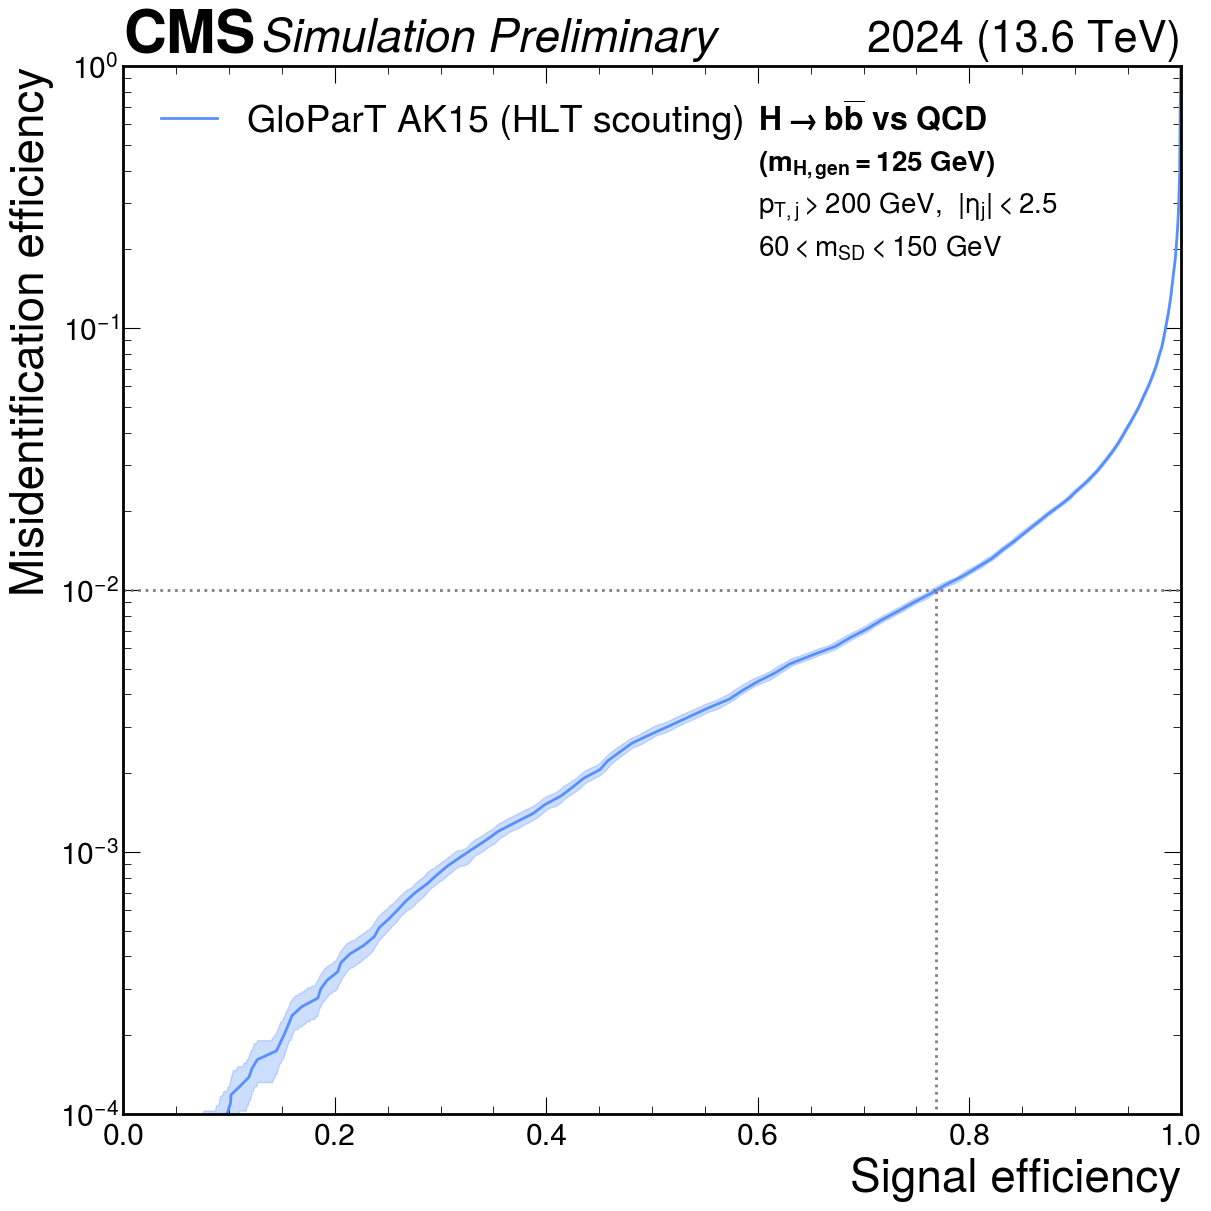

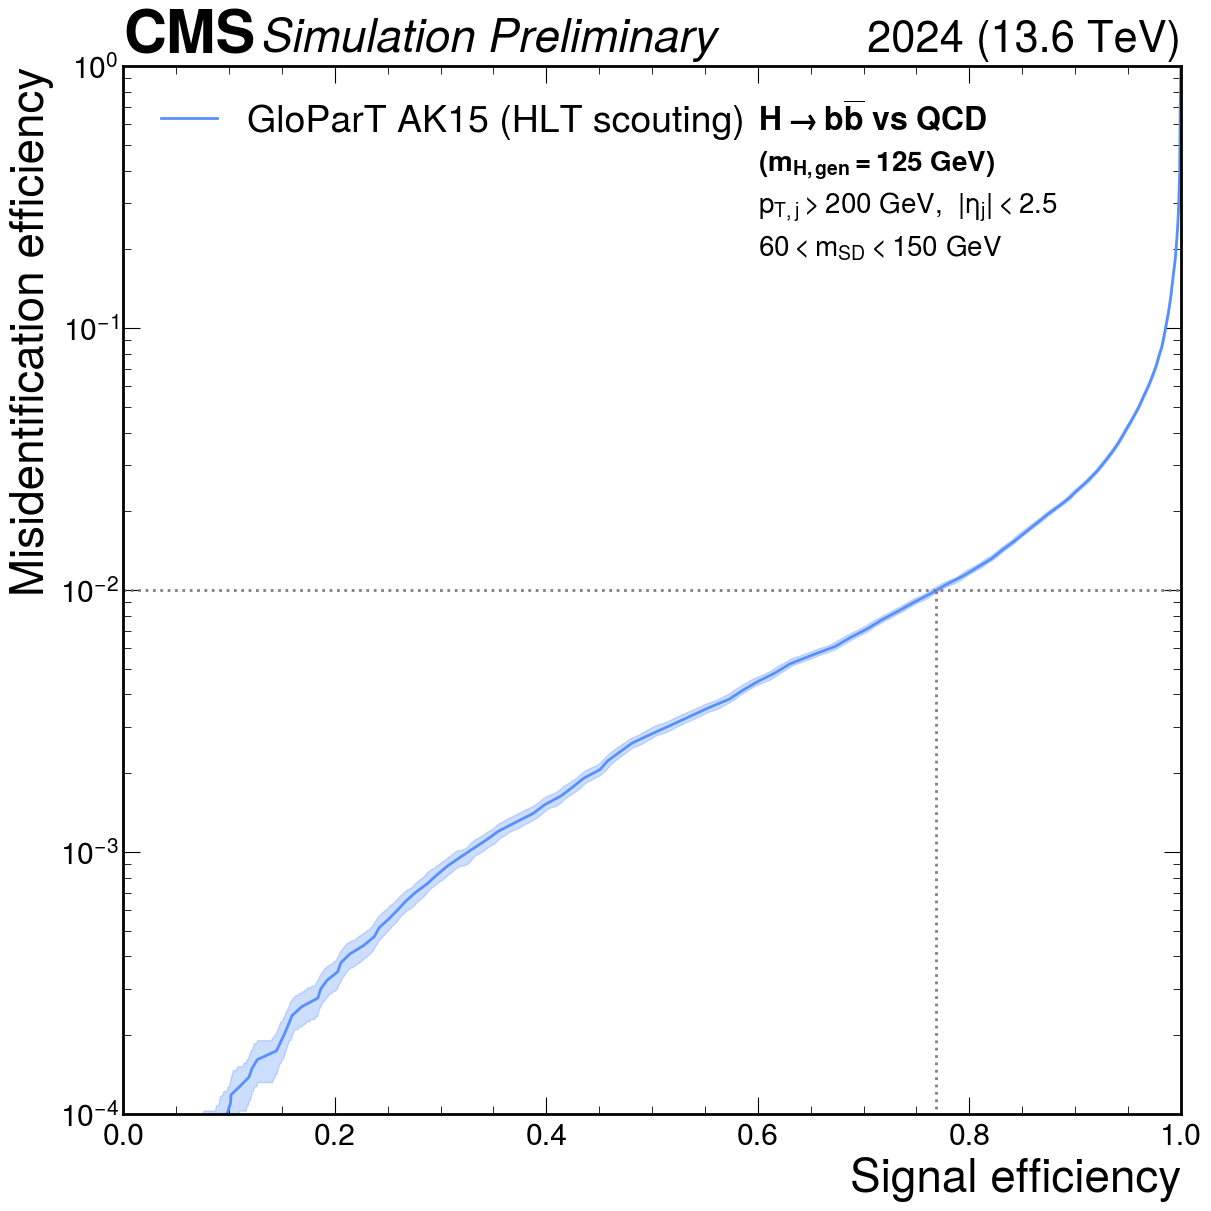

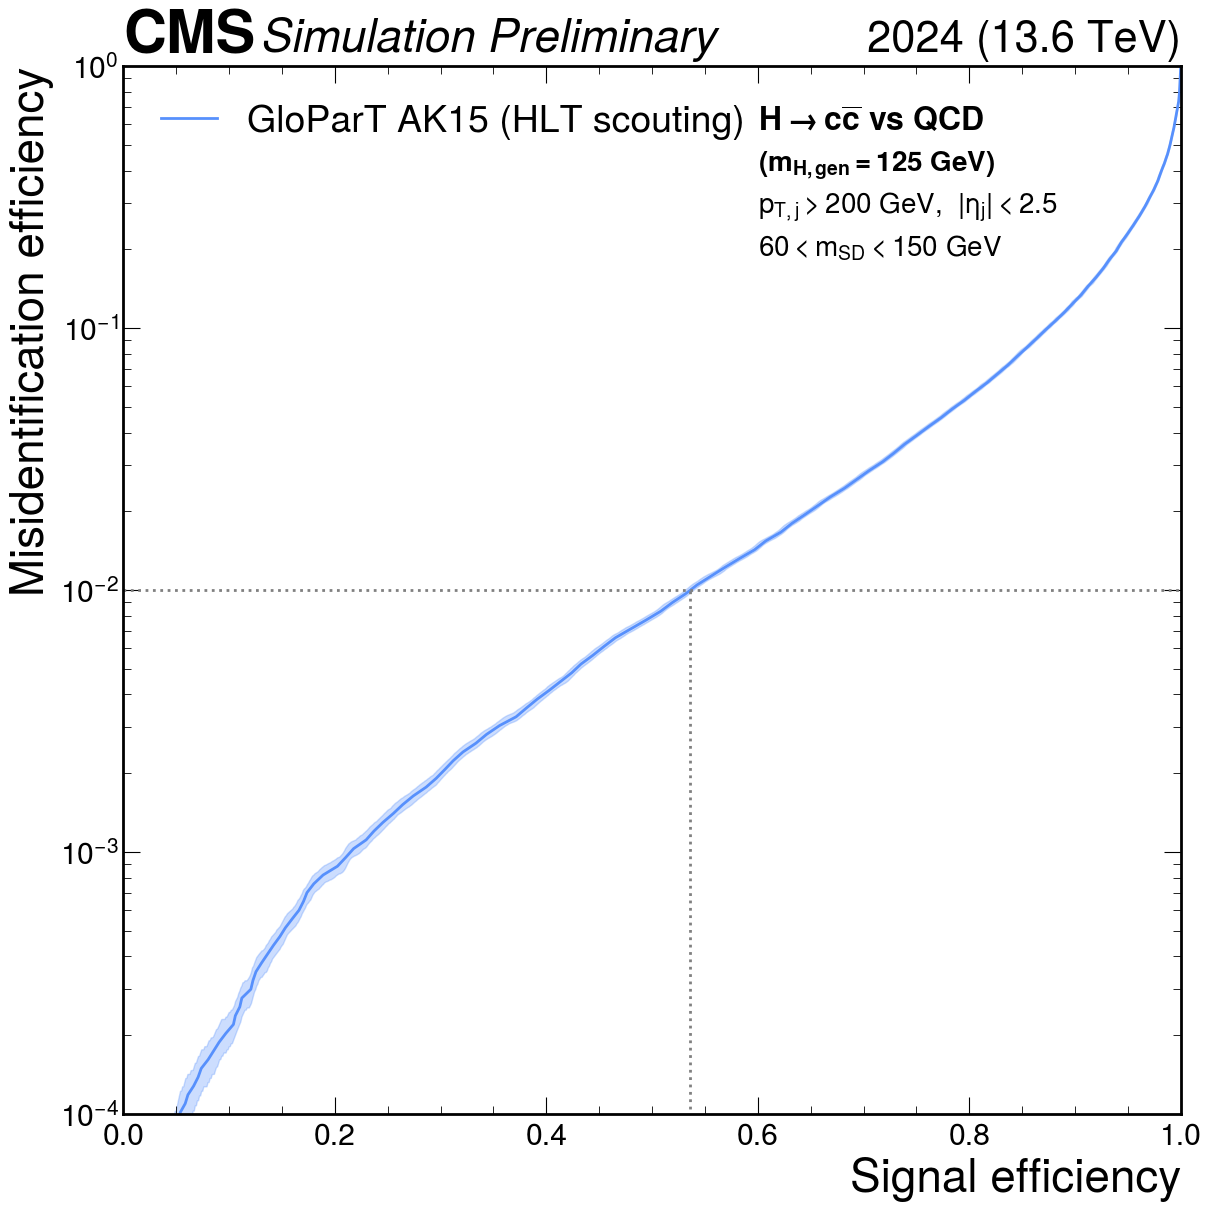

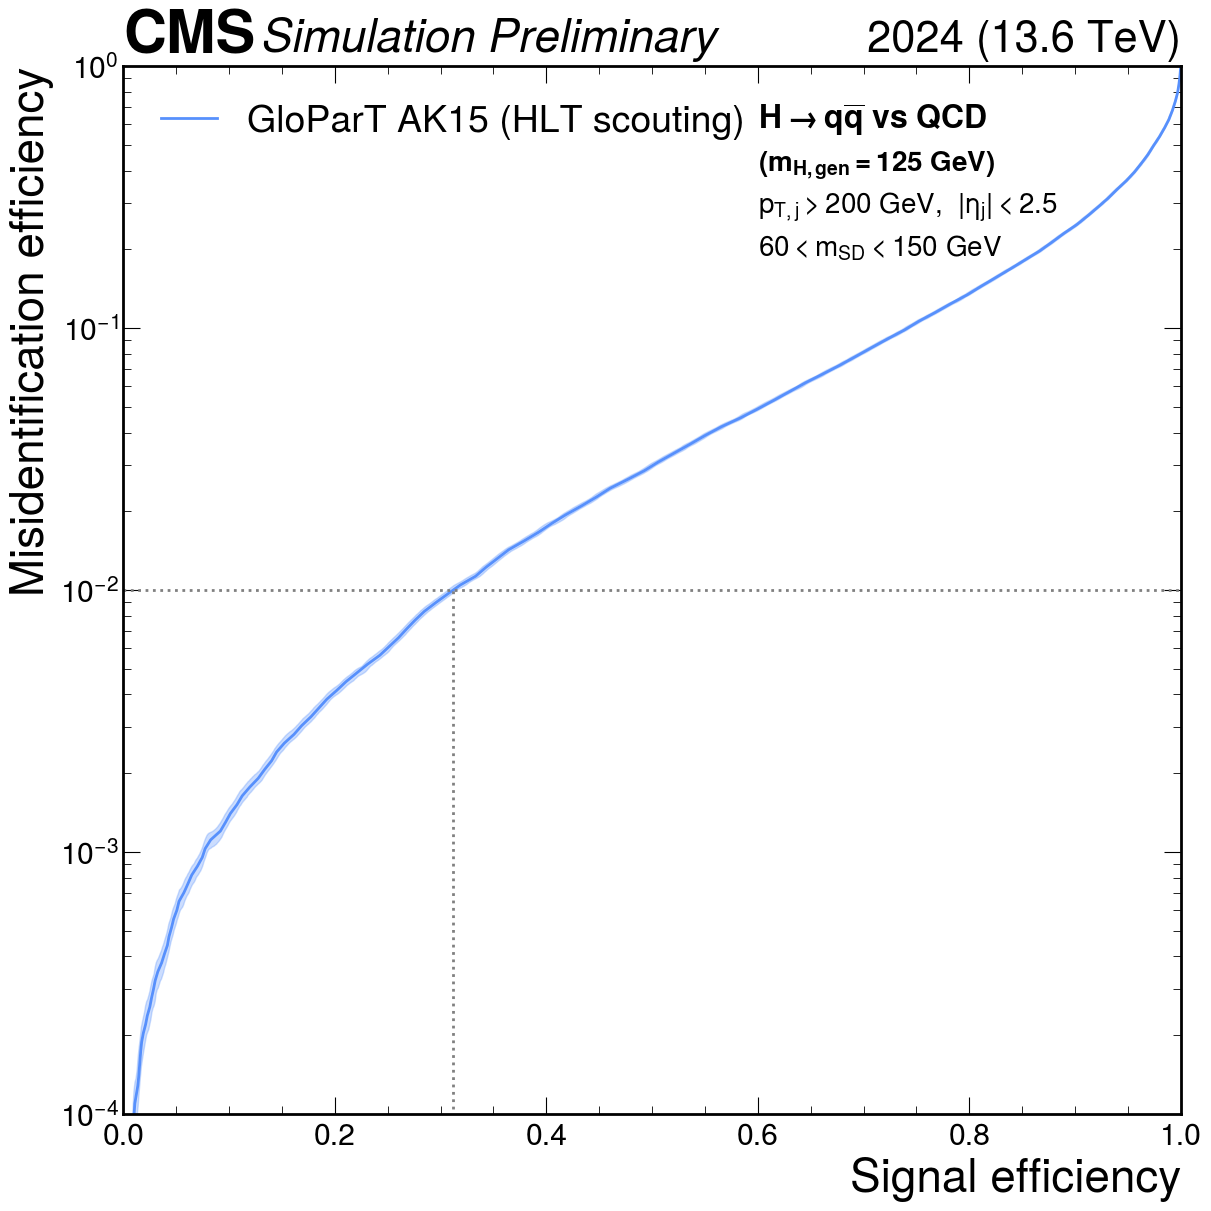

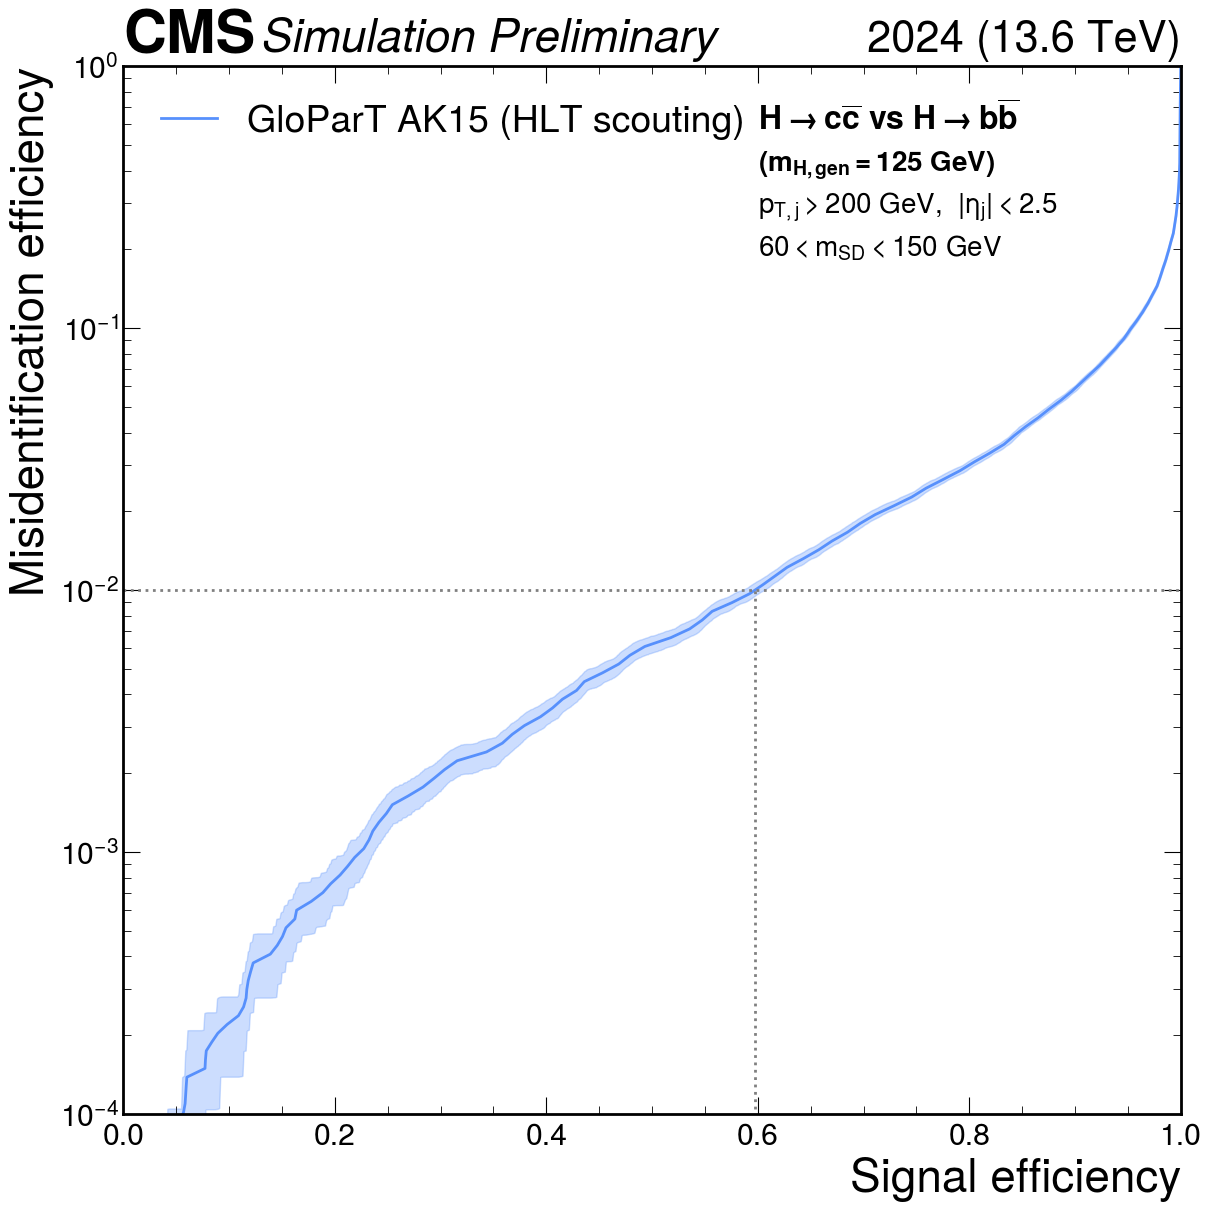

In [15]:

for year in ['2024']:

    # for pt, ptsig, mass, genm in [('low', 'LO', 'higgs', 125)]:
    # for pt, ptsig, mass, genm in [('evenlower', '2P', 'higgs', 125), ('low', '2P', 'higgs', 125), ('lower', '2P', 'higgs', 125)]:
    # for pt, ptsig, mass, genm in [('full', 'LO', 'higgs', 125), ('low', 'LO', 'higgs', 125), ('lower', 'LO', 'higgs', 125)]:
    for pt, ptsig, mass, genm in [('full', 'LO', 'higgs', 125)]:
    # # for pt, ptsig, mass, genm in [('high', 'HI', 'higgs', 125)]:
    #     # plot_roc_curve(f'HIG{ptsig}tauhtauh', f'QCD{ptsig}', samples=['v2', 'v3beta3a.origQCD'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq_2', xtext=0.5, genm=genm)
    #     # plot_roc_curve(f'HIG{ptsig}tauhtauh', f'HIG{ptsig}qq', samples=['v2', 'v3beta3a.origQCD'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq_2', xtext=0.5, genm=genm)
    #     # plot_roc_curve(f'HIG{ptsig}cc', f'QCD{ptsig}', samples=['PNetMD', 'v2', 'v3beta3a.origQCD', 'v3beta3a.origQCD.epoch120'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3beta3_hqq_2', xtext=0.5, genm=genm)
    #     # plot_roc_curve(f'HIG{ptsig}cc', f'HIG{ptsig}bb', samples=['PNetMD', 'v2', 'v3beta3a.origQCD'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq_2', xtext=0.5, genm=genm)
    #     # plot_roc_curve(f'HIG{ptsig}bb', 'QCD', samples=['PNetMD', 'v2', 'v3beta1', 'v3beta4', 'v3'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq', xtext=0.5, genm=genm)
    #     # plot_roc_curve(f'HIG{ptsig}cc', 'QCD', samples=['PNetMD', 'v2', 'v3beta1', 'v3beta4', 'v3'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq', xtext=0.5, genm=genm)
    #     # plot_roc_curve(f'HIG{ptsig}cc', f'HIG{ptsig}bb', samples=['PNetMD', 'v2', 'v3beta1', 'v3beta4', 'v3'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq', xtext=0.4, genm=genm)

    #     # plot_roc_curve(f'HWW{ptsig}QQQQ', 'QCD', samples=['v2', 'v3beta1', 'v3beta4', 'v3beta4p1.epoch97', 'v3'], pt=pt, mass=mass, store_plot=False, subdir='v3beta3_hqq', xtext=0.4, genm=genm)
    #     # plot_roc_curve(f'HWW{ptsig}QQQQ', 'TTBARbWhad', samples=['v2', 'v3beta1', 'v3beta4', 'v3beta4p1.epoch97', 'v3'], pt=pt, mass=mass, store_plot=False, subdir='v3beta3_hqq', xtext=0.4, genm=genm)

        # plot_roc_curve(f'HIG{ptsig}bb', f'QCD', samples=['PNetMD', 'PNetRun3MD', 'v2', 'v3'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta4_hqq_ofc', xtext=0.5, genm=genm)

        # plot_roc_curve(f'HIG{ptsig}bb', f'QCD', samples=['PNetMD', 'v2', 'v3', 'v3beta5', 'v3beta5.modelplus'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta4_hqq_ofc', xtext=0.5, genm=genm)
        # plot_roc_curve(f'HIG{ptsig}cc', 'QCD', samples=['PNetMD', 'v2', 'v3', 'v3beta5', 'v3beta5.modelplus'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq', xtext=0.5, genm=genm)
        # plot_roc_curve(f'HIG{ptsig}cc', f'HIG{ptsig}bb', samples=['PNetMD', 'v2', 'v3', 'v3beta5', 'v3beta5.modelplus'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta3_hqq', xtext=0.5, genm=genm)
        # plot_roc_curve(f'HWW{ptsig}QQQQ', 'QCD', samples=['v2', 'v3', 'v3beta5', 'v3beta5.modelplus'], pt=pt, mass=mass, store_plot=False, subdir='v3beta3_hqq', xtext=0.4, genm=genm)

        # plot_roc_curve(f'H{ptsig}bb', f'QCD', samples=['v3ScoutingLikeRECOAK15', 'v3ScoutingLikeRECOAK15V2','v3ScoutingLikeRECOAK15V2LastEpoch', 'PNetMD'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3AK15Pretrain', xtext=0.5, genm=genm)
        # plot_roc_curve(f'H{ptsig}cc', f'QCD', samples=['v3ScoutingLikeRECOAK15', 'v3ScoutingLikeRECOAK15V2','v3ScoutingLikeRECOAK15V2LastEpoch', 'PNetMD'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3AK15Pretrain', xtext=0.5, genm=genm)
        # plot_roc_curve(f'H{ptsig}cc', f'H{ptsig}bb', samples=['v3ScoutingLikeRECOAK15', 'v3ScoutingLikeRECOAK15V2','v3ScoutingLikeRECOAK15V2LastEpoch', 'PNetMD'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3AK15Pretrain', xtext=0.5, genm=genm)
        
        plot_roc_curve(f'HIG{ptsig}bb', f'QCD', samples=['v3ScoutingAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.5, genm=genm)
        plot_roc_curve(f'HIG{ptsig}bb', f'QCD', samples=['v3ScoutingAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.5, genm=genm)
        plot_roc_curve(f'HIG{ptsig}cc', f'QCD', samples=['v3ScoutingAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.5, genm=genm)
        plot_roc_curve(f'HIG{ptsig}qq', f'QCD', samples=['v3ScoutingAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.5, genm=genm)
        plot_roc_curve(f'HIG{ptsig}cc', f'HIG{ptsig}bb', samples=['v3ScoutingAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.5, genm=genm)
        
        # plot_roc_curve(f'HIG{ptsig}tauhtauh', f'QCD', samples=['v3ScoutingAK15', 'PNetRun3MD', 'v3AK8'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.5, genm=genm)
        
        
        # plot_roc_curve(f'H{ptsig}tauhtauh', f'QCD', samples=['v3AK15', 'v3AK15last'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3AK15', xtext=0.5, genm=genm)
        # plot_roc_curve(f'H{ptsig}tauhtauh', f'H{ptsig}qq', samples=['v3AK15', 'v3AK15last'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3AK15', xtext=0.5, genm=genm)
        # plot_roc_curve(f'HIG{ptsig}cc', 'QCD', samples=['v3ScoutingLikeRECOAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingLikeRECOAK15', xtext=0.5, genm=genm)
        # plot_roc_curve(f'HIG{ptsig}cc', f'HIG{ptsig}bb', samples=['v3ScoutingLikeRECOAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingLikeRECOAK15', xtext=0.5, genm=genm)
        # plot_roc_curve(f'HWW{ptsig}QQQQ', 'QCD', samples=['v3ScoutingLikeRECOAK15'], pt=pt, mass=mass, store_plot=True, subdir='v3ScoutingLikeRECOAK15', xtext=0.4, genm=genm)

        # plot_roc_curve(f'HIG{ptsig}cc', f'HIG{ptsig}bb', samples=['PNetMD', 'GloParT2', 'v3'], pt=pt, mass=mass, year=year, store_plot=False, subdir='v3beta4_hqq_ofc', xtext=0.5, genm=genm)


Debug: signal name before mapping: HPHMLO, background name before mapping: QCD
Debug: using filedir: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Debug: using file regex map: {'QCD': 'pred_qcd*470*.root', 'QCDLO': 'pred_qcdlo.root', 'QCDHI': 'pred_qcdhi.root', 'HIGLO': 'pred_h2plo*.root', 'HPHMLO': 'pred_hpm2plo*.root', 'HIGHI': 'pred_highi*.root', 'HWWLO': 'pred_hwwlo*.root', 'HWWHI': 'pred_hwwhi*.root', 'SMTTBARSL': 'pred_ofcttbarsl.root', 'HIGGS2P': 'pred_higgs2p*.root', 'H2P': 'pred_h2p*.root', 'HWW': 'pred_hww*.root', 'TTBARINCL': 'pred_ttbarincl*.root', 'TTBAR': 'pred_ttbar*.root', 'WLO': 'pred_wlo*.root', 'WHI': 'pred_whi*.root', 'ZLO': 'pred_zlo*.root', 'ZHI': 'pred_zhi*.root'}
Debug: signal name after mapping: HPHM, background name after mapping: QCD
Debug: signal file list: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pre

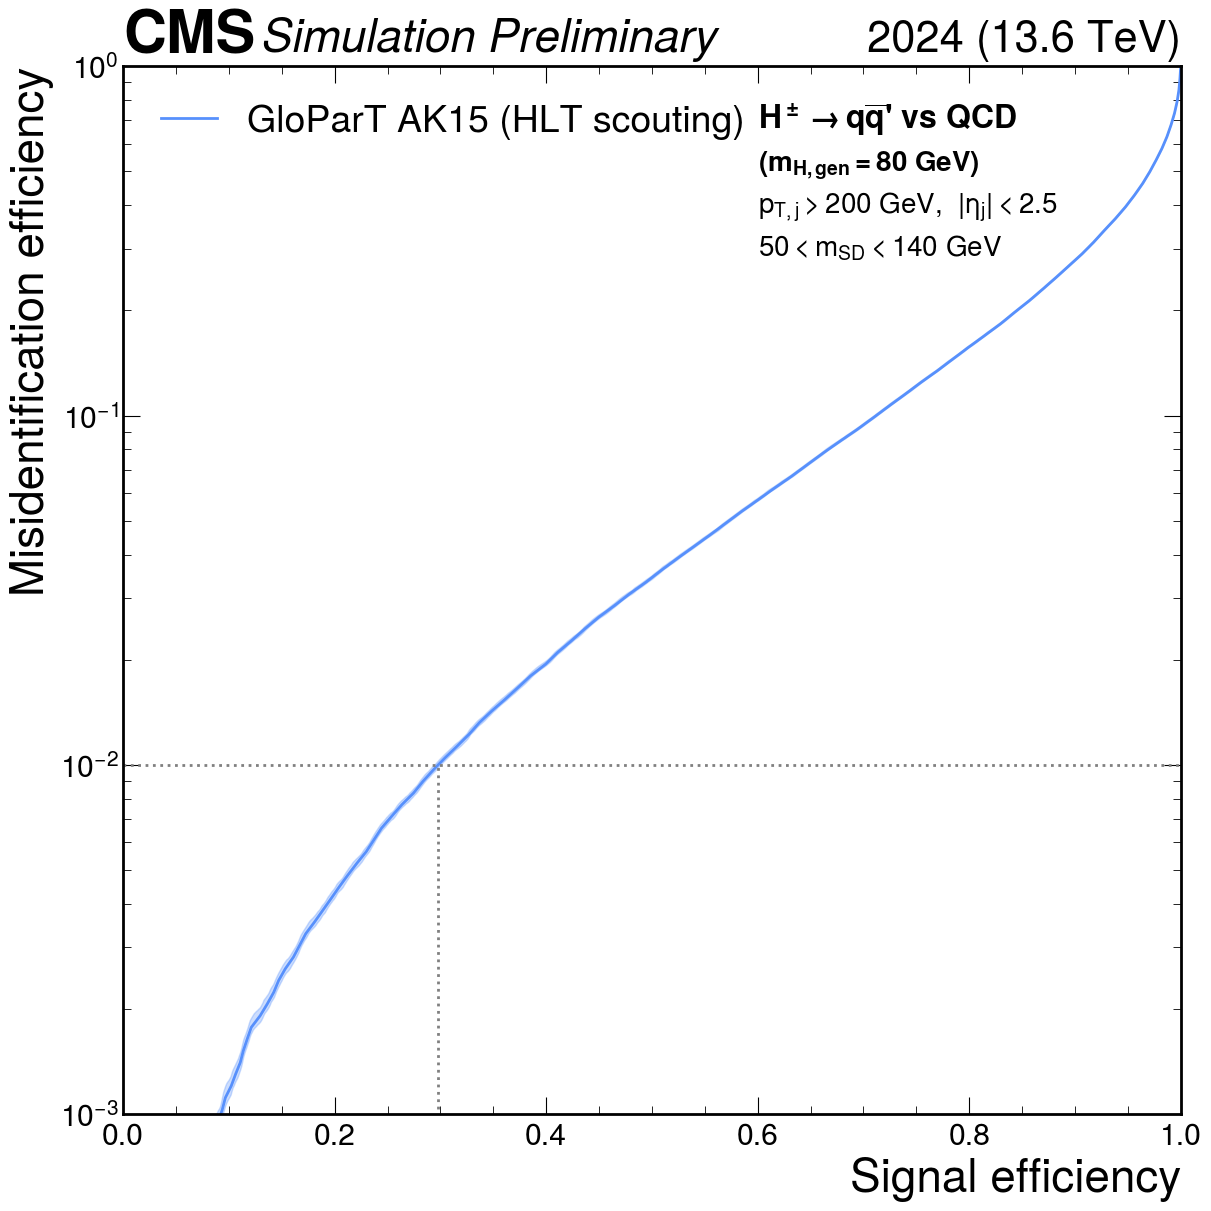

In [16]:
# year = '2024'
# now ROC curves for Hpm

for year in ['2024',]:

    # for pt, ptsig, mass, genm in [('full', 'LO', 'wz', 80), ('low', 'LO', 'wz', 80), ('lower', 'LO', 'wz', 80)]:
    for pt, ptsig, mass, genm in [('full', 'LO', 'wz', 80)]:
    #     # plot_roc_curve(f'HWW{ptsig}QQQQ', 'QCD', samples=['v2', 'v3beta1', 'v3beta4', 'v3beta4p1.epoch97', 'v3'], pt=pt, mass=mass, store_plot=False, subdir='v3beta3_hqq', xtext=0.4, genm=genm)
    #     # plot_roc_curve(f'HWW{ptsig}QQQQ', 'TTBARbWhad', samples=['v2', 'v3beta1', 'v3beta4', 'v3beta4p1.epoch97', 'v3'], pt=pt, mass=mass, store_plot=False, subdir='v3beta3_hqq', xtext=0.4, genm=genm)
        plot_roc_curve(f'HPHM{ptsig}', f'QCD', samples=['v3ScoutingAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.5, genm=genm)
        # plot_roc_curve(f'HWW{ptsig}QQQQ', 'QCD', samples=['v3ScoutingLikeRECOAK15'], pt=pt, mass=mass, store_plot=True, subdir='v3ScoutingLikeRECOAK15', xtext=0.4, genm=genm)


In [23]:
def plot_roc_curve_multiplesig(snames, bnames, samples, pt='low', mass='higgs', xmin=0, ymin=1e-4, xtext=0.5, store_plot=False, subdir='', genm=None, year='2017', plot_kwargs_list=None):
    f, ax = plt.subplots(figsize = (12,12), layout='constrained')
    year_legend_map = {
        '2017': '2017 (UL)',
        '2017PUPPIv18': '2017 (UL PUPPIv18)',
        '2022': '2022',
        '2022EE': '2022EE',
        '2023': '2023',
        '2024': '2024',
        '2025': '2025',
        '2023BPix': '2023BPix',
        '2023FixLTS': '2023FixLTS',
    }
    hep.cms.label(llabel = "Simulation Preliminary", rlabel='{year} ({com} TeV)'.format(year=year_legend_map[year], com='13.6' if any(y in year for y in ['2022', '2022EE', '2023', '2023BPix', '2024', '2025']) else '13'), ax=ax, fontname='sans-serif', fontsize=33)
    from scipy.interpolate import interp1d

    # create dataframe

    colors_local = plt.rcParams['axes.prop_cycle'].by_key()['color']


    for isig, sbname in enumerate(zip(snames, bnames)):
        sname, bname = sbname
        print (f'Plotting {sname} vs. {bname}')

        for isam, sam in enumerate(samples):
            opt = f'{sam}:{sname}:{bname}'
            print (opt)
            config = getConfig(opt, pt=pt, mass=mass, year=year)

            print(opt)
            print ('Using cut:', config.base_cut)
            print (config.filelist)
            print(
                config.filelist['sig'][0].rsplit('/', 1)[0],
                [l.split('/')[-1] for l in config.filelist['sig']], [l.split('/')[-1] for l in config.filelist['bkg']],
                config.y_sig_flag, config.y_bkg_flag, config.y_score,
                config.base_cut, config.mass_cut
            )


            # dfs = uproot.lazy(config.filelist['sig'])
            dfs = uproot.concatenate(config.filelist['sig'], cut = config.base_cut, num_workers=8)
            dfb = uproot.concatenate(config.filelist['bkg'], cut = config.base_cut, num_workers=8) 
            # apply final cut to the dataset
            dfs = dfs[ak.numexpr.evaluate(f"({config.y_sig_flag}) & ({config.base_cut}) & ({config.mass_cut})", dfs)]
            dfb = dfb[ak.numexpr.evaluate(f"({config.y_bkg_flag}) & ({config.base_cut}) & ({config.mass_cut})", dfb)]

            y_score_s = ak.numexpr.evaluate(config.y_score, dfs)
            y_score_b = ak.numexpr.evaluate(config.y_score, dfb)
            y_score = ak.concatenate([y_score_s, y_score_b])

            if genm is not None:
                genm_cut_str = f'abs((fj_gen_mass / {genm}) - 1) < 1e-3'
                y_score_s = y_score_s[ak.numexpr.evaluate(genm_cut_str, dfs)]
                if bname.startswith('HIG') or bname.startswith('HWW'):
                    y_score_b = y_score_b[ak.numexpr.evaluate(genm_cut_str, dfb)]
                y_score = ak.concatenate([y_score_s, y_score_b])
            
            # compute quantile on bkg
            qs = np.array([1e-1, 1e-2, 1e-3, 1e-4])
            thres = np.quantile(y_score_b, 1-qs)
            print('quantile thresholds', thres)
            print('n_left_signal', [ak.sum(y_score_s > t) for t in thres])

            y_true = ak.concatenate([ak.ones_like(y_score_s, dtype=bool), ak.zeros_like(y_score_b, dtype=bool)])
            print(ak.sum(y_true), ak.sum(~y_true))

            # fpr, tpr, _thres = m.roc_curve(y_true, y_score)
            # auc = m.auc(fpr, tpr)
            # # let's smoothen the roc a bit using splines
            # def smooth_roc(tmp_fpr, tmp_tpr):
            #     from scipy.interpolate import InterpolatedUnivariateSpline
            #     import pandas as pd
            #     coords = pd.DataFrame()
            #     coords['fpr'] = tmp_fpr
            #     coords['tpr'] = tmp_tpr
            #     clean = coords.drop_duplicates(subset=['fpr'])
            #     spline = InterpolatedUnivariateSpline(clean.fpr, clean.tpr, k=1)
            #     newx = np.logspace(-4.5, 0, 35)
            #     tprs = spline(newx)
            #     return newx, tprs
            #     # return clean.fpr.values, clean.tpr.values
            # fpr, tpr = smooth_roc(fpr, tpr)

            # # ax.plot(tpr, fpr, label=config.label + r'  ${(AUC: %.4f)}$' % auc, **(plot_kwargs_list[isam] if plot_kwargs_list is not None else {}), color = color_map[sam], linestyle = "-" if "couting" in sam else "--")
            # ax.plot(tpr, fpr, label=config.title, **(plot_kwargs_list[isam] if plot_kwargs_list is not None else {}), color = colors_local[isig], linestyle = "-" if "couting" in sam else "--", linewidth=2)
            

            def smooth_roc(tmp_fpr, tmp_tpr):
                from scipy.interpolate import InterpolatedUnivariateSpline
                import pandas as pd
                coords = pd.DataFrame()
                coords['fpr'] = tmp_fpr
                coords['tpr'] = tmp_tpr
                clean = coords.drop_duplicates(subset=['fpr'])
                spline = InterpolatedUnivariateSpline(clean.fpr, clean.tpr, k=1)
                # newx = np.logspace(-4.5, 0, 35)
                # for tau tau we need more points in the high efficiency region
                newx = np.logspace(-5, 0, 150)
                tprs = spline(newx)
                return newx, tprs
                # return clean.fpr.values, clean.tpr.values

            def get_roc_curve_with_unc(y_true, y_score, n_bootstrap=1000, random_state=None):
                from scipy.stats import bootstrap
                # 2. Evaluate baseline ROC curve
                fpr_base, tpr_base, _ = m.roc_curve(y_true, y_score)
                auc_base = m.auc(fpr_base, tpr_base)
                # 3. Define a standard evaluation grid for FPR to align bootstrap iterations
                tpr_grid = np.linspace(0, 1, 1000)
                # tpr_grid = np.logspace(-5, 0, 150)

                # 4. Define custom function to calculate TPR aligned to the common grid
                def compute_tpr_on_grid(data_indices):
                    """
                    Scipy's bootstrap expects data wrapped as an array-like structure.
                    We pass sample indices to easily extract resampled y_true and y_score pairs.
                    """
                    idx = data_indices.astype(int)
                    y_true_resampled = y_true[idx]
                    y_score_resampled = y_score[idx]
                    
                    # Calculate unique curve for this bootstrap sample
                    fpr, tpr, _ = m.roc_curve(y_true_resampled, y_score_resampled)
                    
                    # Interpolate the TPR onto our fixed evaluation grid
                    fpr_interpolated = np.interp(tpr_grid, tpr, fpr)
                    return fpr_interpolated
            
                # 5. Execute Bootstrap using SciPy
                # We pass an array of indices [0, 1, ..., N] to be resampled with replacement
                indices = np.arange(len(y_true))

                res = bootstrap(
                    (indices,), 
                    compute_tpr_on_grid, 
                    vectorized=False, 
                    n_resamples=1000, 
                    # confidence_level=0.95,
                    confidence_level=0.68,
                    method='percentile',
                    random_state=42
                )

                # Extract confidence boundaries
                lower_bounds = res.confidence_interval.low
                upper_bounds = res.confidence_interval.high
                # keep everything on a common TPR grid; do not remap bounds with swapped axes
                fpr_base = np.interp(tpr_grid, tpr_base, fpr_base)

                return fpr_base, tpr_grid, tpr_grid, lower_bounds, upper_bounds, auc_base


            

            # fpr, tpr, _thres = m.roc_curve(y_true, y_score)
            # auc = m.auc(fpr, tpr)
            # # let's smoothen the roc a bit using splines
            # fpr, tpr = smooth_roc(fpr, tpr)

            fpr, tpr, tpr_grid, lower_bounds, upper_bounds, auc = get_roc_curve_with_unc(y_true, y_score)

            # smoothen roc
            fpr, tpr = smooth_roc(fpr, tpr)
            # and the bounds
            # lower_bounds, upper_bounds = smooth_roc(lower_bounds, tpr_grid)[1], smooth_roc(upper_bounds, tpr_grid)[1]

            ax.plot(tpr, fpr, label=config.title, **(plot_kwargs_list[isam] if plot_kwargs_list is not None else {}), color = colors_local[isig], linestyle = "-" if "couting" in sam else "--", linewidth=2)
            plt.fill_between(tpr_grid, lower_bounds, upper_bounds, color=colors_local[isig], alpha=0.3)
            
            
            # draw 1% line
            func = interp1d(fpr, tpr)
            ax.plot([0, 1], [0.01, 0.01], ':', color='grey', linewidth=2)
            ax.plot([func(0.01), func(0.01)], [0, 0.01], ':', color='grey', linewidth=2)


    ax.legend(loc='upper left', labelspacing=0.8, prop={'size': 27}) #prop={'size': 22}, 
    ax.set_yscale('log'); ax.set_xlim(xmin, 1); ax.set_ylim(ymin, 1)
    ax.set_xlabel('Signal efficiency', ha='right', x=1.0, fontsize=33)
    ax.set_ylabel('Misidentification efficiency', ha='right', y=1.0, fontsize=33); 
    # x_text, y_text = 0.0, 0.6
    # x_text, y_text = xtext, 0.05
    x_text, y_text = xtext+0.05, 0.77
    if genm is not None:
        # ax.text(x_text+0.03, y_text+0.18, config.title, fontsize=22, fontweight='bold', transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.12, "GloParT AK15 (HLT Scouting)", fontsize=22, fontweight='bold', transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.08, r'($m_{H,gen} = %d$ GeV)' % genm, fontsize=20, fontweight='bold', transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.04, config.subtitle, fontsize=20, transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.00, config.subtitle2, fontsize=20, transform=ax.transAxes)
    else:
        ax.text(x_text+0.03, y_text+0.13, config.title, fontsize=22, fontweight='bold', transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.06, config.subtitle, fontsize=18, transform=ax.transAxes)
        ax.text(x_text+0.03, y_text+0.00, config.subtitle2, fontsize=18, transform=ax.transAxes)

    # if tauhtauh is involved, limit the x axis to 0.7 to 1
    if 'tauhtauh' in sname or 'tauhtauh' in bname:
        ax.set_xlim(0.85, 1)
        # and y axis one orgder smaller
        ax.set_ylim(1e-5, 1)
    if "HPHM" in sname:
        ax.set_ylim(1e-3, 1)
    if store_plot:
        os.makedirs(f'plots_scout_ak15/{subdir}', exist_ok=True)
        plt.savefig(f'plots_scout_ak15/{subdir}/roc_multiple_{sname}_{bname}_{"-".join(samples).replace(";","")}_{pt}_{mass}_{year}_{genm}.pdf', bbox_inches='tight')
        plt.savefig(f'plots_scout_ak15/{subdir}/roc_multiple_{sname}_{bname}_{"-".join(samples).replace(";","")}_{pt}_{mass}_{year}_{genm}.png', bbox_inches='tight')
        # print()


Plotting HIGLObb vs. QCD
v3ScoutingAK15:HIGLObb:QCD
Debug: signal name before mapping: HIGLObb, background name before mapping: QCD
Debug: using filedir: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Debug: using file regex map: {'QCD': 'pred_qcd*470*.root', 'QCDLO': 'pred_qcdlo.root', 'QCDHI': 'pred_qcdhi.root', 'HIGLO': 'pred_h2plo*.root', 'HPHMLO': 'pred_hpm2plo*.root', 'HIGHI': 'pred_highi*.root', 'HWWLO': 'pred_hwwlo*.root', 'HWWHI': 'pred_hwwhi*.root', 'SMTTBARSL': 'pred_ofcttbarsl.root', 'HIGGS2P': 'pred_higgs2p*.root', 'H2P': 'pred_h2p*.root', 'HWW': 'pred_hww*.root', 'TTBARINCL': 'pred_ttbarincl*.root', 'TTBAR': 'pred_ttbar*.root', 'WLO': 'pred_wlo*.root', 'WHI': 'pred_whi*.root', 'ZLO': 'pred_zlo*.root', 'ZHI': 'pred_zhi*.root'}
Debug: signal name after mapping: HIGbb, background name after mapping: QCD
Debug: signal file list: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_

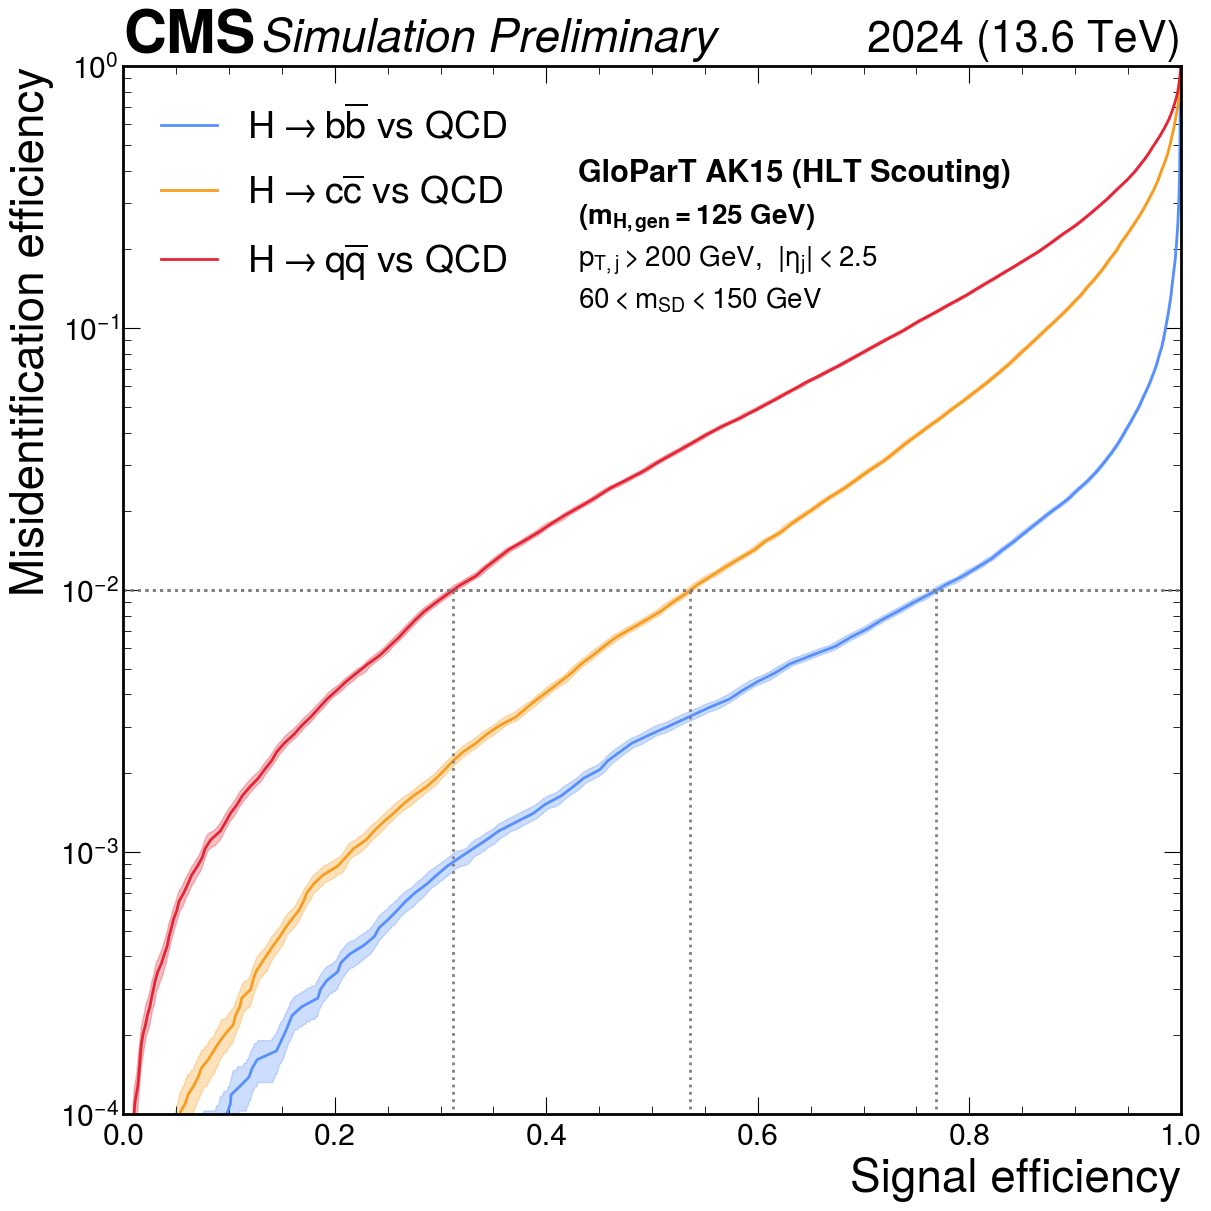

In [24]:
for year in ['2024']:
    for pt, ptsig, mass, genm in [('full', 'LO', 'higgs', 125)]:
        plot_roc_curve_multiplesig([f'HIG{ptsig}bb', f'HIG{ptsig}cc', f'HIG{ptsig}qq'], ['QCD', 'QCD', "QCD"], samples=['v3ScoutingAK15'], pt=pt, mass=mass, year=year, store_plot=True, subdir='v3ScoutingAK15/'+year, xtext=0.35, genm=genm)


# Mass decorrelation

In [25]:
## Mass decorelation
import boost_histogram as bh

# def plot_mass_decorr(sam, sname, bname, modelpath, mistags=[1, 0.05, 0.01, 0.005, 0.001], store_plot=False, subdir='', eval_pnet=False, do_pt = False, year = '2024', ptmin = 200, ptmax = 1000):
def plot_mass_decorr(sam, sname, bname, modelpath, mistags=[1, 0.05, 0.01, 0.001], store_plot=False, subdir='', eval_pnet=False, do_pt = False, year = '2024', ptmin = 200, ptmax = 1000):
    # colorlist = ['blue', 'red', 'green', 'cyan', 'darkorange', 'magenta']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)

    sam_title_map = {
        'ttbar': r't$\overline{t}$ sample',
        'qcd': r'QCD multijet',
        'qcd-xsecw': r'QCD multijet',
    }
    label_dict = {
        'QCD': 'QCD',
        'HWWQQQQ': r'H$\rightarrow$WW 4q', 'HWWQQQ': r'H$\rightarrow$WW 3q', 'HWWQQev': r'H$\rightarrow$WW $e\nu qq$', 'HWWQQmv': r'H$\rightarrow$WW $\mu\nu qq$', 'HWWQQta': r'H$\rightarrow$WW $\tau\nu qq$', 'HWWQQtauev': r'H$\rightarrow$WW $\tau_e\nu qq$', 'HWWQQtaumv': r'H$\rightarrow$WW $\tau_\mu\nu qq$', 'HWWQQtauhv': r'H$\rightarrow$WW $\tau_h\nu qq$',
        'HIGbb': r'H$\rightarrow$b$\overline{b}$', 'HIGcc': r'H$\rightarrow$c$\overline{c}$', 'HIGss': r'H$\rightarrow$ss', 'HIGqq': r'H$\rightarrow$q$\overline{q}$', 'HIGbc': r'$H^\pm \rightarrow$bc', 'HIGcs': r'$H^\pm \rightarrow$cs', 'HIGbs': r'$H\rightarrow$bs', 'HIGgg': r'$H\rightarrow$gg', 'HIGee': r'$H\rightarrow$ee', 'HIGmm': r'$H\rightarrow \mu\mu$', 'HIGtauhvtauev': r'H$\rightarrow\tau_h\tau_e$', 'HIGtauhvtaumv': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGtauhvtauhv': r'H$\rightarrow\tau_h\tau_h$', 
        'HIGll': r'H$\rightarrow$qq (q=u/d/s)', 
        'HIGtauhtaue': r'H$\rightarrow\tau_h\tau_e$', 'HIGtauhtaum': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGtauhtauh': r'H$\rightarrow\tau_h\tau_h$', 
        'HIGGS2Pbb': r'H$\rightarrow$bb', 'HIGGS2Pcc': r'H$\rightarrow$cc', 'HIGGS2Pss': r'H$\rightarrow$ss', 'HIGGS2Pqq': r'H$\rightarrow$qq', 'HIGGS2Pbc': r'$H^\pm \rightarrow$bc', 'HIGGS2Pcs': r'$H^\pm \rightarrow$cs', 'HIGGS2Pbs': r'$H\rightarrow$bs', 'HIGGS2Pgg': r'$H\rightarrow$gg', 'HIGGS2Pee': r'$H\rightarrow$ee', 'HIGGS2Pmm': r'$H\rightarrow \mu\mu$', 'HIGGS2Ptauhvtauev': r'H$\rightarrow\tau_h\tau_e$', 'HIGGS2Ptauhvtaumv': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGGS2Ptauhvtauhv': r'H$\rightarrow\tau_h\tau_h$', 
        'HIGGS2Ptauhtaue': r'H$\rightarrow\tau_h\tau_e$', 'HIGGS2Ptauhtaum': r'H$\rightarrow\tau_h\tau_\mu$', 'HIGGS2Ptauhtauh': r'H$\rightarrow\tau_h\tau_h$', 
        'TTBARbWall': r't$\rightarrow$bW all', 'TTBARbWhad': r't$\rightarrow$bW had.', 'TTBARbWQQ': r't$\rightarrow bW \rightarrow bqq$', 'TTBARbWev': r't$\rightarrow bW \rightarrow be\nu$', 'TTBARbWmv': r't$\rightarrow bW \rightarrow b\mu\nu$', 'TTBARbWta': r't$\rightarrow bW \rightarrow b\tau\nu$', 'TTBARbWtauhv': r't$\rightarrow bW \rightarrow b\tau_h\nu$',
        'QCDAndTTBARbWall': r'QCD + t$\rightarrow$bW all',
        'TTBARINCLall': r't$\rightarrow$bW all (incl.)', 'TTBARINCLhad': r't$\rightarrow$bW had. (incl.)', 'TTBARINCLel': r't$\rightarrow bW \rightarrow be\nu$ (incl.)', 'TTBARINCLmu': r't$\rightarrow bW \rightarrow b\mu\nu$ (incl.)', 
        'SMTTBARSLbWall': r't$\rightarrow$bW all', 'SMTTBARSLbWhad': r't$\rightarrow$bW had.', 'SMTTBARSLbWQQ': r't$\rightarrow bW \rightarrow bqq$', 'SMTTBARSLbWev': r't$\rightarrow bW \rightarrow be\nu$', 'SMTTBARSLbWmv': r't$\rightarrow bW \rightarrow b\mu\nu$', 'SMTTBARSLbWta': r't$\rightarrow bW \rightarrow b\tau\nu$',
        'SMTTBARSLbWcs': r't$\rightarrow bW \rightarrow bcs$', 'SMTTBARSLbWqq': r't$\rightarrow bW \rightarrow bqq$', 
        'XBCbc': r'$H\prime\rightarrow$bc', 
        'Wcs': r'W$\rightarrow$cs', 'Wqq': r'W$\rightarrow$qq', 'Zbb': r'Z$\rightarrow$bb', 'Zcc': r'Z$\rightarrow$cc', 'Zqq': r'Z$\rightarrow$qq', 'Zss': r'Z$\rightarrow$ss', 'Zll': r'Z$\rightarrow$qq (q=u/d/s)', 
        'WQQ': r'W$\rightarrow$qq (all)', 'ZQQ': r'Z$\rightarrow$qq (all)',
    }
    variable_dict = {
        'QCD': ['label_QCD_bb', 'label_QCD_cc', 'label_QCD_b', 'label_QCD_c', 'label_QCD_others'],
        **{f'HIG{n}': [f'label_H_{n}'] for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
        **{f'HIGGS2P{n}': [f'label_H_{n}'] for n in ['bb', 'cc', 'qq', 'ss', 'bc', 'cs', 'bs', 'gg', 'ee', 'mm', 'tauhtaue', 'tauhtaum', 'tauhtauh']},
        'HIGll': [f'label_H_{n}' for n in ['ss', 'qq']],
        **{f'HWW{n}': [f'label_H_WW_{n}'] for n in ['cscs', 'csqq', 'qqqq', 'csc', 'css', 'csq', 'qqc', 'qqs', 'qqq', 'csev', 'qqev', 'csmv', 'qqmv', 'cstauev', 'qqtauev', 'cstaumv', 'qqtaumv', 'cstauhv', 'qqtauhv']},
        **{f'TTBAR{n}': [f'label_Top_{n}'] for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv', 'Wcs', 'Wqq', 'Wev', 'Wmv', 'Wtauev', 'Wtaumv', 'Wtauhv']},
        **{f'W{n}': [f'label_H_{n}'] for n in ['qq', 'cs']},
        **{f'Z{n}': [f'label_H_{n}'] for n in ['bb', 'cc', 'qq', 'ss']},
        'HWWQQQQ': [f'label_H_WW_{n}' for n in ['cscs', 'csqq', 'qqqq']],
        'HWWQQQ': [f'label_H_WW_{n}' for n in ['csc', 'css', 'csq', 'qqc', 'qqs', 'qqq']],
        'HWWQQev': [f'label_H_WW_{n}' for n in ['csev', 'qqev']],
        'HWWQQmv': [f'label_H_WW_{n}' for n in ['csmv', 'qqmv']],
        'HWWQQtauev': [f'label_H_WW_{n}' for n in ['cstauev', 'qqtauev']],
        'HWWQQtaumv': [f'label_H_WW_{n}' for n in ['cstaumv', 'qqtaumv']],
        'HWWQQtauhv': [f'label_H_WW_{n}' for n in ['cstauhv', 'qqtauhv']],
        'HWWQQta': [f'label_H_WW_{n}' for n in ['cstauev', 'qqtauev', 'cstaumv', 'qqtaumv', 'cstauhv', 'qqtauhv']],
        # 'HWWel': [f'label_H_WW_{n}' for n in ['csev', 'cstauev', 'qqev', 'qqtauev']],
        # 'HWWmu': [f'label_H_WW_{n}' for n in ['csmv', 'cstaumv', 'qqmv', 'qqtaumv']],
        'TTBARbWall': [f'label_Top_{n}' for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv']],
        'TTBARbWhad': [f'label_Top_{n}' for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq']],
        'TTBARbWQQ': [f'label_Top_{n}' for n in ['bWcs', 'bWqq']],
        'TTBARbWta': [f'label_Top_{n}' for n in ['bWtauev', 'bWtaumv', 'bWtauhv']],
        'TTBARbWtauhv': [f'label_Top_{n}' for n in ['bWtauhv']],
        'TTBARall': [f'label_Top_{n}' for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv', 'Wcs', 'Wqq', 'Wev', 'Wmv', 'Wtauev', 'Wtaumv', 'Wtauhv']],
        'QCDAndTTBARbWall': ['label_QCD_bb', 'label_QCD_cc', 'label_QCD_b', 'label_QCD_c', 'label_QCD_others'] + [f'label_Top_{n}' for n in ['bWcs', 'bWqq', 'bWc', 'bWs', 'bWq', 'bWev', 'bWmv', 'bWtauev', 'bWtaumv', 'bWtauhv']],
        'WQQ': [f'label_H_{n}' for n in ['qq', 'cs']],
        'ZQQ': [f'label_H_{n}' for n in ['bb', 'cc', 'ss', 'qq']],
        'Zll': [f'label_H_{n}' for n in ['ss', 'qq']],
    }
    label_list = ['label_Top_bWcs', 'label_Top_bWqq', 'label_Top_bWc', 'label_Top_bWs', 'label_Top_bWq', 'label_Top_bWev', 'label_Top_bWmv', 'label_Top_bWtauev', 'label_Top_bWtaumv', 'label_Top_bWtauhv', 'label_Top_Wcs', 'label_Top_Wqq', 'label_Top_Wev', 'label_Top_Wmv', 'label_Top_Wtauev', 'label_Top_Wtaumv', 'label_Top_Wtauhv', 'label_H_bb', 'label_H_cc', 'label_H_ss', 'label_H_qq', 'label_H_bc', 'label_H_bs', 'label_H_cs', 'label_H_gg', 'label_H_ee', 'label_H_mm', 'label_H_tauhtaue', 'label_H_tauhtaum', 'label_H_tauhtauh', 'label_H_WW_cscs', 'label_H_WW_csqq', 'label_H_WW_qqqq', 'label_H_WW_csc', 'label_H_WW_css', 'label_H_WW_csq', 'label_H_WW_qqc', 'label_H_WW_qqs', 'label_H_WW_qqq', 'label_H_WW_csev', 'label_H_WW_qqev', 'label_H_WW_csmv', 'label_H_WW_qqmv', 'label_H_WW_cstauev', 'label_H_WW_qqtauev', 'label_H_WW_cstaumv', 'label_H_WW_qqtaumv', 'label_H_WW_cstauhv', 'label_H_WW_qqtauhv', 'label_H_WxWx_cscs', 'label_H_WxWx_csqq', 'label_H_WxWx_qqqq', 'label_H_WxWx_csc', 'label_H_WxWx_css', 'label_H_WxWx_csq', 'label_H_WxWx_qqc', 'label_H_WxWx_qqs', 'label_H_WxWx_qqq', 'label_H_WxWx_csev', 'label_H_WxWx_qqev', 'label_H_WxWx_csmv', 'label_H_WxWx_qqmv', 'label_H_WxWx_cstauev', 'label_H_WxWx_qqtauev', 'label_H_WxWx_cstaumv', 'label_H_WxWx_qqtaumv', 'label_H_WxWx_cstauhv', 'label_H_WxWx_qqtauhv', 'label_H_WxWxStar_cscs', 'label_H_WxWxStar_csqq', 'label_H_WxWxStar_qqqq', 'label_H_WxWxStar_csc', 'label_H_WxWxStar_css', 'label_H_WxWxStar_csq', 'label_H_WxWxStar_qqc', 'label_H_WxWxStar_qqs', 'label_H_WxWxStar_qqq', 'label_H_WxWxStar_csev', 'label_H_WxWxStar_qqev', 'label_H_WxWxStar_csmv', 'label_H_WxWxStar_qqmv', 'label_H_WxWxStar_cstauev', 'label_H_WxWxStar_qqtauev', 'label_H_WxWxStar_cstaumv', 'label_H_WxWxStar_qqtaumv', 'label_H_WxWxStar_cstauhv', 'label_H_WxWxStar_qqtauhv', 'label_H_ZZ_bbbb', 'label_H_ZZ_bbcc', 'label_H_ZZ_bbss', 'label_H_ZZ_bbqq', 'label_H_ZZ_cccc', 'label_H_ZZ_ccss', 'label_H_ZZ_ccqq', 'label_H_ZZ_ssss', 'label_H_ZZ_ssqq', 'label_H_ZZ_qqqq', 'label_H_ZZ_bbb', 'label_H_ZZ_bbc', 'label_H_ZZ_bbs', 'label_H_ZZ_bbq', 'label_H_ZZ_ccb', 'label_H_ZZ_ccc', 'label_H_ZZ_ccs', 'label_H_ZZ_ccq', 'label_H_ZZ_ssb', 'label_H_ZZ_ssc', 'label_H_ZZ_sss', 'label_H_ZZ_ssq', 'label_H_ZZ_qqb', 'label_H_ZZ_qqc', 'label_H_ZZ_qqs', 'label_H_ZZ_qqq', 'label_H_ZZ_bbee', 'label_H_ZZ_bbmm', 'label_H_ZZ_bbe', 'label_H_ZZ_bbm', 'label_H_ZZ_bee', 'label_H_ZZ_bmm', 'label_H_ZZ_bbtauhtaue', 'label_H_ZZ_bbtauhtaum', 'label_H_ZZ_bbtauhtauh', 'label_H_ZZ_btauhtaue', 'label_H_ZZ_btauhtaum', 'label_H_ZZ_btauhtauh', 'label_H_ZZ_ccee', 'label_H_ZZ_ccmm', 'label_H_ZZ_cce', 'label_H_ZZ_ccm', 'label_H_ZZ_cee', 'label_H_ZZ_cmm', 'label_H_ZZ_cctauhtaue', 'label_H_ZZ_cctauhtaum', 'label_H_ZZ_cctauhtauh', 'label_H_ZZ_ctauhtaue', 'label_H_ZZ_ctauhtaum', 'label_H_ZZ_ctauhtauh', 'label_H_ZZ_ssee', 'label_H_ZZ_ssmm', 'label_H_ZZ_sse', 'label_H_ZZ_ssm', 'label_H_ZZ_see', 'label_H_ZZ_smm', 'label_H_ZZ_sstauhtaue', 'label_H_ZZ_sstauhtaum', 'label_H_ZZ_sstauhtauh', 'label_H_ZZ_stauhtaue', 'label_H_ZZ_stauhtaum', 'label_H_ZZ_stauhtauh', 'label_H_ZZ_qqee', 'label_H_ZZ_qqmm', 'label_H_ZZ_qqe', 'label_H_ZZ_qqm', 'label_H_ZZ_qee', 'label_H_ZZ_qmm', 'label_H_ZZ_qqtauhtaue', 'label_H_ZZ_qqtauhtaum', 'label_H_ZZ_qqtauhtauh', 'label_H_ZZ_qtauhtaue', 'label_H_ZZ_qtauhtaum', 'label_H_ZZ_qtauhtauh', 'label_H_ZxZx_bbbb', 'label_H_ZxZx_bbcc', 'label_H_ZxZx_bbss', 'label_H_ZxZx_bbqq', 'label_H_ZxZx_cccc', 'label_H_ZxZx_ccss', 'label_H_ZxZx_ccqq', 'label_H_ZxZx_ssss', 'label_H_ZxZx_ssqq', 'label_H_ZxZx_qqqq', 'label_H_ZxZx_bbb', 'label_H_ZxZx_bbc', 'label_H_ZxZx_bbs', 'label_H_ZxZx_bbq', 'label_H_ZxZx_ccb', 'label_H_ZxZx_ccc', 'label_H_ZxZx_ccs', 'label_H_ZxZx_ccq', 'label_H_ZxZx_ssb', 'label_H_ZxZx_ssc', 'label_H_ZxZx_sss', 'label_H_ZxZx_ssq', 'label_H_ZxZx_qqb', 'label_H_ZxZx_qqc', 'label_H_ZxZx_qqs', 'label_H_ZxZx_qqq', 'label_H_ZxZx_bbee', 'label_H_ZxZx_bbmm', 'label_H_ZxZx_bbe', 'label_H_ZxZx_bbm', 'label_H_ZxZx_bee', 'label_H_ZxZx_bmm', 'label_H_ZxZx_bbtauhtaue', 'label_H_ZxZx_bbtauhtaum', 'label_H_ZxZx_bbtauhtauh', 'label_H_ZxZx_btauhtaue', 'label_H_ZxZx_btauhtaum', 'label_H_ZxZx_btauhtauh', 'label_H_ZxZx_ccee', 'label_H_ZxZx_ccmm', 'label_H_ZxZx_cce', 'label_H_ZxZx_ccm', 'label_H_ZxZx_cee', 'label_H_ZxZx_cmm', 'label_H_ZxZx_cctauhtaue', 'label_H_ZxZx_cctauhtaum', 'label_H_ZxZx_cctauhtauh', 'label_H_ZxZx_ctauhtaue', 'label_H_ZxZx_ctauhtaum', 'label_H_ZxZx_ctauhtauh', 'label_H_ZxZx_ssee', 'label_H_ZxZx_ssmm', 'label_H_ZxZx_sse', 'label_H_ZxZx_ssm', 'label_H_ZxZx_see', 'label_H_ZxZx_smm', 'label_H_ZxZx_sstauhtaue', 'label_H_ZxZx_sstauhtaum', 'label_H_ZxZx_sstauhtauh', 'label_H_ZxZx_stauhtaue', 'label_H_ZxZx_stauhtaum', 'label_H_ZxZx_stauhtauh', 'label_H_ZxZx_qqee', 'label_H_ZxZx_qqmm', 'label_H_ZxZx_qqe', 'label_H_ZxZx_qqm', 'label_H_ZxZx_qee', 'label_H_ZxZx_qmm', 'label_H_ZxZx_qqtauhtaue', 'label_H_ZxZx_qqtauhtaum', 'label_H_ZxZx_qqtauhtauh', 'label_H_ZxZx_qtauhtaue', 'label_H_ZxZx_qtauhtaum', 'label_H_ZxZx_qtauhtauh', 'label_H_ZxZxStar_bbbb', 'label_H_ZxZxStar_bbcc', 'label_H_ZxZxStar_bbss', 'label_H_ZxZxStar_bbqq', 'label_H_ZxZxStar_cccc', 'label_H_ZxZxStar_ccss', 'label_H_ZxZxStar_ccqq', 'label_H_ZxZxStar_ssss', 'label_H_ZxZxStar_ssqq', 'label_H_ZxZxStar_qqqq', 'label_H_ZxZxStar_bbb', 'label_H_ZxZxStar_bbc', 'label_H_ZxZxStar_bbs', 'label_H_ZxZxStar_bbq', 'label_H_ZxZxStar_ccb', 'label_H_ZxZxStar_ccc', 'label_H_ZxZxStar_ccs', 'label_H_ZxZxStar_ccq', 'label_H_ZxZxStar_ssb', 'label_H_ZxZxStar_ssc', 'label_H_ZxZxStar_sss', 'label_H_ZxZxStar_ssq', 'label_H_ZxZxStar_qqb', 'label_H_ZxZxStar_qqc', 'label_H_ZxZxStar_qqs', 'label_H_ZxZxStar_qqq', 'label_H_ZxZxStar_bbee', 'label_H_ZxZxStar_bbmm', 'label_H_ZxZxStar_bbe', 'label_H_ZxZxStar_bbm', 'label_H_ZxZxStar_bee', 'label_H_ZxZxStar_bmm', 'label_H_ZxZxStar_bbtauhtaue', 'label_H_ZxZxStar_bbtauhtaum', 'label_H_ZxZxStar_bbtauhtauh', 'label_H_ZxZxStar_btauhtaue', 'label_H_ZxZxStar_btauhtaum', 'label_H_ZxZxStar_btauhtauh', 'label_H_ZxZxStar_ccee', 'label_H_ZxZxStar_ccmm', 'label_H_ZxZxStar_cce', 'label_H_ZxZxStar_ccm', 'label_H_ZxZxStar_cee', 'label_H_ZxZxStar_cmm', 'label_H_ZxZxStar_cctauhtaue', 'label_H_ZxZxStar_cctauhtaum', 'label_H_ZxZxStar_cctauhtauh', 'label_H_ZxZxStar_ctauhtaue', 'label_H_ZxZxStar_ctauhtaum', 'label_H_ZxZxStar_ctauhtauh', 'label_H_ZxZxStar_ssee', 'label_H_ZxZxStar_ssmm', 'label_H_ZxZxStar_sse', 'label_H_ZxZxStar_ssm', 'label_H_ZxZxStar_see', 'label_H_ZxZxStar_smm', 'label_H_ZxZxStar_sstauhtaue', 'label_H_ZxZxStar_sstauhtaum', 'label_H_ZxZxStar_sstauhtauh', 'label_H_ZxZxStar_stauhtaue', 'label_H_ZxZxStar_stauhtaum', 'label_H_ZxZxStar_stauhtauh', 'label_H_ZxZxStar_qqee', 'label_H_ZxZxStar_qqmm', 'label_H_ZxZxStar_qqe', 'label_H_ZxZxStar_qqm', 'label_H_ZxZxStar_qee', 'label_H_ZxZxStar_qmm', 'label_H_ZxZxStar_qqtauhtaue', 'label_H_ZxZxStar_qqtauhtaum', 'label_H_ZxZxStar_qqtauhtauh', 'label_H_ZxZxStar_qtauhtaue', 'label_H_ZxZxStar_qtauhtaum', 'label_H_ZxZxStar_qtauhtauh', 'label_QCD_bb', 'label_QCD_cc', 'label_QCD_b', 'label_QCD_c', 'label_QCD_others']
    label_idx = {lab: i for i, lab in enumerate(label_list)}

    # ptmin, ptmax = 400, 600
    # ptmin, ptmax = 400, 100000
    # ptmin, ptmax = 200, 100000
    # ptmin, ptmax = 200, 400
    # ptmin, ptmax = 150, 100000
    # nbin, xmin, xmax = 23, 20, 250
    # nbin, xmin, xmax = 16, 20, 260

    if ptmin == 200 and ptmax == 400:
        # nbin, xmin, xmax = 13, 20, 150
        nbin, xmin, xmax = 6, 20, 140
    elif ptmin == 600 and ptmax == 1000:
        # nbin, xmin, xmax = 20, 20, 220
        nbin, xmin, xmax = 10, 20, 220
    elif ptmin == 400 and ptmax == 600:
        # nbin, xmin, xmax = 18, 20, 200
        nbin, xmin, xmax = 9, 20, 200

    if do_pt:
        nbin, xmin, xmax = 28, 150, 1550

    # y_bkg_flag = ' | '.join([f'(fj_label == {label_idx[lab]})' for lab in variable_dict[bname]])
    y_bkg_flag = ' | '.join([f'(scoutfj_label == {label_idx[lab]})' for lab in variable_dict[bname]])
    y_score_sig = ' + '.join([f'score_{lab}' for lab in variable_dict[sname]])
    y_score_bkg = ' + '.join([f'score_{lab}' for lab in variable_dict[bname]])
    y_score_str = f'({y_score_sig}) / (({y_score_sig}) + ({y_score_bkg}))'
    
    # special parameters for ZQQ and WQQ tagging
    if sname == 'ZQQ':
        y_score_sig = 'score_label_H_bb + score_label_H_cc + score_label_H_ss + 2 * score_label_H_qq' # H_qq score * 2
        y_score_str = f'({y_score_sig}) / (({y_score_sig}) + ({y_score_bkg}))'
    elif sname == 'Zll':
        y_score_sig = 'score_label_H_ss + 2 * score_label_H_qq' # H_qq score * 2
        y_score_str = f'({y_score_sig}) / (({y_score_sig}) + ({y_score_bkg}))'
    elif sname == 'TTBARbWhad':
        y_score_sig = 'score_label_Top_bWcs + score_label_Top_bWqq + 1 * (score_label_Top_bWc + score_label_Top_bWs + 2 * score_label_Top_bWq)'
        y_score_str = f'({y_score_sig}) / (({y_score_sig}) + ({y_score_bkg}))'

    # ## ad-hoc setting for PNET!!! ##
    # if sname == 'ZQQ':
    #     y_score_sig = f'pfMassDecorrelatedParticleNetJetTags_probXbb + pfMassDecorrelatedParticleNetJetTags_probXcc + pfMassDecorrelatedParticleNetJetTags_probXqq'
    #     y_score_bkg = f'pfMassDecorrelatedParticleNetJetTags_probQCDb + pfMassDecorrelatedParticleNetJetTags_probQCDbb + pfMassDecorrelatedParticleNetJetTags_probQCDc + pfMassDecorrelatedParticleNetJetTags_probQCDcc + pfMassDecorrelatedParticleNetJetTags_probQCDothers'
    #     y_score_str = f'({y_score_sig}) / (({y_score_sig}) + ({y_score_bkg}))'
    # if sname == 'WQQ':
    #     y_score_sig = f'pfMassDecorrelatedParticleNetJetTags_probXcc + pfMassDecorrelatedParticleNetJetTags_probXqq'
    #     y_score_bkg = f'pfMassDecorrelatedParticleNetJetTags_probQCDb + pfMassDecorrelatedParticleNetJetTags_probQCDbb + pfMassDecorrelatedParticleNetJetTags_probQCDc + pfMassDecorrelatedParticleNetJetTags_probQCDcc + pfMassDecorrelatedParticleNetJetTags_probQCDothers'
    #     y_score_str = f'({y_score_sig}) / (({y_score_sig}) + ({y_score_bkg}))'

    # special beta3+ class splitting
    import re
    y_score_str = re.sub(r'score_label_Top_bW([a-zA-Z0-9_]+)', r'(score_label_Top_bWp\1 + score_label_Top_bWm\1)', y_score_str)
    y_score_str = re.sub(r'score_label_H_bc', r'(score_label_Hp_bc + score_label_Hm_bc)', y_score_str)
    y_score_str = re.sub(r'score_label_H_cs', r'(score_label_Hp_cs + score_label_Hm_cs)', y_score_str)

    # path = '/home/olympus/licq/hww/incl-train/weaver-core/weaver/predict/ak8_MD_inclv10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.farm221.best_epoch'
    # path = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.runScoutPre2MoreDataLowPt_lastModel'
    if modelpath == "v3AK15Pretrain_v1":
        path = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual2.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun'
    if modelpath == "v3AK15Pretrain_tsg":
        path = '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.runScoutPre2MoreDataLowPt_lastModel'
    if modelpath == "v3ScoutingAK15":
        # path = "/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/"
        path = "/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/"

    if sam == 'qcd' or sam == 'qcd-xsecw':
        filelist = glob.glob(f'{path}/pred_qcd_[0-9]*.root')
    elif sam == 'ttbar':
        filelist = glob.glob(f'{path}/pred_ttbar.root')

    print ("path:", path)
    print ('Loading files:', filelist)

    # df = uproot.concatenate(filelist); name = 'v3'; label = 'GloParT 3'
    df = uproot.concatenate(filelist, num_workers=16)
    # name = 'v3'
    label = 'GloParT AK15 (HLT scouting)'
    # df = df[ak.numexpr.evaluate(f"(fj_pt>{ptmin}) & (fj_pt<{ptmax}) & (abs(fj_eta)<2.5)", df)]
    df = df[ak.numexpr.evaluate(f"(scoutfj_pt>{ptmin}) & (scoutfj_pt<{ptmax}) & (abs(scoutfj_eta)<2.5)", df)]
    print(y_bkg_flag)
    df = df[ak.numexpr.evaluate(y_bkg_flag, df)]
    y_score = ak.numexpr.evaluate(y_score_str, df)
    print(y_score_str)

    # # optional: draw score distribution
    # f, ax = plt.subplots(figsize=(10,10))
    # hist = bh.Histogram(bh.axis.Regular(50, 0, 1), storage=bh.storage.Weight())
    # hist.fill(y_score)
    # content, yerr = hist.view().value / sum(hist.view().value), np.sqrt(hist.view().variance) / sum(hist.view().value)
    # hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr)
    # ax.set_xlim(0, 1)

    ## less accurate when scores are too close to 0.
    # fpr, tpr, thresholds = m.roc_curve(np.zeros_like(y_score), y_score)
    # mistags = [1, 0.05, 0.02, 0.01, 0.005]
    # wps = np.interp(x=mistags, xp=fpr, fp=thresholds)
    # print('WPs:', wps)

    wps = [np.quantile(y_score, q=1-t) for t in mistags]
    print('WPs:', wps)

    f = plt.figure(figsize=(12,12), layout='constrained')
    gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ## Upper histogram panel
    ax = f.add_subplot(gs[0])
    # hep.cms.label(data=False, llabel='Simulation Preliminary', year=2017, ax=ax)
    com = '13.6' if any(y in year for y in ['2022', '2022EE', '2023', '2023BPix', '2024', '2025']) else '13'
    hep.cms.label(llabel = "Simulation Preliminary", rlabel=f'{year} ({com} TeV)', ax=ax, fontname='sans-serif', fontsize=33)

    ax.set_xlim(xmin, xmax); ax.set_xticklabels([])
    ax.set_ylabel('Jets / bin', ha='right', y=1.0, fontsize = 33)
    hists = {}
    for i, (mistag, wp) in enumerate(zip(mistags, wps)):
        if sam != 'qcd-xsecw':
            df_t = df[y_score > wp]
            print(len(df_t))
            # make histogram for sdmass
            hists[mistag] = bh.Histogram(bh.axis.Regular(nbin, xmin, xmax), storage=bh.storage.Weight())
            if not do_pt:
                hists[mistag].fill(df_t['scoutfj_sdmass'])
            else:
                hists[mistag].fill(df_t['scoutfj_pt'])
        else:
            xsec_qcd = {
                'qcd_170to300': 117276,
                'qcd_300to470': 7823.28,
                'qcd_470to600': 648.174,
                'qcd_600to800': 186.946,
                'qcd_800to1000': 32.2928,
                'qcd_1000to1400': 9.41832,
                'qcd_1400to1800': 0.84265,
                'qcd_1800to2400': 0.114943,
                'qcd_2400to3200': 0.00682981,
                'qcd_3200toInf': 0.000165445,
            }
            hists[mistag] = bh.Histogram(bh.axis.Regular(nbin, xmin, xmax), storage=bh.storage.Weight())
            selected_samples = ['qcd_300to470', 'qcd_470to600', 'qcd_600to800', 'qcd_800to1000', 'qcd_1000to1400', 'qcd_1400to1800', 'qcd_1800to2400', 'qcd_2400to3200', 'qcd_3200toInf']
            for samqcd in selected_samples:
                # match all files for this sample
                samples_ = glob.glob(f'{path}/pred_{samqcd}*.root')
                if len(samples_) == 0:
                    # print(f'No files found for sample {samqcd} in path {path}!')
                    continue
                df = uproot.concatenate(samples_, num_workers=16)
                evt_tot = len(df)
                df = df[ak.numexpr.evaluate(f"(scoutfj_pt>{ptmin}) & (scoutfj_pt<{ptmax}) & (abs(scoutfj_eta)<2.5)", df)]
                y_score = ak.numexpr.evaluate(y_score_str, df)
                df_t = df[y_score > wp]
                # make histogram for sdmass
                print (xsec_qcd[samqcd], evt_tot, len(df_t))
                if not do_pt:
                    hists[mistag].fill(df_t['scoutfj_sdmass'], weight=ak.ones_like(df_t['scoutfj_sdmass']) * xsec_qcd[samqcd] * 137 * 1000 / evt_tot)
                else:
                    hists[mistag].fill(df_t['scoutfj_pt'], weight=ak.ones_like(df_t['scoutfj_pt']) * xsec_qcd[samqcd] * 137 * 1000 / evt_tot)

        content, yerr = hists[mistag].view().value, np.sqrt(hists[mistag].view().variance)
        hep.histplot(content / sum(content), bins=hists[mistag].axes[0].edges, yerr=yerr / sum(content), color=colors[i], 
                     label='Inclusive' if mistag==1 else 'QCD efficiency = %.1f%%'%(float(100*mistag)), linewidth=2)
                    #  label='Inclusive' if mistag==1 else 'Mistag = %.1f%% (disc > %.3f)'%(float(100*mistag), wp))

    ax.set_xlim(xmin, xmax); ax.set_ylim(0, ax.get_ylim()[1]*1.4)
    ax.set_ylabel('A.U.', ha='right', y=1.0, fontsize = 33)

    ax.legend(loc='upper right', labelspacing=0.3, prop={'size': 27})
    ax.text(0.03, 0.93, sam_title_map[sam], fontsize=23, fontweight='bold', transform=ax.transAxes)
    ax.text(0.03, 0.86, f'{label_dict[sname]} vs. {label_dict[bname]}', fontsize=20, fontweight='bold', transform=ax.transAxes)
    ax.text(0.03, 0.79, f'{label}', fontsize=20, fontweight='bold', transform=ax.transAxes)
    ax.text(0.03, 0.72, r'$%d < p_{T,j} < %d$ GeV,  $|\eta_{j}|<2.5$' % (ptmin, ptmax) if ptmax!=100000 else r'$p_{T,j} > %d$ GeV,  $|\eta_{j}|<2.5$' % (ptmin), fontsize=20, transform=ax.transAxes)

    ## Ratio pane
    ax1 = f.add_subplot(gs[1]); ax1.set_xlim(xmin, xmax); ax1.set_ylim(0.5, 1.5)
    if not do_pt:
        ax1.set_xlabel(r'$m_{\mathrm{SD}}$ [GeV]', ha='right', x=1.0, fontsize = 33)
        ax1.set_ylabel('Var. / Inclusive', ha='center', fontsize = 33)
        # more space between y axis and label
        ax1.yaxis.set_label_coords(-0.07, 0.5)
    else:
        ax1.set_xlabel(r'$p_{T}$ [GeV]', ha='right', x=1.0, fontsize = 33)
        ax1.set_ylabel('Var. / Inclusive', ha='center', fontsize = 33)
    ax1.plot([xmin,xmax], [1,1], 'k');
    # ax1.plot([xmin,xmax], [0.5,0.5], 'k:'); ax1.plot([xmin,xmax], [1.5,1.5], 'k:') # optional line at ratio=0.5, 1.5

    h1_val, h1_err = (hists[1].view().value / sum(hists[1].view().value)), (np.sqrt(hists[1].view().variance) / sum(hists[1].view().value))
    for i, mistag in enumerate(mistags[1:]):
        h2_val, h2_err = (hists[mistag].view().value / sum(hists[mistag].view().value)), (np.sqrt(hists[mistag].view().variance) / sum(hists[mistag].view().value))
        hr = h2_val / h1_val
        hr_err = hr * np.sqrt(h2_err**2/(h2_val**2) + h1_err**2/(h1_val**2))
        hep.histplot(np.nan_to_num(hr, nan=-1), bins=hists[mistags[0]].axes[0].edges, yerr=np.abs(np.nan_to_num(hr_err, nan=-1)), color=colors[i+1], linewidth=2) ## draw data in ratio plot
    if store_plot:
        if not do_pt:
            filename = f'massdecorr_{sam}_{sname}_{bname}' + ('' if not eval_pnet else '_pnet')+f'_{ptmin}to{ptmax}GeV'
        else:
            filename = f'pt_{sam}_{sname}_{bname}' + ('' if not eval_pnet else '_pnet')
        os.makedirs(f'plots_scout_ak15/{modelpath}/{year}/', exist_ok=True)
        plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
        plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.png', bbox_inches='tight')

path: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Loading files: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1000to1400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1400to1800.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_170to300.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1800to2400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_2400to3200.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass

/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:258: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.png', bbox_inches='tight')


path: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Loading files: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1000to1400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1400to1800.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_170to300.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1800to2400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_2400to3200.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass

/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:258: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.png', bbox_inches='tight')


path: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Loading files: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1000to1400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1400to1800.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_170to300.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1800to2400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_2400to3200.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass

...

/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:258: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.png', bbox_inches='tight')


path: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Loading files: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1000to1400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1400to1800.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_170to300.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1800to2400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_2400to3200.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass

/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:258: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.png', bbox_inches='tight')


path: /eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/
Loading files: ['/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1000to1400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1400to1800.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_170to300.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_1800to2400.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/pred_qcd_2400to3200.root', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass

/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:257: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.pdf', bbox_inches='tight')
/tmp/ipykernel_3101276/3071664954.py:258: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'plots_scout_ak15/{modelpath}/{year}/{filename}.png', bbox_inches='tight')
/afs/cern.ch/user/s/sewuchte/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io,

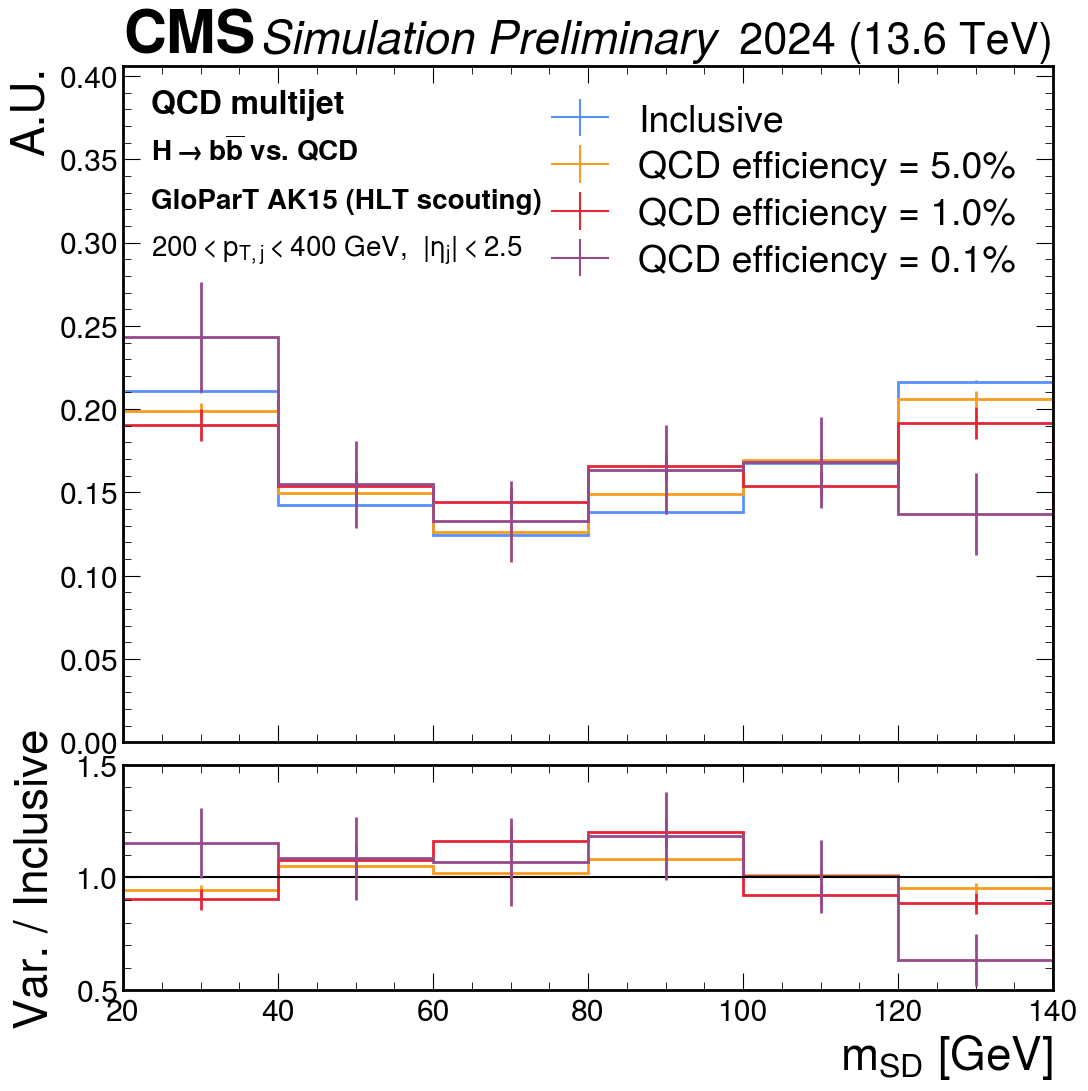

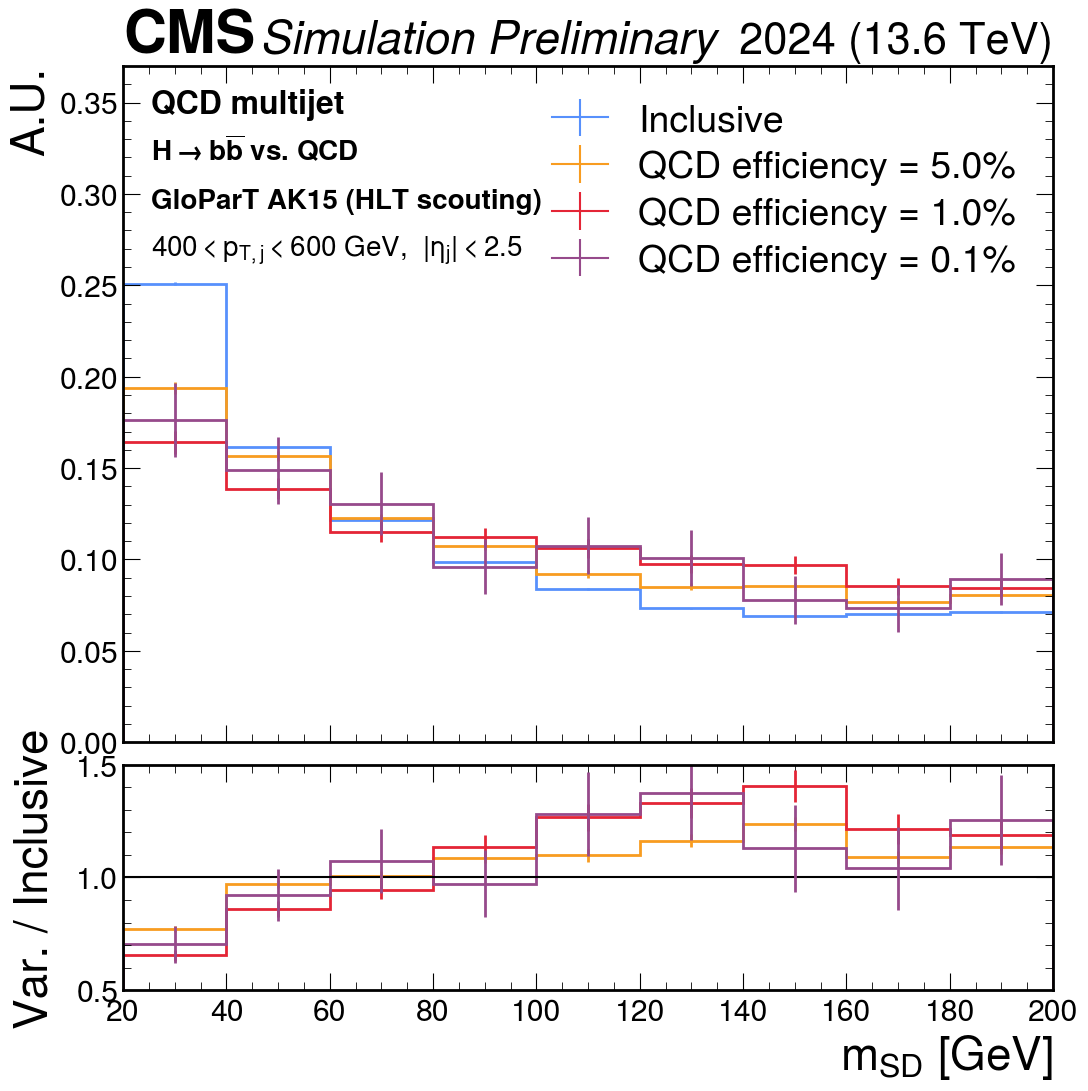

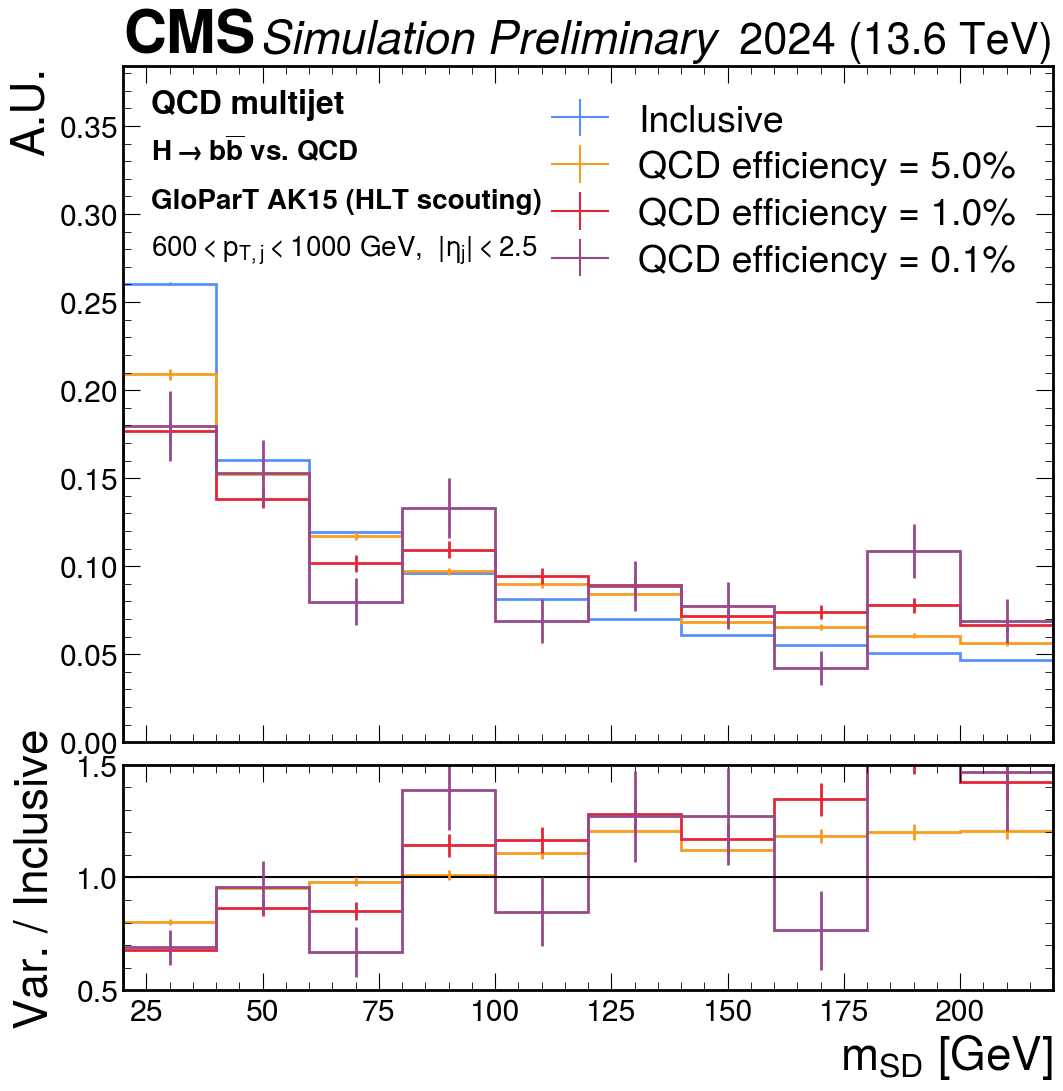

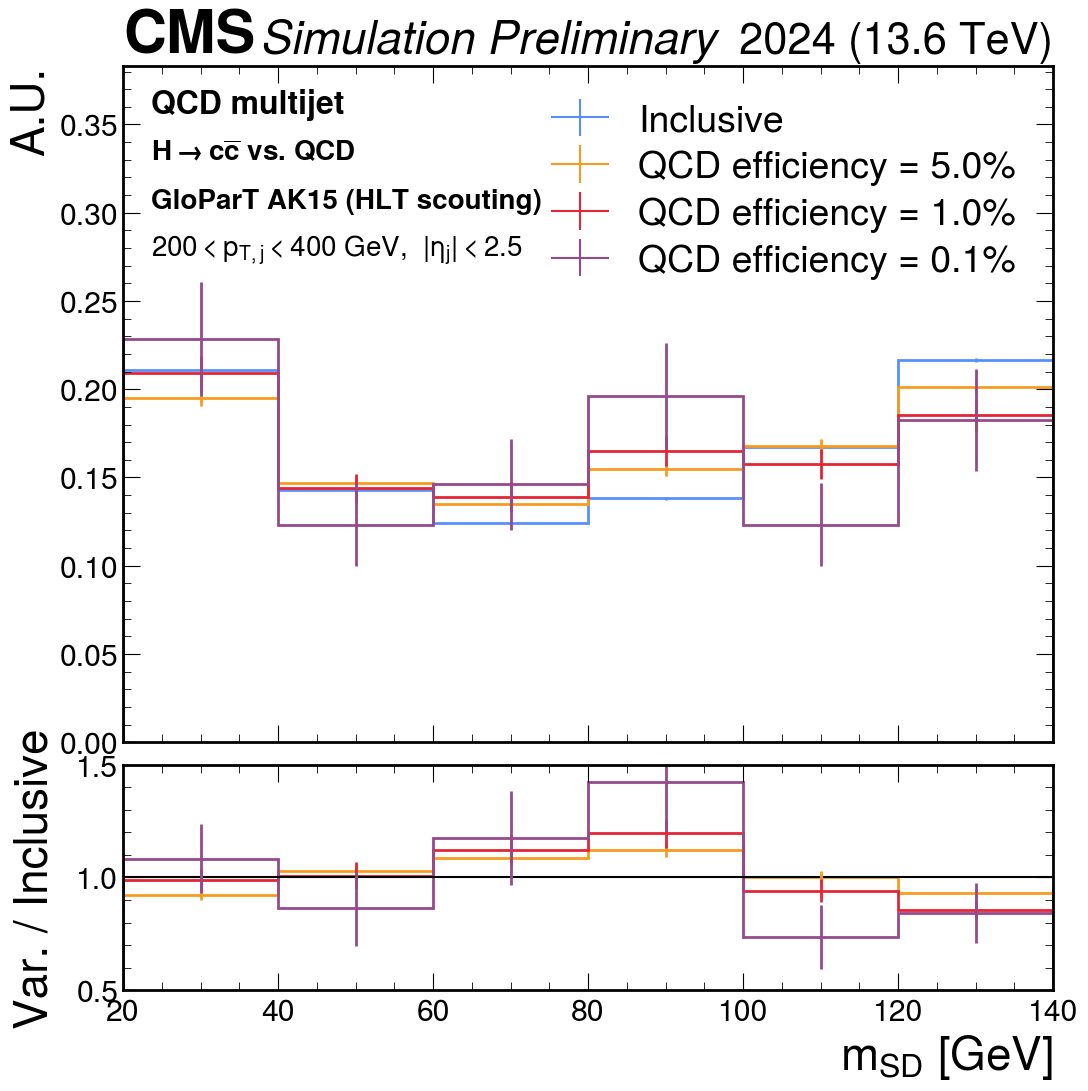

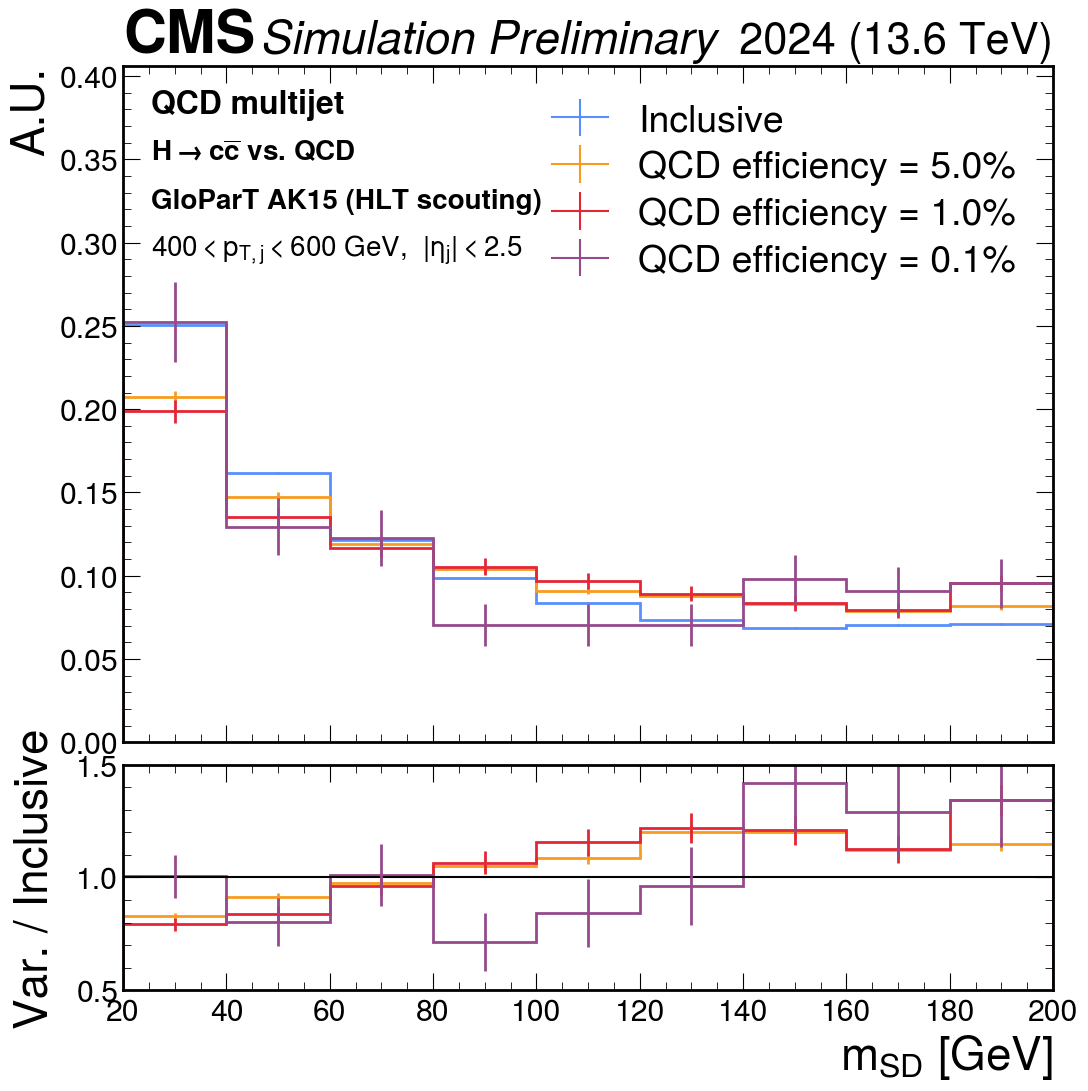

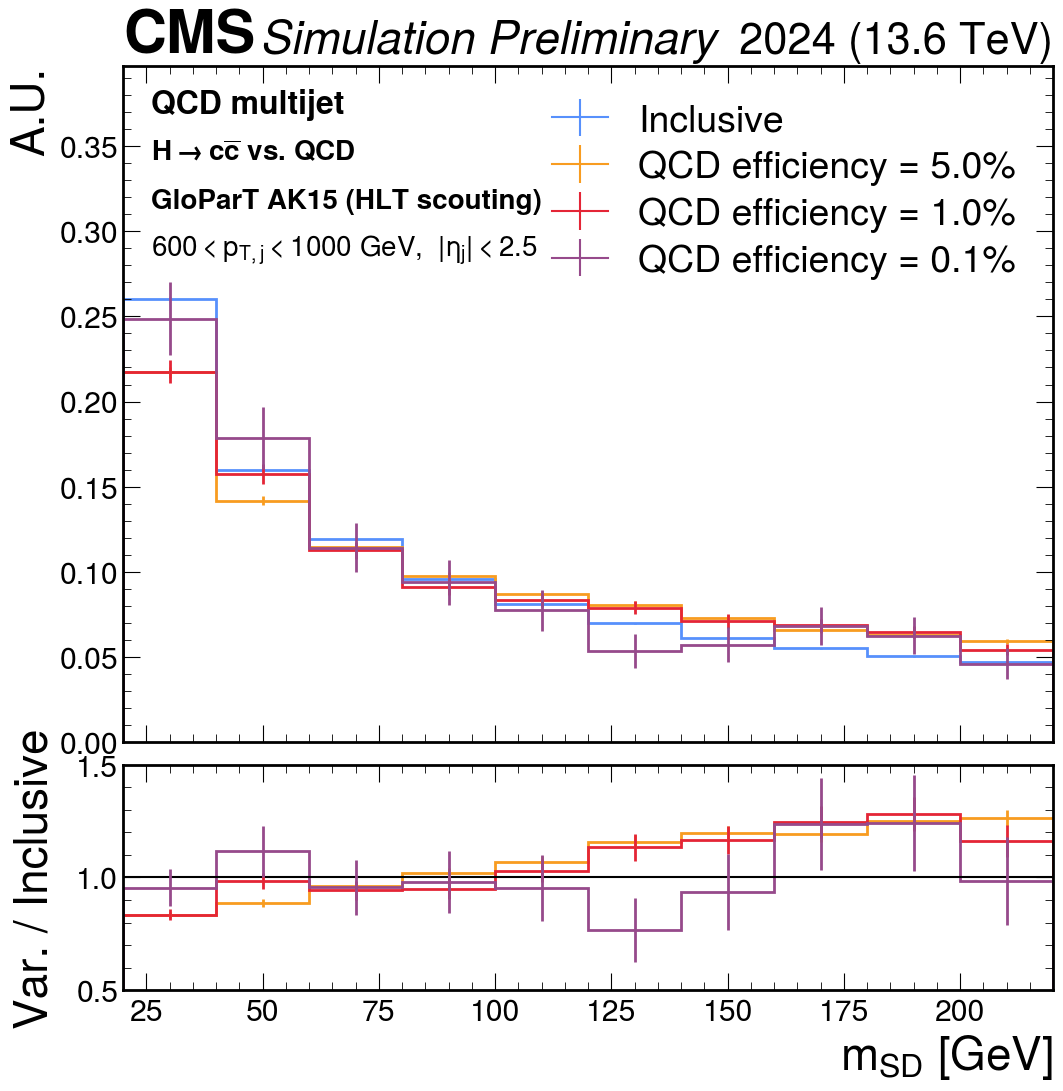

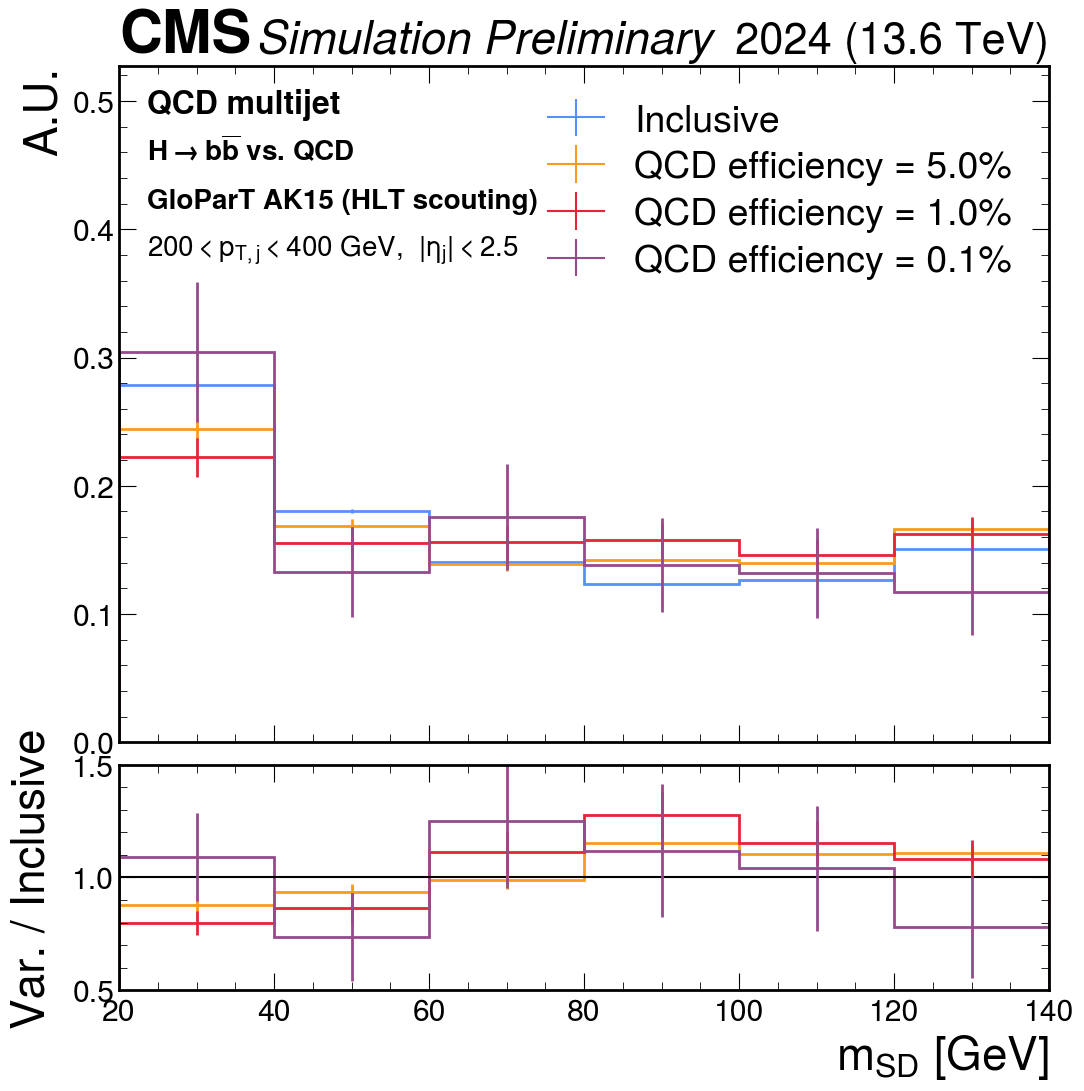

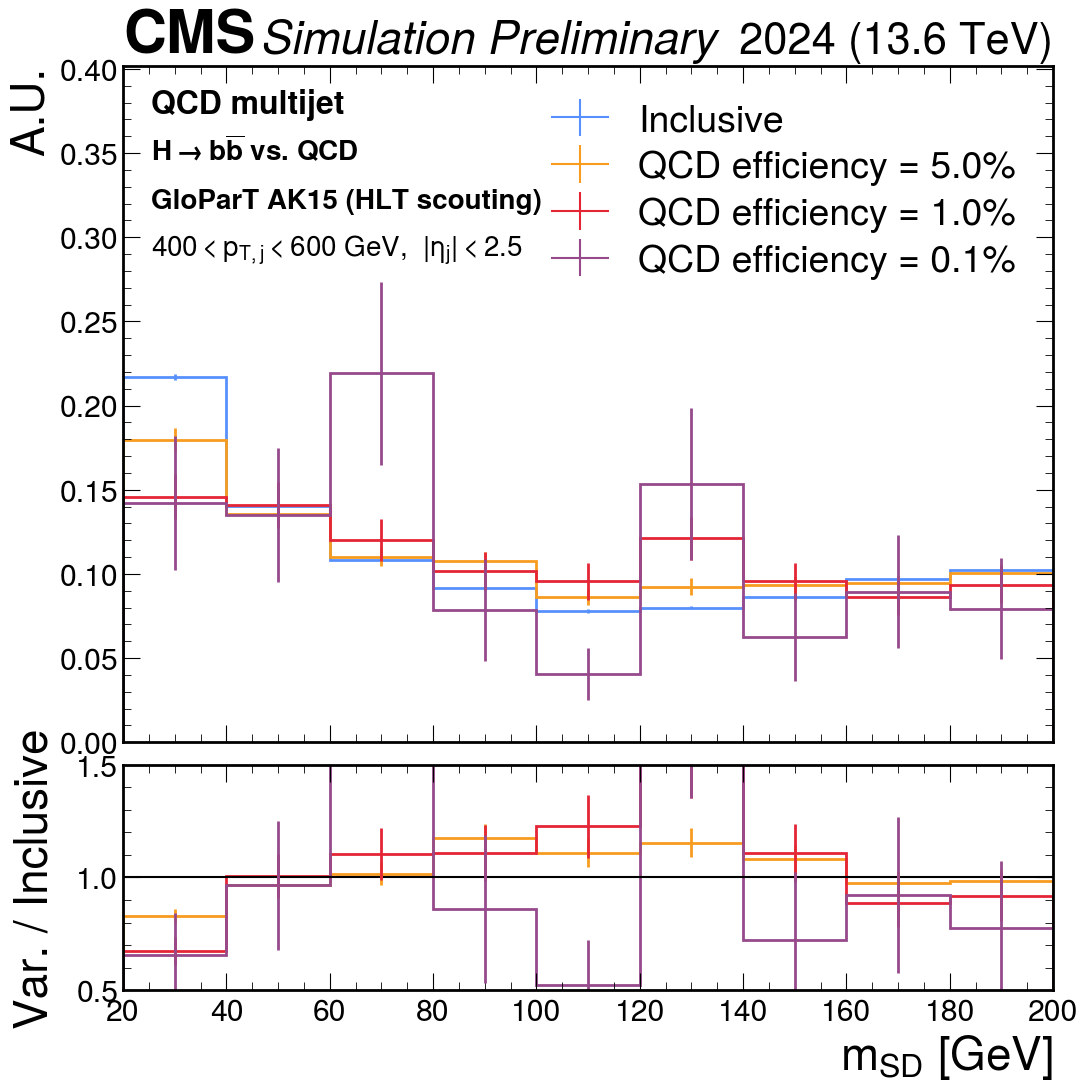

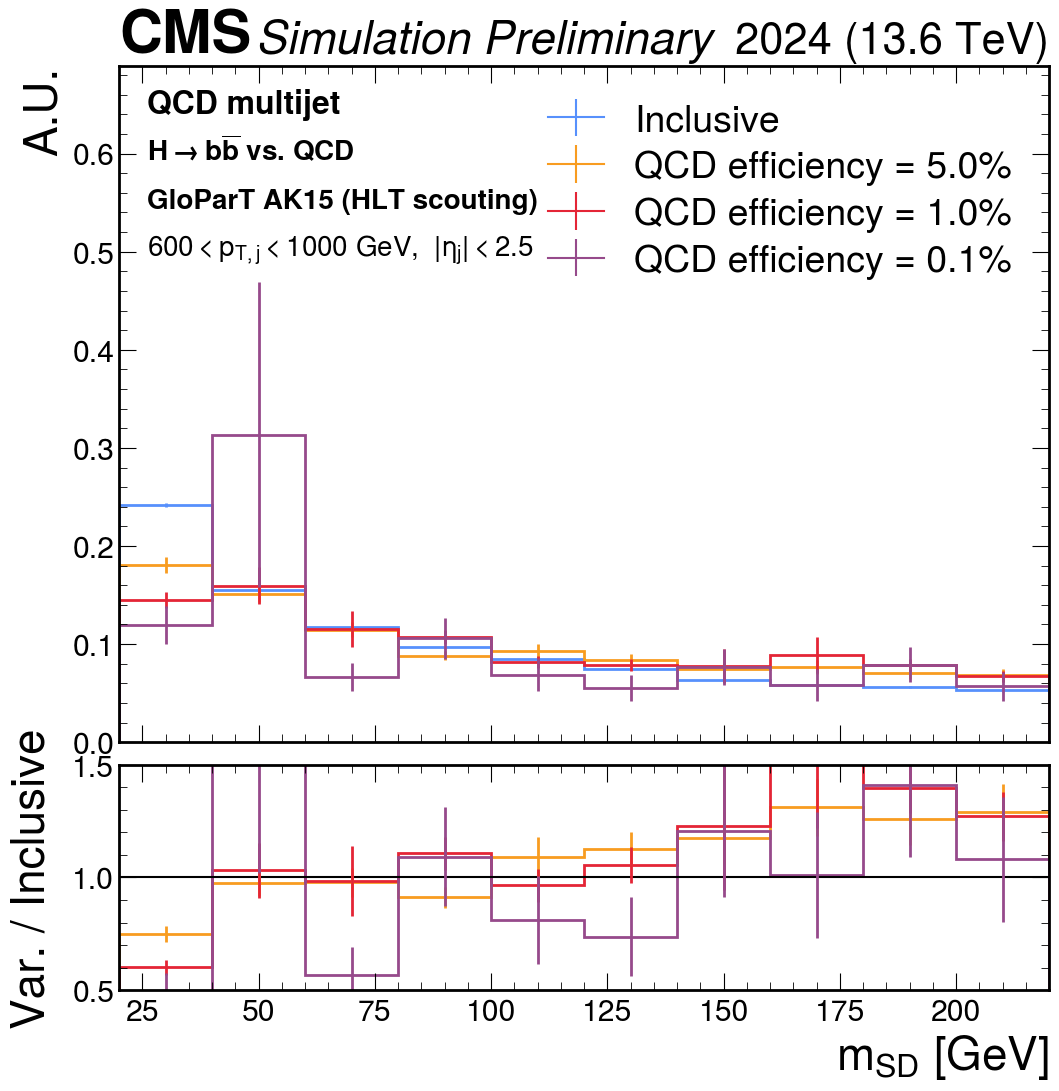

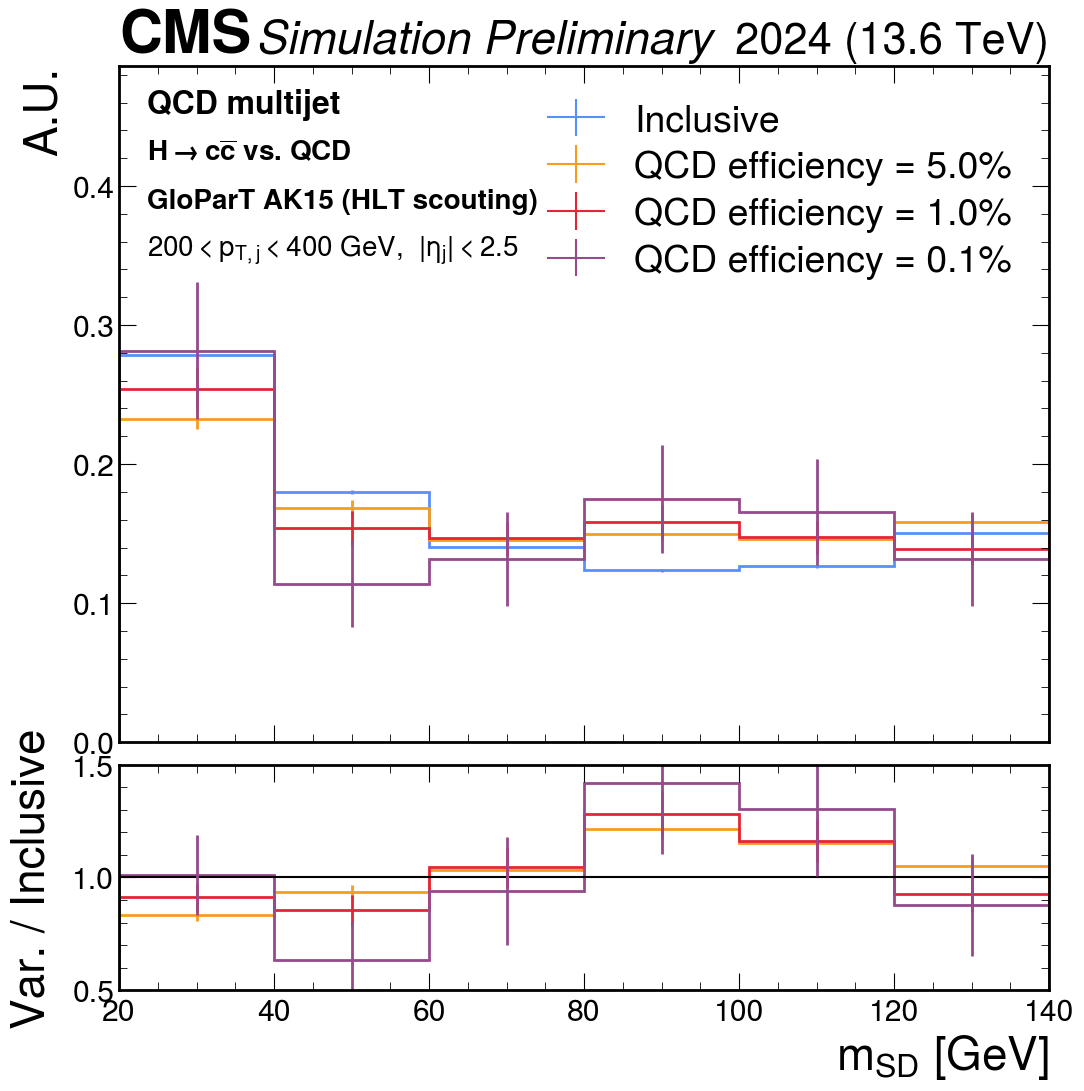

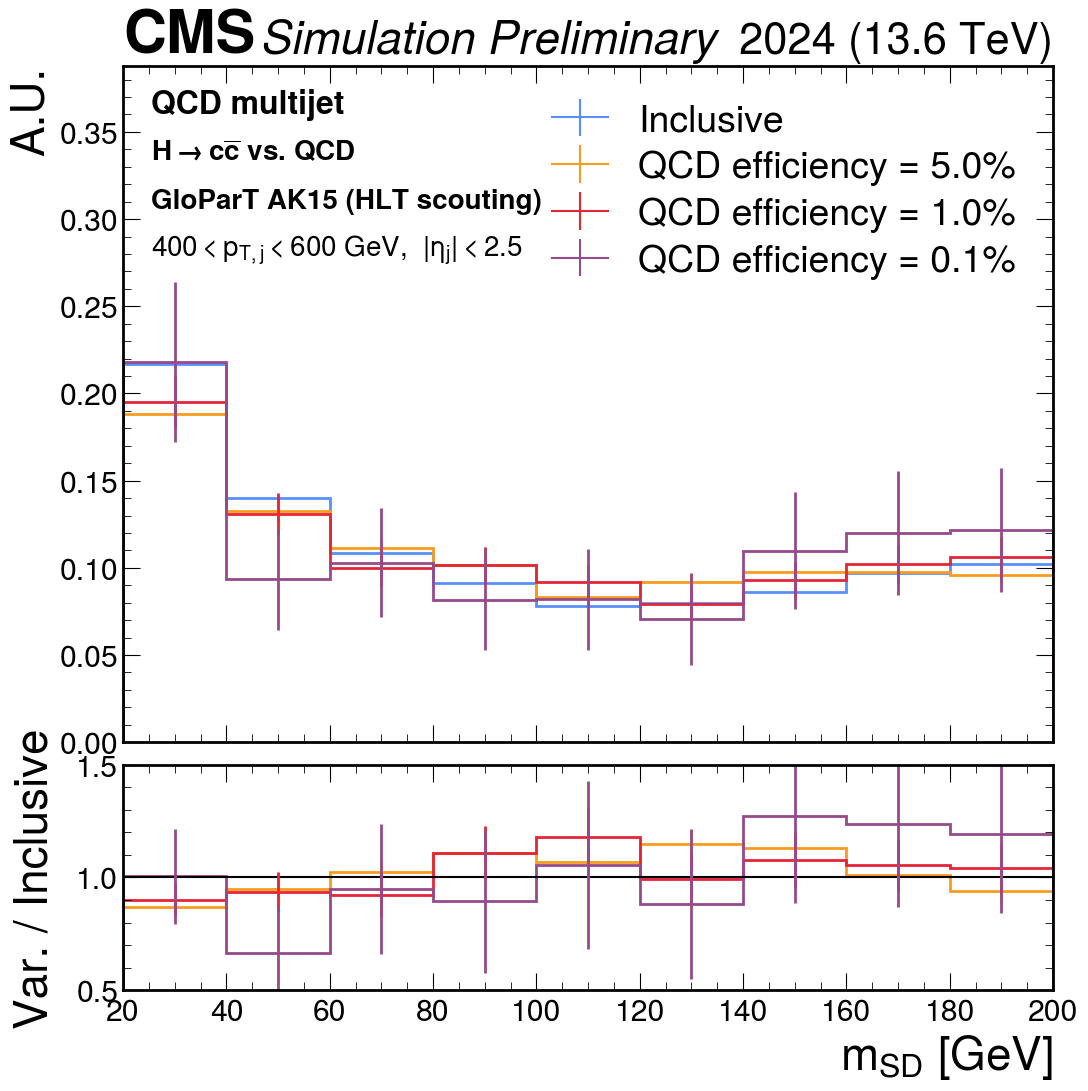

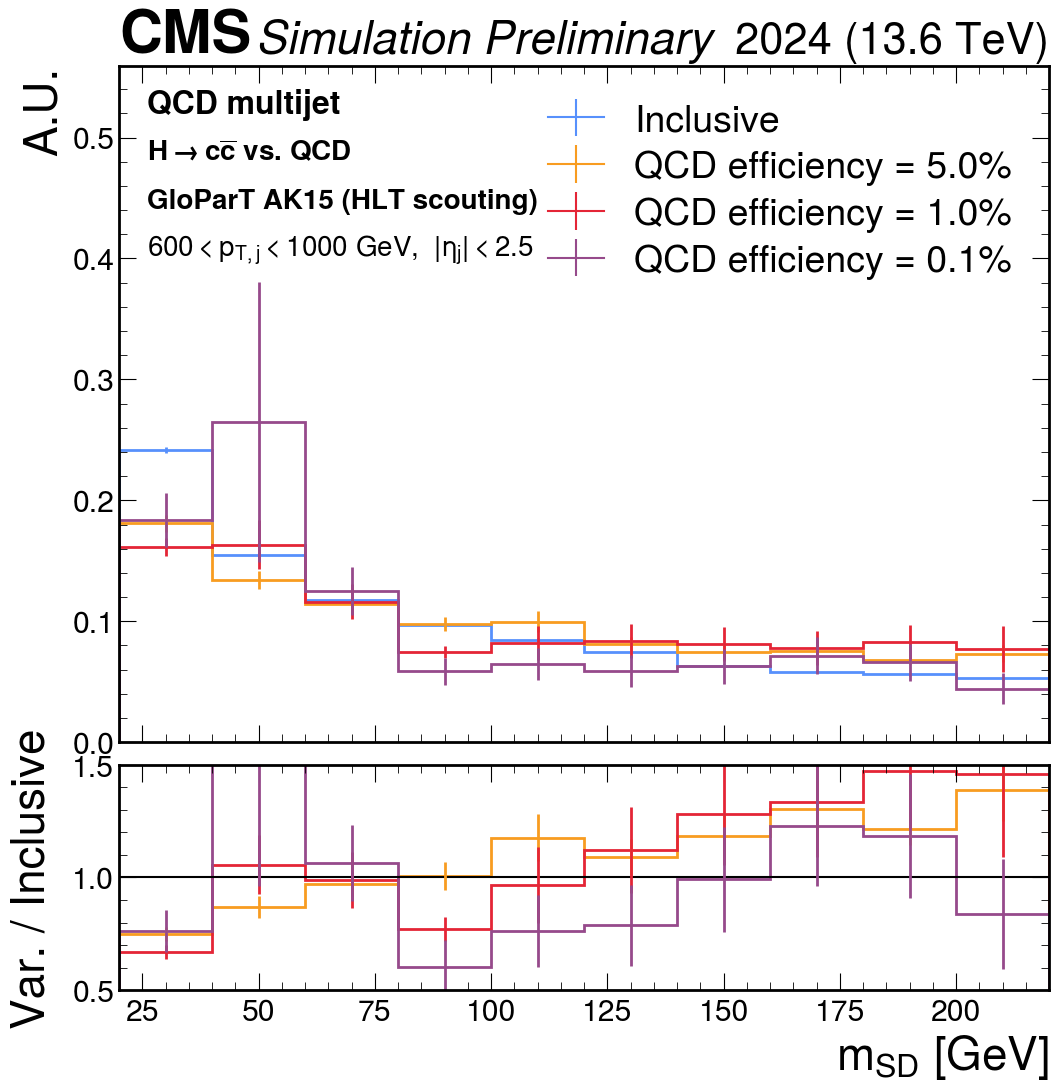

In [26]:
# plot_mass_decorr('qcd', 'HIGbb', 'QCD', store_plot=True, subdir='v3ScoutingLikeRECOAK15')
# plot_mass_decorr('qcd', 'HIGcc', 'QCD', store_plot=True, subdir='v3ScoutingLikeRECOAK15')
# plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', store_plot=True, subdir='v3ScoutingLikeRECOAK15')
# plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', store_plot=True, subdir='v3ScoutingLikeRECOAK15')
# plot_mass_decorr('qcd', 'HIGll', 'QCD', store_plot=True, subdir='massdecorr')

# plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', modelpath = "v3AK15Pretrain", store_plot=True, subdir='v3AK15Pretrain')
# plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', modelpath = "v3AK15Pretrain", store_plot=True, subdir='v3AK15Pretrain')

# plot_mass_decorr('qcd', 'HIGbb', 'QCD', modelpath = "v3AK15Pretrain", store_plot=True, subdir='v3AK15Pretrain')
# plot_mass_decorr('qcd', 'HIGcc', 'QCD', modelpath = "v3AK15Pretrain", store_plot=True, subdir='v3AK15Pretrain')

# plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', modelpath = "v3AK15Pretrain_v1", store_plot=True, subdir='v3AK15Pretrain_v1', do_pt=True)
# plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', modelpath = "v3AK15Pretrain_v1", store_plot=True, subdir='v3AK15Pretrain_v1', do_pt=True)

for year in ['2024']:

    plot_mass_decorr('qcd', 'HIGbb', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = year, ptmin=200, ptmax=400)
    plot_mass_decorr('qcd', 'HIGbb', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=400, ptmax=600)
    plot_mass_decorr('qcd', 'HIGbb', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=600, ptmax=1000)
    plot_mass_decorr('qcd', 'HIGcc', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=200, ptmax=400)
    plot_mass_decorr('qcd', 'HIGcc', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=400, ptmax=600)
    plot_mass_decorr('qcd', 'HIGcc', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=600, ptmax=1000)

    plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=200, ptmax=400)
    plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=400, ptmax=600)
    plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=600, ptmax=1000)
    plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=200, ptmax=400)
    plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=400, ptmax=600)
    plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3AK15Scouting', do_pt=False, year = "2024", ptmin=600, ptmax=1000)

# plot_mass_decorr('qcd', 'HIGbb', 'QCD', modelpath = "v3AK15Pretrain_tsg", store_plot=True, subdir='v3AK15Pretrain_tsg', do_pt=True)
# plot_mass_decorr('qcd', 'HIGcc', 'QCD', modelpath = "v3AK15Pretrain_tsg", store_plot=True, subdir='v3AK15Pretrain_tsg', do_pt=True)

# plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', modelpath = "v3AK15Pretrain_tsg", store_plot=True, subdir='v3AK15Pretrain_tsg', do_pt=False)
# plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', modelpath = "v3AK15Pretrain_tsg", store_plot=True, subdir='v3AK15Pretrain_tsg', do_pt=False)
# plot_mass_decorr('qcd', 'HIGbb', 'QCD', modelpath = "v3AK15Pretrain_tsg", store_plot=True, subdir='v3AK15Pretrain_tsg', do_pt=False)
# plot_mass_decorr('qcd', 'HIGcc', 'QCD', modelpath = "v3AK15Pretrain_tsg", store_plot=True, subdir='v3AK15Pretrain_tsg', do_pt=False)


# plot_mass_decorr('qcd', 'HIGtauhtauh', 'QCD', modelpath = "v3AK15", store_plot=True, subdir='v3AK15')
# plot_mass_decorr('qcd-xsecw', 'HIGcc', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3ScoutingAK15')
# plot_mass_decorr('qcd-xsecw', 'HIGbb', 'QCD', modelpath = "v3ScoutingAK15", store_plot=True, subdir='v3ScoutingAK15')

# plot_mass_decorr('qcd', 'HWWQQQQ', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HWWQQev', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HWWQQmv', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HWWQQQQ', 'QCDAndTTBARbWall', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HWWQQev', 'QCDAndTTBARbWall', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HWWQQmv', 'QCDAndTTBARbWall', store_plot=True, subdir='massdecorr')

# plot_mass_decorr('qcd', 'ZQQ', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'WQQ', 'QCD', store_plot=True, subdir='massdecorr')

# plot_mass_decorr('qcd', 'HIGtauhtaue', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HIGtauhtaum', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HIGtauhtauh', 'QCD', store_plot=True, subdir='massdecorr')

# plot_mass_decorr('qcd', 'TTBARbWQQ', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'TTBARbWhad', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'TTBARbWev', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'TTBARbWmv', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'TTBARbWtauhv', 'QCD', store_plot=True, subdir='massdecorr')

# not used
# plot_mass_decorr('qcd', 'HWWQQtauev', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HWWQQtaumv', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('qcd', 'HWWQQtauhv', 'QCD', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('ttbar', 'HWWQQQQ', 'TTBARbWhad', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('ttbar', 'HWWQQQ', 'TTBARbWhad', store_plot=True, subdir='massdecorr')
# plot_mass_decorr('ttbar', 'HWWQQev', 'TTBARbWev', mistags=[1, 0.05, 0.02, 0.01], store_plot=True, subdir='massdecorr')
# plot_mass_decorr('ttbar', 'HWWQQmv', 'TTBARbWmv', mistags=[1, 0.05, 0.02, 0.01], store_plot=True, subdir='massdecorr')
# plot_mass_decorr('ttbar', 'HWWQQta', 'TTBARbWta', mistags=[1, 0.05, 0.02, 0.01], store_plot=True, subdir='massdecorr')

# Mass regression

In [27]:
label_dict = {
    'QCD': 'QCD',
    'XQQbb': r'H$\rightarrow$b$\overline{b}$', 'XQQcc': r'H$\rightarrow$c$\overline{c}$', 'XQQss': r'H$\rightarrow$ss', 'XQQqq': r'H$\rightarrow$q$\overline{q}$ (u/d/s)', 'XQQtauhtaue': r'H$\rightarrow\tau_h\tau_e$', 'XQQtauhtaum': r'H$\rightarrow\tau_h\tau_\mu$', 'XQQtauhtauh': r'H$\rightarrow\tau_h\tau_h$', 
}

samples = { # (label, path)
    'sd': ('Soft-drop (HLT scouting)', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/'),
    # 'pnetofc': ('ParticleNet (official)', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual2.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun'),
    # 'v1': ('GloParT 1', '/home/olympus/licq/hww/incl-train/weaver-core/weaver/predict/ak8_MD_inclv10beta4_ul_manual.ddp4-bs640-lr1p2e-3.nepoch100.farm221'),
    # 'v2': ('GloParT 2', '/home/olympus/licq/hww/incl-train/weaver-core/weaver/predict/ak8_MD_inclv8_part_addltphp_wmeasonly_manual.useamp.large.gm5.ddp-bs256-lr2e-3/new'),
    # 'v3beta1': ('GloParT 3 (beta 1)', '/home/olympus/licq/hww/incl-train/weaver-core/weaver/predict/ak8_MD_inclv8std_rmhbs_manual.useamp.large_fc2048.pemb64_block10.gm5.ddp-bs512-lr7e-4.nepoch100'),
    # 'v3beta2': ('GloParT 3 (beta 2)', '/home/olympus/licq/hww/incl-train/weaver-core/weaver/predict/ak8_MD_inclv10init_manual.ddp4-bs512-lr1e-3.nepoch100.farm221'),
    # 'v3beta3a': ('GloParT 3 (beta 3a)', '/home/olympus/licq/hww/incl-train/weaver-core/weaver/predict/ak8_MD_inclv10beta3_origQCD_manual.ddp4-bs512-lr1e-3.nepoch100.ihep'),
    # 'v3beta4': ('GloParT 3 (beta 4)', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual2.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun'),
    # 'v3ScoutingLikeRECOAK15': ('GloParT 3 (v3) v1', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual2.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun'),
    # 'v3ScoutingLikeRECOAK15V2': ('GloParT 3 (v3) v2', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.runScoutPre2MoreDataLowPt'),
    # 'v3ScoutingLikeRECOAK15V2LastEpoch': ('GloParT 3 (v3)', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.runScoutPre2MoreDataLowPt_lastModel'),
    'v3ScoutingAK15': ('GloParT AK15 (HLT scouting)', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass_run4_lastEpoch/'),
    # 'pnetofc': ('PNet MD Run 2 (offline)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak15_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
    # 'pnet': ('PNet MD (offline)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak15_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
    # 'v3offline': ('GloParT AK15 (offline)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak15_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
    # 'v3offline2': ('GloParT AK15 2 (offline)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak15_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
    # 'v3ScoutingAK15': ('GloParT 3 (scout)', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_inclv10beta4_ul_scout_manual.std.ddp4-bs750-lr3p2e-6-mass'),
    # 'v3beta4.reg.guass': ('GloParT 3 (beta 4, guass NLL loss)', '/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual2.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun'),
}
gen_mode = 'vispart'

In [28]:

def plot_mass_decorr(discr_sigeff = 30, year='2024'):

    # discr_sigeff = 30
    # year = '2024'
    # gen_mode_v3 = 'split'
    gen_mode_v3 = ''
    # gen_mode_v3 = 'res'

    year_file_id = {
        '2017': '',
        '2023': 'run3_2023_',
        '2022': '22',
        '2022EE': 'EE22',
        '2023': '23',
        '2023BPix': 'BPix23',
        '2024': '',
        '2025': '',
        # '2023BPix': 'run3_2023bpix_',
        # '2017PUPPIv18': 'run2_repuppi_',
    }[year]


    path = "/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6"
    if year in ['2022', '2022EE', "2023", '2023BPix']:
        path = f"/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual_pre2024.std.ddp4-bs750-lr3p2e-prenew/"

    # for computing the discr value
    # dff = uproot.concatenate(glob.glob(f'/eos/home-s/sewuchte/weaverTrain/predict/ak15_MD_incl_v10beta4_ul_manual2.nlayer10.vispart_as_resid.ddp4-bs640-lr1p2e-3.nepoch100.testrun/pred_{year_file_id}higlo*.root'))
    dff = uproot.concatenate(glob.glob(f'{path}/pred_hig*{year_file_id}.root'), num_workers=8)
    dff = dff[dff.scoutfj_gen_mass == 125]
    dff = dff[ak.numexpr.evaluate('(scoutfj_pt>200) & (scoutfj_pt<2500)', dff)]
    pnet_discr = lambda s: f'(pfMassDecorrelatedParticleNetJetTags_probX{s}) / ((pfMassDecorrelatedParticleNetJetTags_probX{s}) + (pfMassDecorrelatedParticleNetJetTags_probQCDb + pfMassDecorrelatedParticleNetJetTags_probQCDbb + pfMassDecorrelatedParticleNetJetTags_probQCDc + pfMassDecorrelatedParticleNetJetTags_probQCDcc + pfMassDecorrelatedParticleNetJetTags_probQCDothers))'
    # pnet_discr = lambda s: f'(pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probH{s}) / ((pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probH{s}) + (pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probQCDb + pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probQCDbb + pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probQCDc + pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probQCDcc + pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_probQCDothers))"

    pnet_discr = lambda s: f'(score_label_H_{s}) / ((score_label_H_{s}) + (score_label_QCD_b + score_label_QCD_bb + score_label_QCD_c + score_label_QCD_cc + score_label_QCD_others))'

    truth_selection = {
        'H_bb': '(scoutfj_label == 17)',
        'H_cc': '(scoutfj_label == 18)',
        'H_qq': '(scoutfj_label == 19) | (scoutfj_label == 20)',
        'H_tauhtaue': '(scoutfj_label == 27)',
        'H_tauhtaum': '(scoutfj_label == 28)',
        'H_tauhtauh': '(scoutfj_label == 29)',
    }
    categories = {
        'H_bb': ['H_bb'],
        'H_cc': ['H_cc'],
        'H_qq': ['H_qq'],
        # 'H_bb': ['H_bb','H_cc','H_ss','H_qq'],
        # 'H_cc': ['H_bb','H_cc','H_ss','H_qq'],
        # 'H_qq': ['H_bb','H_cc','H_ss','H_qq'],
        'H_tauhtaue': ['H_tauhtaue'],
        'H_tauhtauh': ['H_tauhtauh'],
    }

    ## don't uncomment these lines!
    # for ch in categories:
    #     categories[ch] = [c.replace('H_WW', 'H_WxWxStar') for c in categories[ch]]
    # for ch in categories:
    #     categories[ch] += ['QCD_bb', 'QCD_cc', 'QCD_b', 'QCD_c', 'QCD_others']

    # nbin, xmin, xmax = 200, 0, 250
    nbin, xmin, xmax = 100, 0, 250
    # nbin, xmin, xmax = 200, 0, 60 # sigma
    # nbin, xmin, xmax = 200, 0, 500

    genm = 125

    # colorlist = ['blue', 'red', 'green', 'darkorange', 'darkviolet', 'cyan']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)

    # for ch in ['H_bb', 'H_cc', 'H_qq', 'H_tauhtauh']:
    for ch in ['H_bb', 'H_cc', 'H_qq']:
    # for ch in ['H_tauhtauh']:
    # for ch in ['H_bb']:
    # for ch in ['H_tauhtaue']:
        # first compute the discr value
        dff_truth = dff[ak.numexpr.evaluate(truth_selection[ch], dff)]
        val = ak.numexpr.evaluate(pnet_discr(ch[2:]), dff_truth) # H_bb, H_cc, H_qq
        discr_thres = np.quantile(val, 1-discr_sigeff/100)
        print(ch, f'{discr_sigeff=}, {discr_thres=}')

        # no SD cut!
        preselection = {
            'H_bb': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & ({pnet_discr('bb')} > {discr_thres})",
            # 'H_bb': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & ({pnet_discr('bb')} > {discr_thres}) & (output_target_res_mass_factor_sigma * scoutfj_mass > 20)",
            'H_cc': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & ({pnet_discr('cc')} > {discr_thres})",
            'H_qq': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & ({pnet_discr('qq')} > {discr_thres})",
            'H_tauhtaue': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & ({pnet_discr('tauhtaue')} > {discr_thres})",
            'H_tauhtauh': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & ({pnet_discr('tauhtauh')} > {discr_thres})",
        }
        # preselection = {
        #     'H_bb': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & (scoutfj_sdmass>20) & ({pnet_discr('bb')} > {discr_thres})",
        #     'H_cc': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & (scoutfj_sdmass>20) & ({pnet_discr('cc')} > {discr_thres})",
        #     'H_qq': f"(scoutfj_pt>200) & (scoutfj_pt<2500) & (scoutfj_sdmass>20) & ({pnet_discr('qq')} > {discr_thres})",
        # }

        f, ax = plt.subplots(figsize=(12,12), layout='constrained')
        # hep.cms.label(data=False, year=2017, ax=ax, fontname='sans-serif')
        com = '13.6' if any(y in year for y in ['2022', '2022EE', '2023', '2023BPix', '2024', '2025']) else '13'
        hep.cms.label(llabel = "Simulation Preliminary", rlabel=f'{year} ({com} TeV)', ax=ax, fontname='sans-serif', fontsize=33)

        for n, (lab, path_) in samples.items():
            print (f'Processing sample {ch}, method {n}...')
            df = uproot.concatenate(glob.glob(path + f'/pred_hig*{year_file_id}.root'), num_workers=16)

            print(f'{len(df)=}')
            df = df[df.scoutfj_gen_mass == genm]
            df = df[ak.numexpr.evaluate(preselection[ch], df)]

            _df = df[ak.numexpr.evaluate(truth_selection[ch], df)]
            print(f'{len(_df)=}')

            if n == 'sd':
                var = 'scoutfj_sdmass'
                print ('not mass-decorrelated, using sd mass')
            elif n == 'pnetofc':
                var = 'pfParticleNetMassRegressionJetTags_mass'
            elif n == 'pnet':
                var = 'pfParticleNetFromMiniAODAK8JetTags_masscorr * fj_mass'
            elif n == 'v3offline':
                var = 'pfGlobalParticleTransformerAK8JetTags_massCorrGeneric * fj_mass'
            elif n == 'v3offline2':
                var = 'pfGlobalParticleTransformerAK8JetTags_massCorrX2p * fj_mass'
            elif n == 'v1':
                var = 'pfMassDecorrelatedInclParticleTransformerV1JetTags_mass'
            elif n in ['partlite', 'partB', 'partL', 'v2']:
                # var = 'pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_resonanceMassCorr * scoutfj_mass' if gen_mode == 'res' else 'pfMassDecorrelatedInclParticleTransformerV2HidLayerJetTags_visiableMassCorr * scoutfj_mass'
                var = 'output_target_res_mass_factor * scoutfj_mass' if gen_mode == 'res' else 'output_target_parts_mass_factor * scoutfj_mass'
            elif n == 'v3beta1': # split-reg version
                var = "({nominator}) / ({denominator}) * scoutfj_mass".format(
                    nominator = ' + '.join([f'score_label_{l}*output_target_res_mass_factor_label_{l}' for l in categories[ch]]),
                    denominator = ' + '.join([f'score_label_{l}' for l in categories[ch]]),
                )
            elif n.startswith('v3beta2') or n.startswith('v3beta3'): # both split-reg and unified-reg
                if gen_mode_v3 == 'split':
                    var = "({nominator}) / ({denominator}) * scoutfj_mass".format(
                        nominator = ' + '.join([f'score_label_{l}*output_target_res_mass_factor_label_{l}' for l in categories[ch]]),
                        denominator = ' + '.join([f'score_label_{l}' for l in categories[ch]]),
                    )
                else:
                    var = 'output_target_res_mass_factor * scoutfj_mass' if gen_mode_v3 == 'res' else 'output_target_parts_mass_factor * scoutfj_mass'
            elif n.startswith('v3beta4') or n == 'v3' or n.startswith('v3ScoutingLikeRECOAK15') or n.startswith('v3ScoutingAK') or n == "v3AK15": # residue for split-reg
                if n == 'v3beta4.reg.guass':
                    var = 'output_target_res_mass_factor * scoutfj_mass'
                else:
                    if gen_mode_v3 == 'split':
                        var = "(({nominator}) / ({denominator}) + output_target_res_mass_factor) * scoutfj_mass".format( # this is residual setup for v3
                            nominator = ' + '.join([f'score_label_{l}*output_target_res_mass_factor_label_{l}' for l in categories[ch]]),
                            denominator = ' + '.join([f'score_label_{l}' for l in categories[ch]]),
                        )
                    else:
                        var = 'output_target_res_mass_factor * scoutfj_mass' if gen_mode_v3 == 'res' else 'output_target_parts_mass_factor * scoutfj_mass'

            array = ak.numexpr.evaluate(var, _df)
            print(n, var)
            # guassian fit
            # from scipy.stats import norm
            # mean, std = norm.fit(array)
            
            hist = bh.Histogram(bh.axis.Regular(nbin, xmin, xmax), storage=bh.storage.Weight())
            hist.fill(array)

            # create a subarray in the plotting range to compute mean and std
            # array_inrange = array[(array > xmin) & (array < xmax)]
            array_inrange = array[(array > 50) & (array < 200)]
            print(f'  mean: {np.mean(array_inrange):.2f}, std: {np.std(array_inrange):.2f}')

            # by hand, sum the overflow on the last bin
            if max(array) >= xmax:
                hist.view().value[-1] += sum(array >= xmax)
                hist.view().variance[-1] += sum(array >= xmax)

            # content, yerr = hist.view().value / sum(hist.view().value), np.sqrt(hist.view().variance) / sum(hist.view().value)
            content, yerr = hist.view().value, np.sqrt(hist.view().variance)
            # hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab + r'  $\bf{(\mu=%.1f,\,\sigma=%.1f)}$' % (np.mean(array), np.std(array)))
            hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab + r'  ${(\mu=%.1f,\,\sigma=%.1f,\,\epsilon_{%d\pm\! 20}=%.1f\%% )}$' % (np.mean(array_inrange), np.std(array_inrange), genm, sum((array_inrange > genm-20) & (array_inrange < genm+20)) / len(array_inrange) * 100 if len(array_inrange) > 0 else 0), color = color_map_mass[n], linestyle = "-" if "couting" in n or "sd" in n else "--", linewidth = 2)
            # hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab)
        ax.legend(labelspacing=0.4, prop={'size': 22})
        ax.set_xlabel(r'$m_{reco}$ [GeV]', ha='right', x=1.0, fontsize = 33)
        ax.set_ylabel('Jets / bin', ha='right', y=1.0, fontsize = 33)
        # ax.set_xlabel(r'$\sigma_{m_{reco}}$ [GeV]', ha='right', x=1.0); ax.set_ylabel('Jets / bin', ha='right', y=1.0);

        # add a vertical line dashed at 125=x
        ax.axvline(125, 0, 0.75, linestyle='dashed', color='gray', linewidth=2)

        ax.set_xlim(xmin, xmax); ax.set_ylim(0, ax.get_ylim()[1]*1.5)
        ytext = 0.47
        # ytext = 0.64 # for standalone
        ax.text(0.03, 0.21+ytext, label_dict[f'XQQ{ch[2:]}'], fontsize=23, fontweight='bold', transform=ax.transAxes)
        ax.text(0.03, 0.16+ytext, r'$\epsilon_{sig} = %d$%s selected' % (discr_sigeff, '%'), fontsize=20, transform=ax.transAxes)
        # ax.text(0.03, 0.11+ytext, r'by PNet-%svsQCD' % (ch[-2:]), fontsize=18, transform=ax.transAxes)
        ax.text(0.03, 0.11+ytext, r'by GloParTAK15-%svsQCD' % (ch[-2:]), fontsize=20, transform=ax.transAxes)
        # ax.text(0.03, 0.04+ytext, r'$p_T > 200$ GeV, $m_{SD}$ > 0', fontsize=18, transform=ax.transAxes)
        ax.text(0.03, 0.06+ytext, r'$p_T > 200$ GeV', fontsize=20, transform=ax.transAxes)
        # ax.text(0.03, 0.04+ytext, r'$p_T > 200$ GeV, $m_{SD}$ > 0, $\sigma_{m_{reco}} > 20$ GeV', fontsize=18, transform=ax.transAxes)
        # plt.tight_layout()
        os.makedirs(f'plots_scout_ak15/v3ScoutingAK15/{year}', exist_ok=True)
        plt.savefig(f'plots_scout_ak15/v3ScoutingAK15/{year}/regmass_hqq_{ch}_sigeff{discr_sigeff}_wepsilon.pdf', bbox_inches='tight')
        plt.savefig(f'plots_scout_ak15/v3ScoutingAK15/{year}/regmass_hqq_{ch}_sigeff{discr_sigeff}_wepsilon.png', bbox_inches='tight')

H_bb discr_sigeff=30, discr_thres=0.9817354679107666
Processing sample H_bb, method sd...
len(df)=896372
len(_df)=26347
not mass-decorrelated, using sd mass
sd scoutfj_sdmass
  mean: 109.56, std: 14.75
Processing sample H_bb, method v3ScoutingAK15...
len(df)=896372
len(_df)=26347
v3ScoutingAK15 output_target_parts_mass_factor * scoutfj_mass
  mean: 129.78, std: 13.28
H_cc discr_sigeff=30, discr_thres=0.9302038073539733
Processing sample H_cc, method sd...
len(df)=896372
len(_df)=26155
not mass-decorrelated, using sd mass
sd scoutfj_sdmass
  mean: 115.23, std: 13.47
Processing sample H_cc, method v3ScoutingAK15...
len(df)=896372
len(_df)=26155
v3ScoutingAK15 output_target_parts_mass_factor * scoutfj_mass
  mean: 132.62, std: 12.25
H_qq discr_sigeff=30, discr_thres=0.8335919141769409
Processing sample H_qq, method sd...
len(df)=896372
len(_df)=52492
not mass-decorrelated, using sd mass
sd scoutfj_sdmass
  mean: 118.98, std: 10.92
Processing sample H_qq, method v3ScoutingAK15...
len(df)=8

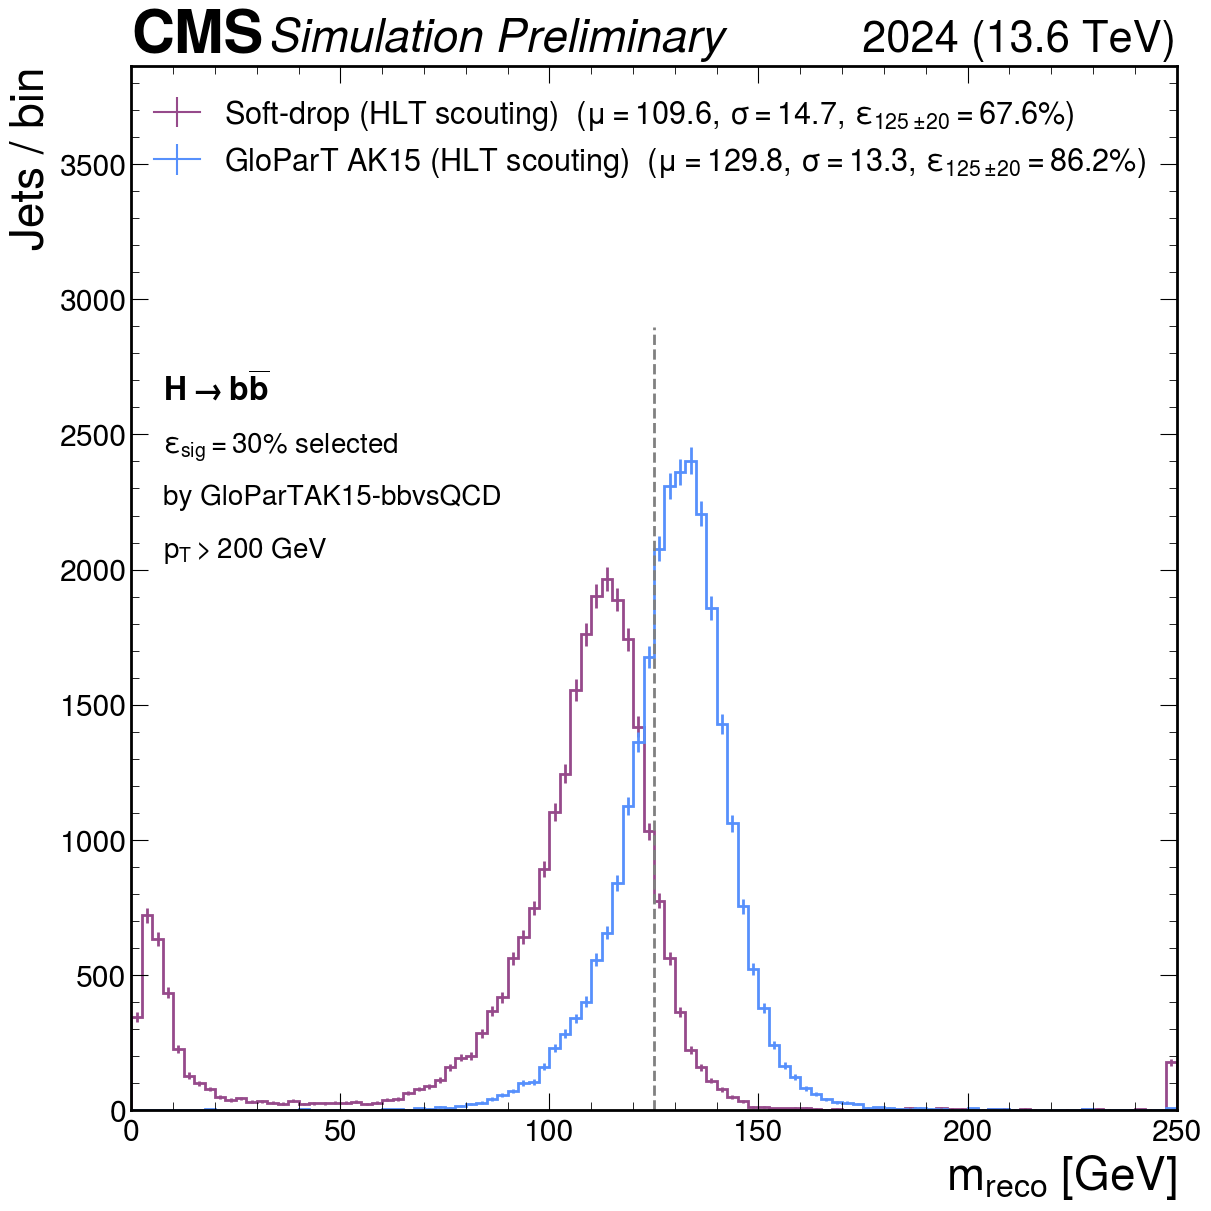

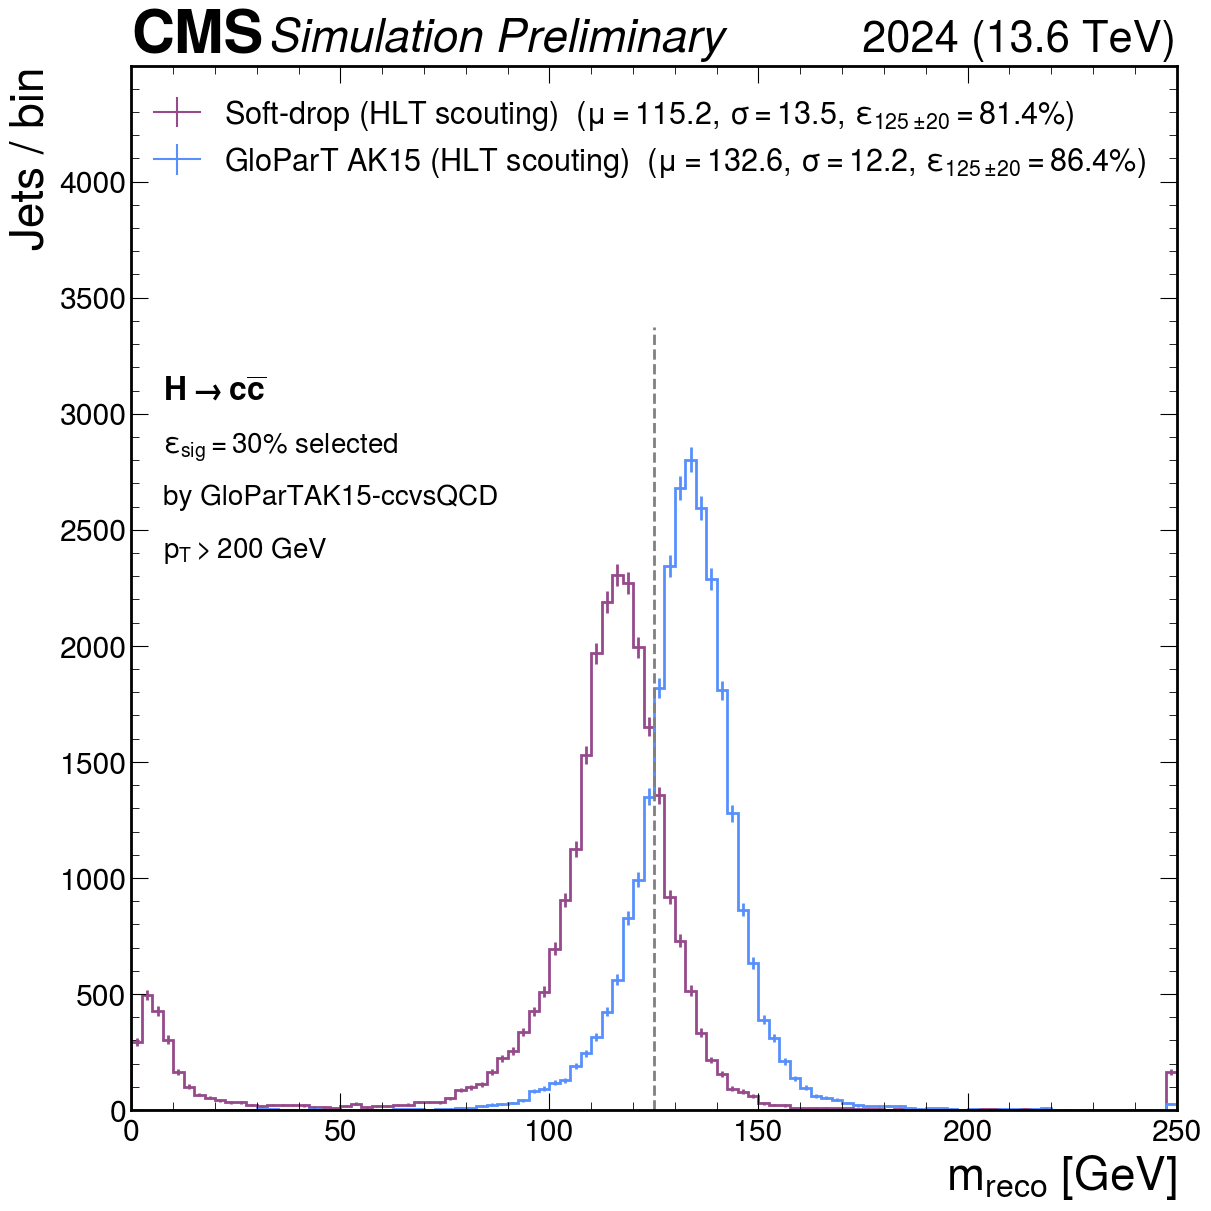

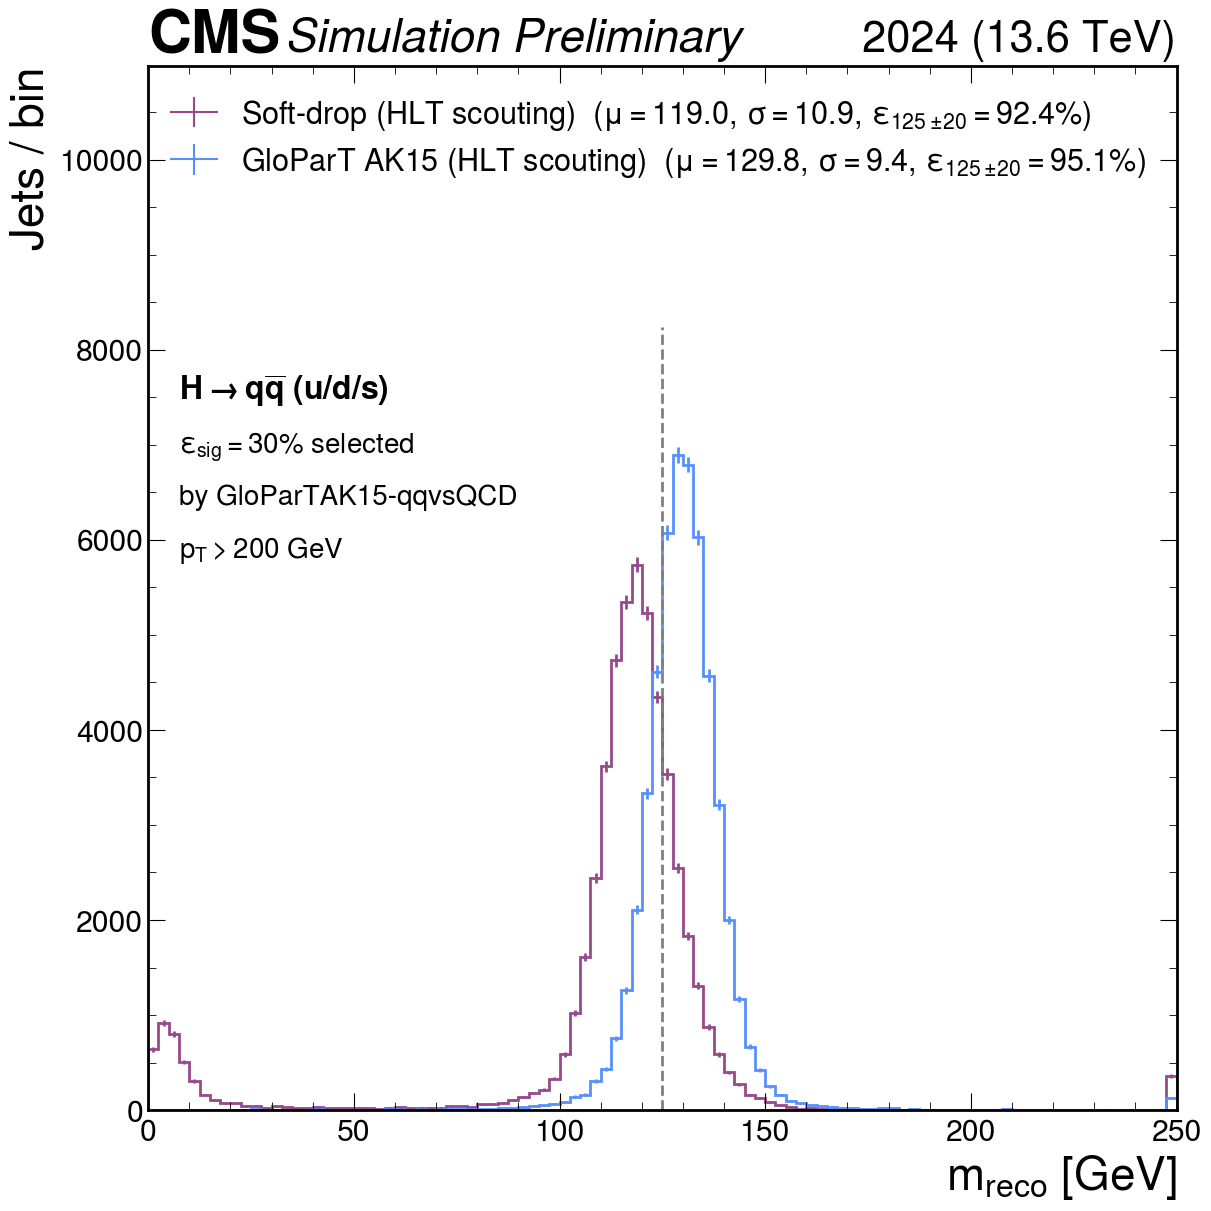

In [29]:
for year in ['2024']:
    # for discr_sigeff in [20, 30, 50]:
    for discr_sigeff in [30]:
        plot_mass_decorr(discr_sigeff = discr_sigeff, year=year)

5996053
5996053
Processing channel: QCD
5996053
(scoutfj_label >= 309) & (scoutfj_label <= 313)
[{target_res_mass_factor: 0.0503, output_target_res_mass_factor: ..., ...}, ...]
[0.0121, 0.0331, 0.871, 0.272, 0.0212, ..., 0.0276, 0.00692, 0.0148, 0.32]
QCD discr_sigeff=30, discr_thres=0.037390392273664474
len(df)=5996053
len(_df)=5996053
not mass-decorrelated, using sd mass
scoutfj_sdmass
42.562551064842154 55.89836133086614
sd scoutfj_sdmass
len(df)=5996053
len(_df)=5996053
output_target_parts_mass_factor * scoutfj_mass
53.591563650287945 56.298013381849515
v3ScoutingAK8 output_target_parts_mass_factor * scoutfj_mass
len(df)=5996053
len(_df)=5996053
pfParticleNetFromMiniAODAK8JetTags_masscorr * fj_mass
68.57822771079576 41.50560674094436
pnet pfParticleNetFromMiniAODAK8JetTags_masscorr * fj_mass
len(df)=5996053
len(_df)=5996053
pfGlobalParticleTransformerAK8JetTags_massCorrGeneric * fj_mass
49.26126970525444 53.39284890371217
v3offline pfGlobalParticleTransformerAK8JetTags_massCorrGene

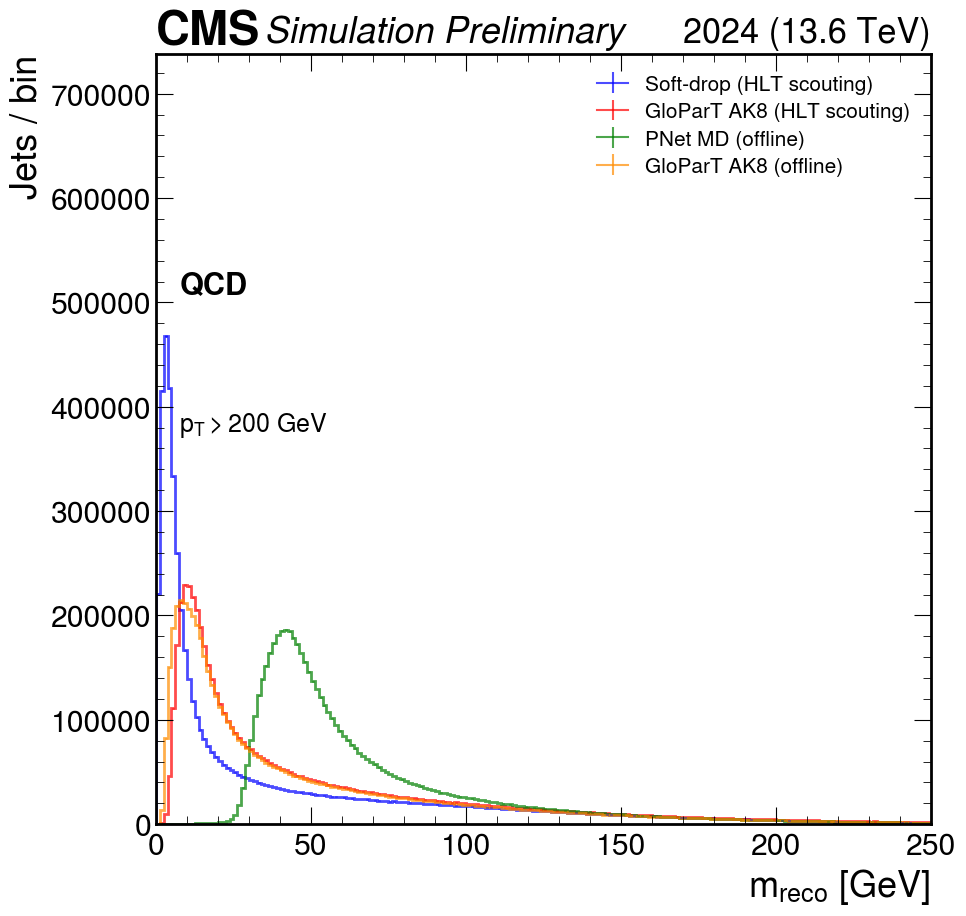

In [35]:
label_dict = {
    'XQQD': 'QCD',
    'XQQbb': r'H$\rightarrow$bb', 'XQQcc': r'H$\rightarrow$cc', 'XQQss': r'H$\rightarrow$ss', 'XQQqq': r'H$\rightarrow$qq (u/d/s)', 'XQQtauhtaue': r'H$\rightarrow\tau_h\tau_e$', 'XQQtauhtaum': r'H$\rightarrow\tau_h\tau_\mu$', 'XQQtauhtauh': r'H$\rightarrow\tau_h\tau_h$', 
}
samples = { # (label, path)
    'sd': ('Soft-drop (HLT scouting)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
    'v3ScoutingAK15': ('GloParT AK8 (HLT scouting)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
    'pnet': ('PNet MD (offline)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
    'v3offline': ('GloParT AK8 (offline)', '/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6'),
}

discr_sigeff = 30
# discr_sigeff = 100
year = '2024'
# gen_mode_v3 = 'split'
# gen_mode_v3 = 'res'
gen_mode_v3 = ''

year_file_id = {
    '2017': '',
    '2023': 'run3_2023_',
    '2024': '',
    '2025': '',
    '2023BPix': 'run3_2023bpix_',
    '2017PUPPIv18': 'run2_repuppi_',
}[year]

listOfBranchesNeeded = ['fj_label', 'score_label_H_cc', 'score_label_H_bb', 'score_label_QCD_b', 'score_label_QCD_bb', 'score_label_QCD_c', 'score_label_QCD_cc', 'score_label_QCD_others', 'fj_pt', 'fj_mass', 'fj_sdmass', 'fj_gen_mass', 'output_target_res_mass_factor', 'output_target_parts_mass_factor', 'output_target_res_mass_factor_label_H_bb', 'output_target_res_mass_factor_label_H_cc', 'output_target_res_mass_factor_label_H_qq', 'output_target_res_mass_factor_label_H_tauhtaue', 'output_target_res_mass_factor_label_H_tauhtauh', 'pfParticleNetMassRegressionJetTags_mass', 'scoutfj_gen_mass', 'scoutfj_label', 'scoutfj_pt', 'scoutfj_sdmass', 'scoutfj_mass']

# for computing the discr value
dff = uproot.concatenate(glob.glob(f'/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6/pred_{year_file_id}qcd*.root'), cut = '((scoutfj_pt>200) & (scoutfj_pt<2500))', num_workers=16)
# dff = uproot.concatenate(glob.glob(f'/eos/user/c/coli/cms-repo/glopart-plotter/scouting_predict_from_yyzhao/ak8_MD_inclv10_scouting_2p_manual.std.ddp4-bs750-lr3p2e-6/pred_{year_file_id}qcd*.root'), cut = '((scoutfj_pt>200) & (scoutfj_pt<2500))', expressions=listOfBranchesNeeded, num_workers=16)
# dff = dff[dff.scoutfj_gen_mass == 125]
print (len(dff))
dff = dff[ak.numexpr.evaluate('(scoutfj_pt>200) & (scoutfj_pt<2500)', dff)]
print (len(dff))
pnet_discr = lambda s: f'(score_label_H_cc) / ((score_label_H_cc) + (score_label_QCD_b + score_label_QCD_bb + score_label_QCD_c + score_label_QCD_cc + score_label_QCD_others))'

truth_selection = {
    'H_bb': '(scoutfj_label == 17)',
    'H_cc': '(scoutfj_label == 18)',
    'H_qq': '(scoutfj_label == 19) | (scoutfj_label == 20)',
    'H_tauhtaue': '(scoutfj_label == 27)',
    'H_tauhtaum': '(scoutfj_label == 28)',
    'H_tauhtauh': '(scoutfj_label == 29)',
    'QCD': '(scoutfj_label >= 309) & (scoutfj_label <= 313)',
}
categories = {
    'H_bb': ['H_bb'],
    'H_cc': ['H_cc'],
    'H_qq': ['H_qq'],
    'H_tauhtaue': ['H_tauhtaue'],
    'QCD': ['QCD'],
}


nbin, xmin, xmax = 200, 0, 250

# genm = 125

colorlist = ['blue', 'red', 'green', 'darkorange', 'darkviolet', 'cyan']
mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)

for ch in ['QCD']:
    print (f'Processing channel: {ch}')
    print (len(dff))
    print (truth_selection[ch])
    dff_truth = dff[ak.numexpr.evaluate(truth_selection[ch], dff)]
    print(dff_truth)
    val = ak.numexpr.evaluate(pnet_discr(ch[2:]), dff_truth) # H_bb, H_cc, H_qq
    print(val)
    discr_thres = np.quantile(val, 1-discr_sigeff/100)
    print(ch, f'{discr_sigeff=}, {discr_thres=}')

    # no SD cut!
    preselection = {
        'H_bb': f"(scoutfj_pt>200) & (scoutfj_pt<2500)",
        'H_cc': f"(scoutfj_pt>200) & (scoutfj_pt<2500)",
        'H_qq': f"(scoutfj_pt>200) & (scoutfj_pt<2500)",
        'H_tauhtaue': f"(scoutfj_pt>200) & (scoutfj_pt<2500)",
        'QCD': f"(scoutfj_pt>200) & (scoutfj_pt<2500)",
    }

    f, ax = plt.subplots(figsize=(10,10))
    # hep.cms.label(data=False, year=2017, ax=ax, fontname='sans-serif')
    com = '13.6' if any(y in year for y in ['2022', '2022EE', '2023', '2023BPix', '2024', '2025']) else '13'
    hep.cms.label(llabel = "Simulation Preliminary", rlabel=f'{year} ({com} TeV)', ax=ax, fontname='sans-serif')

    for n, (lab, path) in samples.items():
        # df = uproot.concatenate(glob.glob(path + f'/pred_{year_file_id}qcd*.root'), cut = preselection[ch], expressions=listOfBranchesNeeded, num_workers=8)
        df = uproot.concatenate(glob.glob(path + f'/pred_{year_file_id}qcd*.root'), cut = preselection[ch], num_workers=16)

        print(f'{len(df)=}')
        # df = df[df.fj_gen_mass == genm]
        df = df[ak.numexpr.evaluate(preselection[ch], df)]

        _df = df[ak.numexpr.evaluate(truth_selection[ch], df)]
        print(f'{len(_df)=}')

        if n == 'sd':
            var = 'scoutfj_sdmass'
            print ('not mass-decorrelated, using sd mass')
        elif n == 'pnetofc':
            var = 'pfParticleNetMassRegressionJetTags_mass'
        elif n == 'pnet':
            var = 'pfParticleNetFromMiniAODAK8JetTags_masscorr * fj_mass'
        elif n == 'v3offline':
            var = 'pfGlobalParticleTransformerAK8JetTags_massCorrGeneric * fj_mass'
        elif n == 'v3offline2':
            var = 'pfGlobalParticleTransformerAK8JetTags_massCorrX2p * fj_mass'
        elif n == 'v1':
            var = 'pfMassDecorrelatedInclParticleTransformerV1JetTags_mass'
        elif n in ['partlite', 'partB', 'partL', 'v2']:
            var = 'output_target_res_mass_factor * scoutfj_mass' if gen_mode == 'res' else 'output_target_parts_mass_factor * scoutfj_mass'
        elif n == 'v3beta1': # split-reg version
            var = "({nominator}) / ({denominator}) * scoutfj_mass".format(
                nominator = ' + '.join([f'score_label_{l}*output_target_res_mass_factor_label_{l}' for l in categories[ch]]),
                denominator = ' + '.join([f'score_label_{l}' for l in categories[ch]]),
            )
        elif n.startswith('v3beta2') or n.startswith('v3beta3'): # both split-reg and unified-reg
            if gen_mode_v3 == 'split':
                var = "({nominator}) / ({denominator}) * scoutfj_mass".format(
                    nominator = ' + '.join([f'score_label_{l}*output_target_res_mass_factor_label_{l}' for l in categories[ch]]),
                    denominator = ' + '.join([f'score_label_{l}' for l in categories[ch]]),
                )
            else:
                var = 'output_target_res_mass_factor * scoutfj_mass' if gen_mode_v3 == 'res' else 'output_target_parts_mass_factor * scoutfj_mass'
        elif n.startswith('v3beta4') or n == 'v3' or n.startswith('v3ScoutingLikeRECOAK15') or n.startswith('v3ScoutingAK'): # residue for split-reg
            if n == 'v3beta4.reg.guass':
                var = 'output_target_res_mass_factor * scoutfj_mass'
            else:
                if gen_mode_v3 == 'split':
                    var = "(({nominator}) / ({denominator}) + output_target_res_mass_factor) * scoutfj_mass".format( # this is residual setup for v3
                        nominator = ' + '.join([f'score_label_{l}*output_target_res_mass_factor_label_{l}' for l in categories[ch]]),
                        denominator = ' + '.join([f'score_label_{l}' for l in categories[ch]]),
                    )
                else:
                    var = 'output_target_res_mass_factor * scoutfj_mass' if gen_mode_v3 == 'res' else 'output_target_parts_mass_factor * scoutfj_mass'
                    # var = 'target_res_mass_factor * scoutfj_mass' if gen_mode_v3 == 'res' else 'target_parts_mass_factor * scoutfj_mass'

        print (var) 
        print (np.mean(ak.numexpr.evaluate(var, _df)), np.std(ak.numexpr.evaluate(var, _df)))

        array = ak.numexpr.evaluate(var, _df)
        print(n, var)

        hist = bh.Histogram(bh.axis.Regular(nbin, xmin, xmax), storage=bh.storage.Weight())
        hist.fill(array)

        content, yerr = hist.view().value, np.sqrt(hist.view().variance)
        # hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab + r'  $\bf{(\mu=%.1f,\,\sigma=%.1f,\,\epsilon_{%d\pm\! 10}=%.1f\%% )}$' % (np.mean(array), np.std(array), genm, sum((array > genm-10) & (array < genm+10)) / len(array) * 100))
        # hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab + r'  $\bf{(\mu=%.1f,\,\sigma=%.1f,\,\epsilon_{%d\pm\! 10}=%.1f\%% )}$' % (np.mean(array), np.std(array), 0, sum((array) & (array)) / len(array) * 100))
        hep.histplot(content, bins=hist.axes[0].edges, yerr=yerr, label=lab, alpha=0.7, linewidth=2)
    ax.legend(labelspacing=0.4, prop={'size': 15})
    ax.set_xlabel(r'$m_{reco}$ [GeV]', ha='right', x=1.0); ax.set_ylabel('Jets / bin', ha='right', y=1.0);

    ax.set_xlim(xmin, xmax); ax.set_ylim(0, ax.get_ylim()[1]*1.5)
    ytext = 0.47
    # ytext = 0.64 # for standalone
    ax.text(0.03, 0.22+ytext, label_dict[f'XQQ{ch[2:]}'], fontsize=22, fontweight='bold', transform=ax.transAxes)
    # ax.text(0.03, 0.16+ytext, r'$\epsilon_{sig} = %d$%s selected' % (discr_sigeff, '%'), fontsize=18, transform=ax.transAxes)
    # ax.text(0.03, 0.11+ytext, r'by PNet-%svsQCD' % (ch[-2:]), fontsize=18, transform=ax.transAxes)
    # ax.text(0.03, 0.11+ytext, r'by GloParTAK8-%svsQCD' % (ch[-2:]), fontsize=18, transform=ax.transAxes)
    # ax.text(0.03, 0.04+ytext, r'$p_T > 200$ GeV, $m_{SD}$ > 0', fontsize=18, transform=ax.transAxes)
    ax.text(0.03, 0.04+ytext, r'$p_T > 200$ GeV', fontsize=18, transform=ax.transAxes)
    os.makedirs(f'plots_scout_ak15/v3ScoutingAK15/{year}', exist_ok=True)
    plt.savefig(f'plots_scout_ak15/v3ScoutingAK15/{year}/regmass_hqq_{ch}_sigeff{discr_sigeff}_wepsilon.pdf', bbox_inches='tight')
    plt.savefig(f'plots_scout_ak15/v3ScoutingAK15/{year}/regmass_hqq_{ch}_sigeff{discr_sigeff}_wepsilon.png', bbox_inches='tight')